In [2]:
%gui qt
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import yaml
from pathlib import Path
import scanpy as sc
import anndata as ad 
import napari
import scimap as sm
import tifffile
import sys
sys.path.append(os.path.abspath(".."))
from utils import stack_images

In [5]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Set up directories
results_dir = Path(config['results_dir'])
metadata_dir = Path(config['metadata_dir'])
preprocessed_dir = Path(config['preprocessed_dir'])  

In [6]:
adata = sc.read_h5ad(results_dir / "adata.h5ad")

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning:

Transforming to str index.



In [4]:
adata = sc.read_h5ad(results_dir / "adata.h5ad")
adata_145 = adata[adata.obs["run"] == 145].copy()
valid_genes = ~np.isnan(adata_145.X).all(axis=0)
adata_145 = adata_145[:, valid_genes].copy()

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning:

Transforming to str index.



In [ ]:
run13 = 

Run145

In [218]:
adata = sc.read_h5ad(results_dir / "adata.h5ad")
adata_141 = adata[adata.obs["run"] == 141].copy()
valid_genes = ~np.isnan(adata_141.X).all(axis=0)
adata_141 = adata_141[:, valid_genes].copy()
adata_141.raw = adata_141.copy()
#export adata 145
adata_141.write_h5ad(results_dir / "adata_141.h5ad")

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning:

Transforming to str index.



In [224]:
adata_141.var_names

Index(['ACTIN', 'ARGINASE1', 'BCL2', 'BETAACTIN', 'BETACATENIN', 'CALPONIN',
       'CD107A', 'CD107B', 'CD11B', 'CD11C', 'CD123', 'CD134', 'CD138', 'CD14',
       'CD15', 'CD16', 'CD163', 'CD1C', 'CD209', 'CD20CYTOPLASMIC', 'CD223',
       'CD223 1', 'CD274', 'CD274 1', 'CD276', 'CD3', 'CD31', 'CD324', 'CD326',
       'CD38', 'CD39', 'CD4', 'CD44', 'CD45 1', 'CD45RA', 'CD45RB', 'CD45RO',
       'CD56', 'CD57', 'CD66', 'CD66B', 'CD68', 'CD79A', 'CD8A', 'CD90',
       'CLEAVEDPARP1', 'COLLAGENI', 'COLLAGENIV', 'CTLA4CD152', 'CYTOKERATIN',
       'CYTOKERATIN14', 'CYTOKERATIN19', 'CYTOKERATIN20', 'CYTOKERATIN5',
       'CYTOKERATIN56', 'CYTOKERATIN7', 'ERBB2', 'FOXP3', 'FSP1', 'GALECTIN9',
       'GALECTIN9 1', 'GLUT1', 'HLAABC', 'HLADR', 'KI67', 'MART1',
       'MASTCELLTRYPTASE', 'MRP14', 'NUT 1', 'NYESOCTAG1B', 'P16', 'P16 1',
       'P53', 'PCNA', 'PDGFRBETA', 'PODOPLANIN', 'PRAME', 'PSANCAM', 'S100',
       'S100A8', 'SYNAPTOPHYSIN', 'TIM3', 'TIM3 1', 'VIMENTIN', 'VISTA'],
      dty

In [219]:
#Create function to load the data
#selected markers...
tumor_markers_4_images = ["DAPI", "CD274", "CD276", "CD326", "ErbB2", "PRAME"]
tumor_markers = ["CD274", "CD274 1", "CD276", "CD326", "ERBB2", "PRAME"]

In [221]:
#Stack up images function for MACSIMA data
def stack_images(image_dir, channels_list, output_path):
    #find the images that include the channels of interest
    image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.tif') and not f.startswith('._') and not f.startswith('.')])
    final_images_files = []
    final_channel_names = []
    #if among the channels there is dapi we only take one dapi image
    if "DAPI" in channels_list:
        one_dapi_file = [f for f in image_files if "-DAPI.tif" in f][1]
        final_images_files.append(one_dapi_file)
        final_channel_names.append("DAPI")
    for ch in channels_list:
        if ch != "DAPI":
            selected_image_files = [f for f in image_files if ch in f]
            #if there is more than one image of that channel append the channel name twice
            if len(selected_image_files) > 1:
                final_channel_names.extend([ch]*len(selected_image_files))
                final_images_files.extend(selected_image_files)
            else:
                final_channel_names.append(ch)
                final_images_files.extend(selected_image_files)
    #stack the images
    img_stacks = []
    for image in final_images_files:
        img_path = os.path.join(image_dir, image)
        img = tifffile.imread(img_path)
        img_stacks.append(img)
    # Stack images 
    stacked_image = np.stack(img_stacks, axis=0)
    # Add metadata
    metadata = {'channels': final_channel_names, "axes": "CYX"}
    # Save the final stacked image
    tifffile.imwrite(output_path, stacked_image)
    return stacked_image, final_images_files, final_channel_names

In [222]:
img, img_names, channel_names = stack_images("/Volumes/T7/Run141/ROI3", channels_list=tumor_markers_4_images, output_path=results_dir / "images" / f"Run141_ROI3_tumor_stacked.tif")

ValueError: all input arrays must have the same shape

In [230]:
#Stack up images function for MACSIMA data
def stack_images(image_dir, channels_list, output_path):
    #find the images that include the channels of interest
    image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.tif') and not f.startswith('._') and not f.startswith('.')])
    final_images_files = []
    final_channel_names = []
    #if among the channels there is dapi we only take one dapi image
    if "DAPI" in channels_list:
        one_dapi_file = [f for f in image_files if "-DAPI.tif" in f][1]
        final_images_files.append(one_dapi_file)
        final_channel_names.append("DAPI")
    for ch in channels_list:
        if ch != "DAPI":
            selected_image_files = [f for f in image_files if ch in f]
            #if there is more than one image of that channel append the channel name twice
            if len(selected_image_files) > 1:
                final_channel_names.extend([ch]*len(selected_image_files))
                final_images_files.extend(selected_image_files)
            else:
                final_channel_names.append(ch)
                final_images_files.extend(selected_image_files)
    #stack the images
    img_stacks = []
    for image in final_images_files:
        img_path = os.path.join(image_dir, image)
        img = tifffile.imread(img_path)
        img_stacks.append(img)

    return img_stacks, final_images_files, final_channel_names

In [226]:
a, b, c = stack_images("/Volumes/T7/Run141/ROI3", channels_list=tumor_markers_4_images, output_path=results_dir / "images" / f"Run141_ROI3_tumor_stacked.tif")

In [133]:
for i in range(img.shape[0]):
    print(img[i].shape)

(15171, 15537)
(15171, 15537)
(15171, 15537)
(15171, 15537)
(15171, 15537)
(15171, 15537)
(15171, 15537)


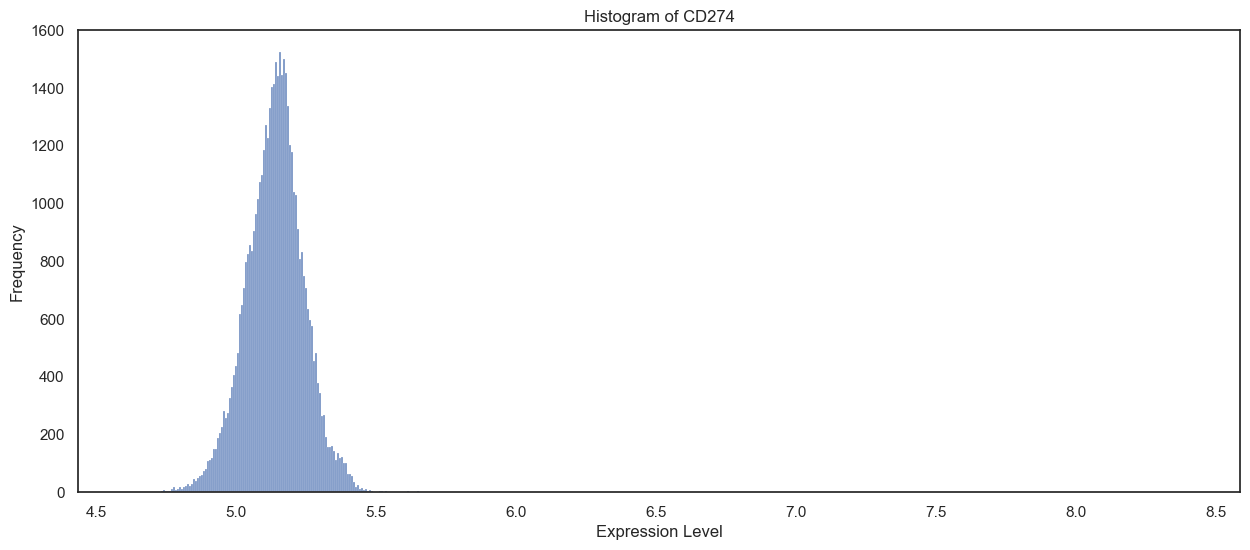

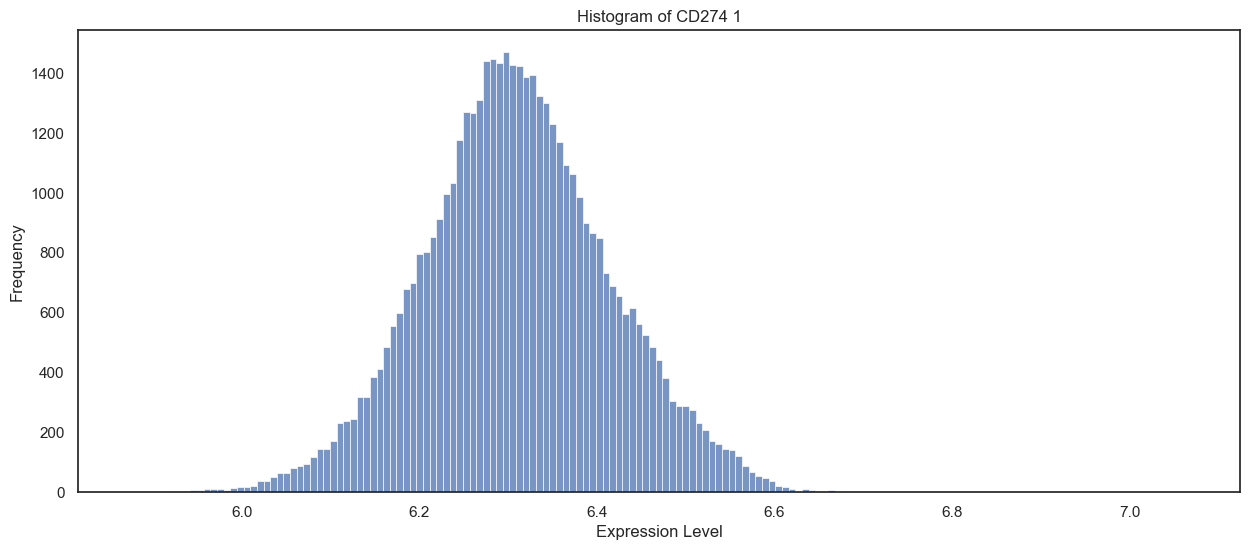

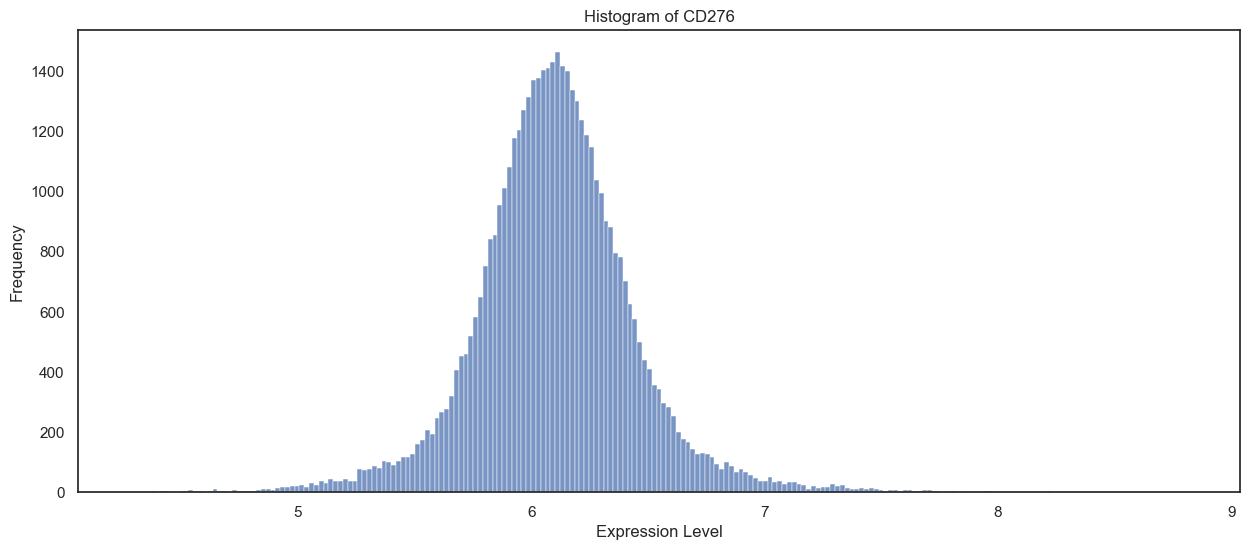

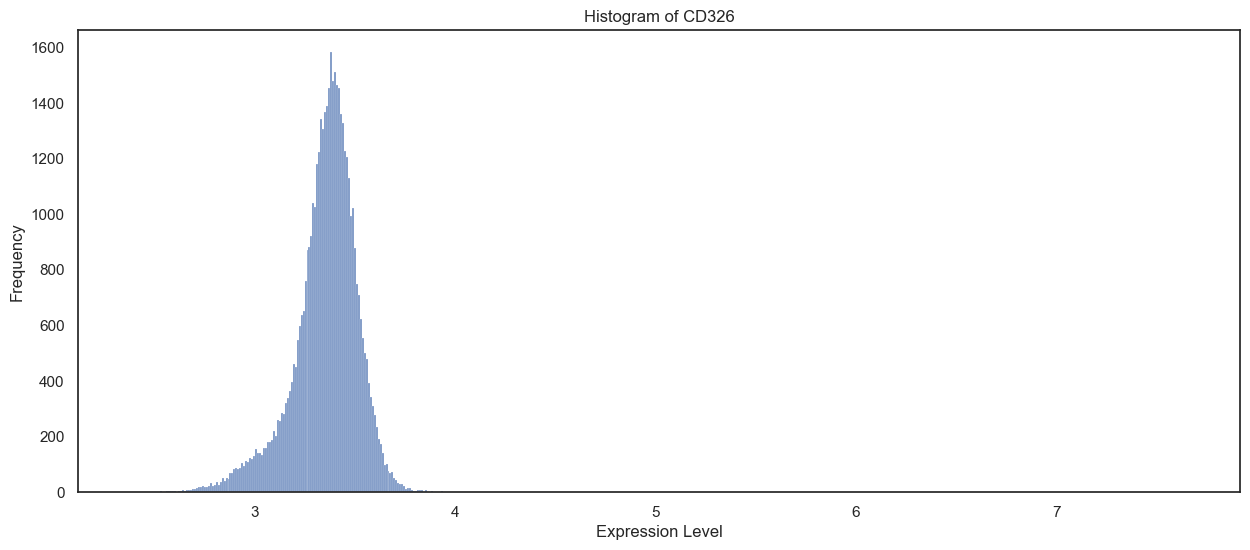

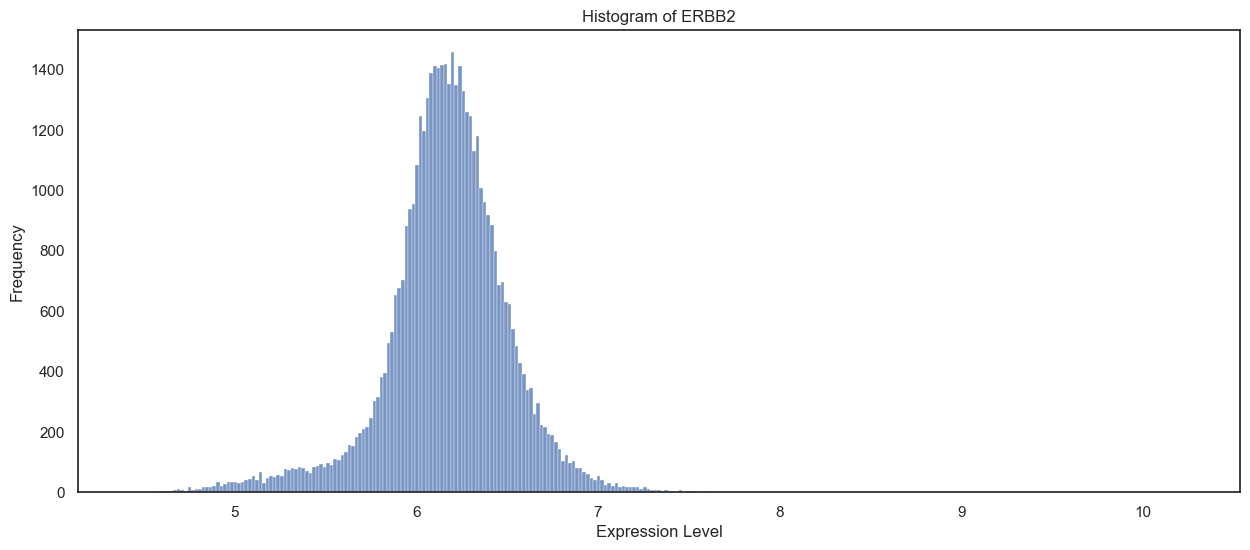

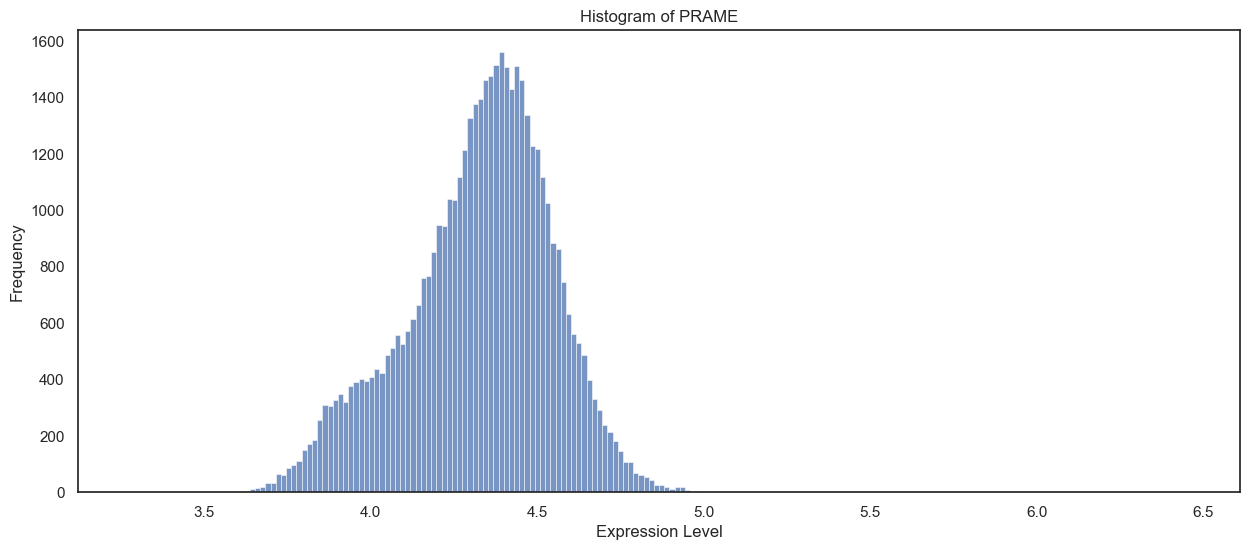

In [134]:
adata_select = adata_145[adata_145.obs["exp_name"] == "Run145_ROI14", tumor_markers].copy()
sc.pp.log1p(adata_select)
#plot histogram of each marker here
for marker in tumor_markers:
    plt.figure(figsize=(15, 6))
    sns.histplot(adata_select.X[:, adata_select.var_names == marker].flatten())
    plt.title(f"Histogram of {marker}")
    plt.xlabel("Expression Level")
    plt.ylabel("Frequency")
    plt.show()

In [166]:
sm.pl.napariGater(
image_path = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/images/Run145_ROI13_tumor_stacked.tif",
adata = adata_145,
log = True,
x_coordinate = "Cell Center X",
y_coordinate = "Cell Center Y",
imageid = "exp_name",
channel_names = channel_names,
subset = "Run145_ROI13"
)

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_84098/4075009803.py:1: UserWarning:

NOTE: napariGater() is currently in beta testing. If you encounter any issues, please report them at: https://github.com/labsyspharm/scimap/issues



Initializing...
Loading image data...
Calculating contrast settings...
Initialization completed in 0.00 seconds
Opening napari viewer...
Napari viewer initialized in 3.56 seconds


In [235]:
adata_141.var_names

Index(['ACTIN', 'ARGINASE1', 'BCL2', 'BETAACTIN', 'BETACATENIN', 'CALPONIN',
       'CD107A', 'CD107B', 'CD11B', 'CD11C', 'CD123', 'CD134', 'CD138', 'CD14',
       'CD15', 'CD16', 'CD163', 'CD1C', 'CD209', 'CD20CYTOPLASMIC', 'CD223',
       'CD223 1', 'CD274', 'CD274 1', 'CD276', 'CD3', 'CD31', 'CD324', 'CD326',
       'CD38', 'CD39', 'CD4', 'CD44', 'CD45 1', 'CD45RA', 'CD45RB', 'CD45RO',
       'CD56', 'CD57', 'CD66', 'CD66B', 'CD68', 'CD79A', 'CD8A', 'CD90',
       'CLEAVEDPARP1', 'COLLAGENI', 'COLLAGENIV', 'CTLA4CD152', 'CYTOKERATIN',
       'CYTOKERATIN14', 'CYTOKERATIN19', 'CYTOKERATIN20', 'CYTOKERATIN5',
       'CYTOKERATIN56', 'CYTOKERATIN7', 'ERBB2', 'FOXP3', 'FSP1', 'GALECTIN9',
       'GALECTIN9 1', 'GLUT1', 'HLAABC', 'HLADR', 'KI67', 'MART1',
       'MASTCELLTRYPTASE', 'MRP14', 'NUT 1', 'NYESOCTAG1B', 'P16', 'P16 1',
       'P53', 'PCNA', 'PDGFRBETA', 'PODOPLANIN', 'PRAME', 'PSANCAM', 'S100',
       'S100A8', 'SYNAPTOPHYSIN', 'TIM3', 'TIM3 1', 'VIMENTIN', 'VISTA'],
      dty

In [232]:
a, b, c = stack_images("/Volumes/T7/Run141/ROI3", channels_list=tumor_markers_4_images, output_path=results_dir / "images" / f"Run141_ROI3_tumor_stacked.tif")
b

['C-000_S-000_S_DAPI_R-01_W-A-1_ROI-03_A-DAPI.tif',
 'C-013_S-000_S_PE_R-01_W-A-1_ROI-03_A-CD274_C-REA1308.tif',
 'C-039_S-000_S_PE_R-01_W-A-1_ROI-03_A-CD274_C-REA1308.tif',
 'C-055_S-000_S_PE_R-01_W-A-1_ROI-03_A-CD276_C-B7H3.tif',
 'C-058_S-000_S_APC_R-01_W-A-1_ROI-03_A-CD276_C-SP206.tif',
 'C-034_S-000_S_PE_R-01_W-A-1_ROI-03_A-CD326_C-REA1311.tif',
 'C-021_S-000_S_PE_R-01_W-A-1_ROI-03_A-ErbB2_C-REA1315.tif',
 'C-056_S-000_S_APC_R-01_W-A-1_ROI-03_A-PRAME_C-EPR20330.tif']

In [237]:
sm.pl.napariGater(
image_path = "/Volumes/T7/Run141/ROI3/C-013_S-000_S_PE_R-01_W-A-1_ROI-03_A-CD274_C-REA1308.tif",
adata = adata_141,
log = True,
x_coordinate = "Cell Center X",
y_coordinate = "Cell Center Y",
imageid = "exp_name",
channel_names = channel_names,
subset = "Run145_ROI13"
)

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_84098/3120905703.py:1: UserWarning:

NOTE: napariGater() is currently in beta testing. If you encounter any issues, please report them at: https://github.com/labsyspharm/scimap/issues



Initializing...
Loading image data...
Calculating contrast settings...
New channel configuration detected for Run145_ROI13. Updating contrast settings.


Saved contrast settings for Run145_ROI13 with 7 channels
Initialization completed in 0.01 seconds
Opening napari viewer...


ValueError: length of [(0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0)] must equal 5062

In [143]:
tumor_gates = adata_145.uns["gates"][adata_145.uns["gates"].index.isin(tumor_markers)]

In [148]:
#This will come to a halt...

,Run145_ROI3,Run145_ROI10,Run145_ROI17,Run145_ROI11,Run145_ROI1,Run145_ROI9,Run145_ROI14,Run145_ROI13
CD274,6.30,6.85,6.641842,6.50,6.8,6.641842,6.64,7.5
CD274 1,7.35,6.40,6.553424,6.75,7.4,6.553424,6.90,6.8
CD276,6.70,6.60,6.482663,6.40,7.0,6.482663,6.20,5.2
CD326,5.85,5.65,5.211196,5.80,6.1,5.211196,5.21,6.0
ERBB2,6.45,7.05,6.805457,6.80,7.8,6.805457,6.00,5.6
PRAME,5.70,5.50,5.100134,5.45,6.5,5.100134,5.10,4.9


In [156]:
adata_145_excluded = adata_145[~adata_145.obs["exp_name"].isin(["Run145_ROI9", "Run145_ROI17"])].copy()

ArrayView([[ 305.8494873 ],
           [ 252.9744873 ],
           [ 344.54830933],
           ...,
           [1417.66113281],
           [1255.54211426],
           [1434.84094238]])

In [185]:
expr

ArrayView([323.65252686, 364.85714722, 391.28460693, ...,  57.14654541,
            47.08673096,  56.32933044])

In [184]:
for marker in tumor_markers:
    
    # Create the positivity column
    col_name = f"{marker}_positive"
    adata_145_excluded.obs[col_name] = False
    
    # Get expression vector
    expr = adata_145_excluded[:, marker].X.flatten()
    print(marker)

CD274
CD274 1
CD276
CD326
ERBB2
PRAME


In [190]:
tumor_gates

,Run145_ROI3,Run145_ROI10,Run145_ROI17,Run145_ROI11,Run145_ROI1,Run145_ROI9,Run145_ROI14,Run145_ROI13
CD274,6.30,6.85,6.641842,6.50,6.8,6.641842,6.64,7.5
CD274 1,7.35,6.40,6.553424,6.75,7.4,6.553424,6.90,6.8
CD276,6.70,6.60,6.482663,6.40,7.0,6.482663,6.20,5.2
CD326,5.85,5.65,5.211196,5.80,6.1,5.211196,5.21,6.0
ERBB2,6.45,7.05,6.805457,6.80,7.8,6.805457,6.00,5.6
PRAME,5.70,5.50,5.100134,5.45,6.5,5.100134,5.10,4.9


In [192]:
#make adata log1p
sc.pp.log1p(adata_145_excluded)

In [194]:
for marker in tumor_markers:
    
    # Create the positivity column
    col_name = f"{marker}_positive"
    adata_145_excluded.obs[col_name] = False
    
    # Get expression vector
    expr = adata_145_excluded[:, marker].X.flatten()
    
    # Loop over ROIs
    for exp_name in adata_145_excluded.obs["exp_name"].unique():
        
        exp_gate = tumor_gates.loc[marker, exp_name]
        
        # Mask of cells belonging to this ROI and above the gate
        mask = (
            (adata_145_excluded.obs["exp_name"] == exp_name) &
            (expr >= exp_gate)
        )
        
        adata_145_excluded.obs.loc[mask, col_name] = True


In [203]:

rows = []

for marker in tumor_markers:
    col = f"{marker}_positive"
    
    # compute per-sample percentage
    perc = (
        adata_145_excluded.obs
        .groupby("exp_name")[col]
        .mean() * 100
    )
    
    # convert to long format rows
    for exp_name, pct in perc.items():
        rows.append({
            "exp_name": exp_name,
            "marker": marker,
            "percentage_positive": pct
        })

long_df = pd.DataFrame(rows)


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_84098/2439656985.py:9: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [204]:
rows = []

for marker in tumor_markers:
    col = f"{marker}_positive"
    
    # group by sample AND cell type
    grouped = (
        adata_145_excluded.obs
        .groupby(["exp_name", "cell_type"])[col]
        .mean() * 100
    )
    
    # convert to rows
    for (exp_name, cell_type), pct in grouped.items():
        rows.append({
            "exp_name": exp_name,
            "cell_type": cell_type,
            "marker": marker,
            "percentage_positive": pct
        })

long_df_celltype = pd.DataFrame(rows)


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_84098/366459144.py:9: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [200]:
pos_percentages = adata_145_excluded.obs.groupby(["exp_name", "CD274_positive"]).size().unstack(fill_value=0)
pos_percentages

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_84098/2674525434.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



CD274_positive,False,True
exp_name,,
Run145_ROI1,7589,149
Run145_ROI3,15731,376
Run145_ROI10,47821,375
Run145_ROI11,46356,31
Run145_ROI13,17331,18
Run145_ROI14,47421,14


In [13]:
adata_145_subset = adata_145[:, tumor_markers].copy()
adata_145_subset = adata_145_subset[adata_145_subset.obs.rois == 3, :]
adata_145_subset.raw = adata_145_subset.copy()

In [15]:
viewer = napari.Viewer()
viewer.add_image(img, channel_axis=0, name=channel_names)

[<Image layer 'DAPI' at 0x521f46ad0>,
 <Image layer 'CD274' at 0x5208fc5b0>,
 <Image layer 'CD274 [1]' at 0x51ff4c490>,
 <Image layer 'CD276' at 0x4de864520>,
 <Image layer 'CD326' at 0x4de804520>,
 <Image layer 'ErbB2' at 0x4de5a4be0>,
 <Image layer 'PRAME' at 0x4de62c970>]

In [25]:
img.shape

(7, 7603, 12476)

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_14427/4282643850.py:1: UserWarning:

NOTE: napariGater() is currently in beta testing. If you encounter any issues, please report them at: https://github.com/labsyspharm/scimap/issues



Initializing...
Loading image data...
Calculating contrast settings...
New channel configuration detected for 145. Updating contrast settings.


Saved contrast settings for 145 with 5 channels
Initialization completed in 0.12 seconds
Opening napari viewer...
Napari viewer initialized in 1.64 seconds


In [372]:
#add dapi image to viewer
napari.

Viewer(camera=Camera(center=(0.0, 5281.564920737027, 7449.509869061257), zoom=0.11342450200270046, angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True, orientation=(<DepthAxisOrientation.TOWARDS: 'towards'>, <VerticalAxisOrientation.DOWN: 'down'>, <HorizontalAxisOrientation.RIGHT: 'right'>)), cursor=Cursor(position=(5180.175856413265, 2913.4528515272264), viewbox=(0, 0), scaled=True, style=<CursorStyle.STANDARD: 'standard'>, size=1.0), dims=Dims(ndim=2, ndisplay=2, order=(0, 1), axis_labels=('0', '1'), rollable=(True, True), range=(RangeTuple(start=0.0, stop=7607.0, step=1.0), RangeTuple(start=0.0, stop=9414.0, step=1.0)), margin_left=(0.0, 0.0), margin_right=(0.0, 0.0), point=(3803.0, 4707.0), last_used=0), grid=GridCanvas(stride=1, shape=(-1, -1), enabled=False, spacing=0.0), layers=[<Image layer 'CD274' at 0x7872407f0>, <Image layer 'DAPI' at 0x787242b30>, <Image layer 'CD276' at 0xc5d376b90>], help='', status='Ready', tooltip=Tooltip(visible=False, text=''), t

In [312]:
#Write the gates as CSV
gates_df = adata.uns["gates"]
gates_df.to_csv("/Users/jawadalaaedeen/Desktop/Run145_ROI1_gates.csv")

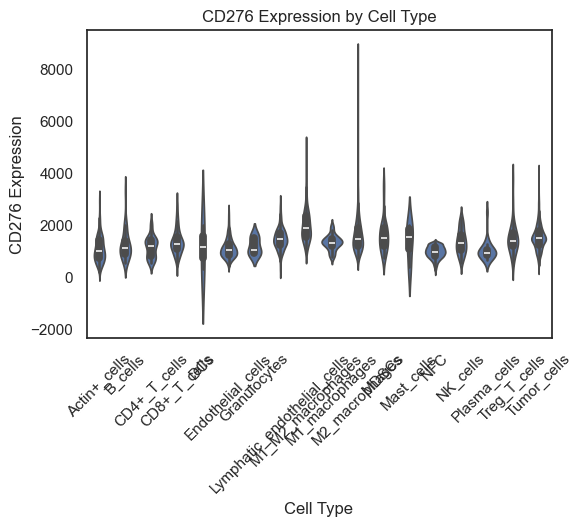

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

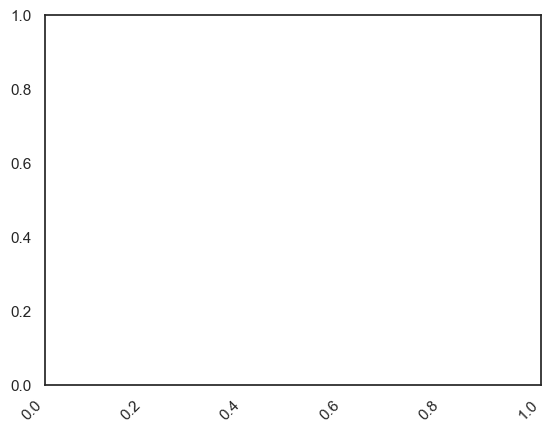

In [307]:
#Now plot CD276 across cell type expression
plt.figure(figsize=(6,4))
sns.violinplot(x="cell_type", y=adata.X[:, adata.var_names.get_loc("CD276")], data=adata.obs)
plt.title("CD276 Expression by Cell Type")
plt.xlabel("Cell Type")
plt.ylabel("CD276 Expression")
plt.xticks(rotation=45)
plt.show()
#make the x-axis labels right
plt.xticks(rotation=45, ha='right')

In [293]:
adata.uns["gates"].values[0][0]


880.0

In [294]:
adata.uns["gates"]
#Define cells as positive if they are above the threshold in each marker in adata.uns["gates"]
for i, marker in enumerate(channel_names):
    gate = adata.uns["gates"].values[i][0]
    adata.obs[f"{marker}_positive"] = adata.X[:, adata.var_names.get_loc(marker)] > gate

In [303]:
#table of CD276 positive and negatice cells
#percentage based on cell type of CD276 cell types
cd276_table = pd.crosstab(adata.obs["cell_type"], adata.obs["CD276_positive"], normalize="index") * 100
print(cd276_table)

CD276_positive                    False      True 
cell_type                                         
Actin+_cells                  91.978610   8.021390
B_cells                       82.352941  17.647059
CD4+_T_cells                  92.500000   7.500000
CD8+_T_cells                  83.333333  16.666667
DCs                           50.000000  50.000000
Endothelial_cells             93.827160   6.172840
Granulocytes                 100.000000   0.000000
Lymphatic_endothelial_cells   79.381443  20.618557
M1_M2_macrophages             43.386243  56.613757
M1_macrophages                92.682927   7.317073
M2_macrophages                68.333333  31.666667
MDSCs                         63.636364  36.363636
Mast_cells                    50.000000  50.000000
NFC                          100.000000   0.000000
NK_cells                      78.947368  21.052632
Plasma_cells                  95.238095   4.761905
Treg_T_cells                  79.487179  20.512821
Tumor_cells                   7

In [186]:
viewer = napari.Viewer()
img = tifffile.imread(os.path.join(images_folder, cd274))
viewer.add_image(img, name='CD274')
img = tifffile.imread(os.path.join(images_folder, dapi))
viewer.add_image(img, name='DAPI')
img = tifffile.imread(os.path.join(images_folder, cd276))
viewer.add_image(img, name='CD276')

<Image layer 'CD276' at 0xc5d376b90>

In [164]:
sm.pl.gate_finder(
image_path="/Users/jawadalaaedeen/Desktop/cd223_fixed.tif",
adata=adata,
layer="raw",
marker_of_interest="CD223",
x_coordinate='Cell Center X',
y_coordinate='Cell Center Y',
imageid="run",
from_gate=0,
to_gate=50,
increment=10,
channel_names=["CD223"]
)

['/Users/jawadalaaedeen/Desktop/PhD/NMC/preprocessed/Run145_ROI1',
 '/Users/jawadalaaedeen/Desktop/PhD/NMC/preprocessed/Run145_ROI3',
 '/Users/jawadalaaedeen/Desktop/PhD/NMC/preprocessed/Run145_ROI9',
 '/Users/jawadalaaedeen/Desktop/PhD/NMC/preprocessed/Run145_ROI10',
 '/Users/jawadalaaedeen/Desktop/PhD/NMC/preprocessed/Run145_ROI11',
 '/Users/jawadalaaedeen/Desktop/PhD/NMC/preprocessed/Run145_ROI13',
 '/Users/jawadalaaedeen/Desktop/PhD/NMC/preprocessed/Run145_ROI14',
 '/Users/jawadalaaedeen/Desktop/PhD/NMC/preprocessed/Run145_ROI17']

In [ ]:
#do the same with the images from T7
run141_images_dirs = os.listdir("/Volumes/T7/Run141/ROI3")
#i want the file that contains "CD223" and ends with ".tiff"
cd223_files = [f for f in run141_images_dirs if "CD223" in f]

Text(0, 0.5, 'Frequency')

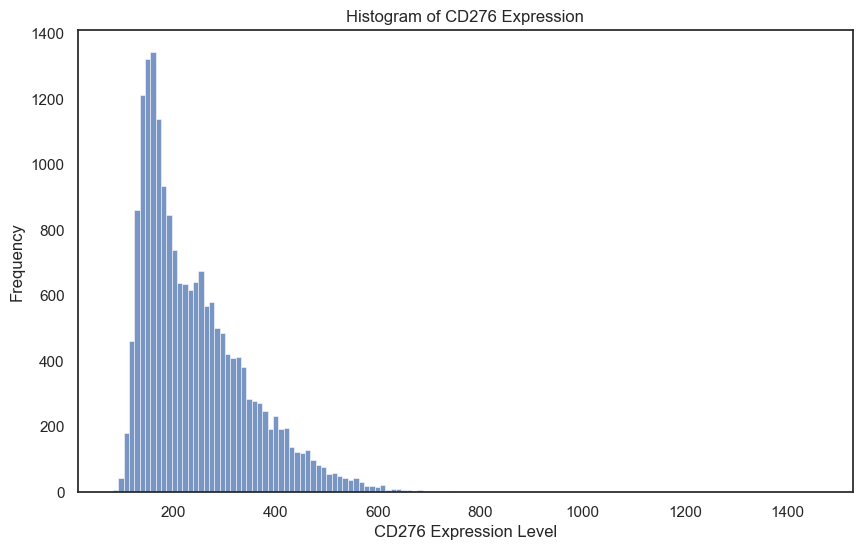

In [18]:
adata = sc.read_h5ad(adata_dirs[1] + "/adata.h5ad")
#turn to a dataframe
df = adata.to_df()
#make histogram out of CD223
plt.figure(figsize=(10,6))
sns.histplot(df['CD276'], log_scale=False)
plt.title('Histogram of CD276 Expression')
plt.xlabel('CD276 Expression Level')
plt.ylabel('Frequency')

In [43]:
erbb2_files = [f for f in run141_images_dirs if "Er" in f]
erbb2_files

['C-021_S-000_S_PE_R-01_W-A-1_ROI-03_A-ErbB2_C-REA1315.tif']

In [44]:
img = tifffile.imread("/Volumes/T7/Run141/ROI3/C-055_S-000_S_PE_R-01_W-A-1_ROI-03_A-CD276_C-B7H3.tif")
viewer = napari.Viewer()
viewer.add_image(img, name='CD276')
img_2 = tifffile.imread("/Volumes/T7/Run141/ROI3/C-000_S-000_S_DAPI_R-01_W-A-1_ROI-03_A-DAPI.tif")
viewer.add_image(img_2, name='DAPI')
img_3 = tifffile.imread("/Volumes/T7/Run141/ROI3/C-013_S-000_S_PE_R-01_W-A-1_ROI-03_A-CD274_C-REA1308.tif")
viewer.add_image(img_3, name='CD274')
img_4 = tifffile.imread("/Volumes/T7/Run141/ROI3/C-021_S-000_S_PE_R-01_W-A-1_ROI-03_A-ErbB2_C-REA1315.tif")
viewer.add_image(img_4, name='ErbB2')

<Image layer 'ErbB2' at 0x39182d870>

In [68]:
run141_images_dirs = os.listdir("/Volumes/T7/Run141/ROI8")
[f for f in run141_images_dirs if "Arg" in f]

['C-048_S-000_S_APC_R-01_W-A-1_ROI-08_A-Arginase-1_C-2.tif']

In [ ]:
img = tifffile.imread("/Volumes/T7/Run141/ROI8/C-055_S-000_S_PE_R-01_W-A-1_ROI-08_A-CD276_C-B7H3.tif")
viewer = napari.Viewer()
viewer.add_image(img, name='CD276')
img_2 = tifffile.imread("/Volumes/T7/Run141/ROI8/C-000_S-000_S_DAPI_R-01_W-A-1_ROI-08_A-DAPI.tif")
viewer.add_image(img_2, name='DAPI')
img_3 = tifffile.imread("/Volumes/T7/Run141/ROI8/C-013_S-000_S_PE_R-01_W-A-1_ROI-08_A-CD274_C-REA1308.tif")
viewer.add_image(img_3, name='CD274')
img_4 = tifffile.imread("/Volumes/T7/Run141/ROI8/C-021_S-000_S_PE_R-01_W-A-1_ROI-08_A-ErbB2_C-REA1315.tif")
viewer.add_image(img_4, name='ErbB2')
img_5 = tifffile.imread("/Volumes/T7/Run141/ROI8/C-004_S-000_S_PE_R-01_W-A-1_ROI-08_A-TIM3_C-REAL818.tif")
viewer.add_image(img_5, name='TIM3')

KeyboardInterrupt: 

: 

In [69]:
img_6 = tifffile.imread("/Volumes/T7/Run141/ROI8/C-048_S-000_S_APC_R-01_W-A-1_ROI-08_A-Arginase-1_C-2.tif")
viewer.add_image(img_6, name='Arginase-1')

<Image layer 'Arginase-1' at 0x44022e0e0>

In [55]:
run141_images_dirs = os.listdir("/Volumes/T7/Run141/ROI4")
[f for f in run141_images_dirs if "CD20" in f]

['C-001_S-000_S_APC_R-01_W-A-1_ROI-04_A-CD209_C-REAL690.tif',
 'C-002_S-000_S_APC_R-01_W-A-1_ROI-04_A-CD20Cytoplasmic_C-REAL649.tif',
 'C-032_S-000_S_PE_R-01_W-A-1_ROI-04_A-CD204_C-REA460.tif']

In [20]:
viewer = napari.Viewer()
img_2 = tifffile.imread("/Volumes/T7/Run141/ROI4/C-000_S-000_S_DAPI_R-01_W-A-1_ROI-04_A-DAPI.tif")
viewer.add_image(img_2, name='DAPI')
img_4 = tifffile.imread("/Volumes/T7/Run141/ROI4/C-021_S-000_S_PE_R-01_W-A-1_ROI-04_A-ErbB2_C-REA1315.tif")
viewer.add_image(img_4, name='ErbB2')
img_5 = tifffile.imread("/Volumes/T7/Run141/ROI4/C-048_S-000_S_APC_R-01_W-A-1_ROI-04_A-Arginase-1_C-2.tif")
viewer.add_image(img_5, name='Arginase-1')
img_7 = tifffile.imread("/Volumes/T7/Run141/ROI4/C-012_S-000_S_FITC_R-01_W-A-1_ROI-04_A-CD8a_C-REA1024.tif")
viewer.add_image(img_7, name='CD8')


<Image layer 'CD276' at 0x3805044c0>

2025-11-08 02:38:15.822 Python[14427:3976155] TSMSendMessageToUIServer: CFMessagePortSendRequest FAILED(-1) to send to port com.apple.tsm.uiserver
2025-11-08 02:38:15.822 Python[14427:3976155] TSMSendMessageToUIServer: CFMessagePortSendRequest FAILED(-1) to send to port com.apple.tsm.uiserver
2025-11-08 02:38:15.822 Python[14427:3976155] TSMSendMessageToUIServer: CFMessagePortSendRequest FAILED(-1) to send to port com.apple.tsm.uiserver
2025-11-08 02:38:15.824 Python[14427:3976155] TSMSendMessageToUIServer: CFMessagePortSendRequest FAILED(-1) to send to port com.apple.tsm.uiserver
2025-11-08 02:38:15.824 Python[14427:3976155] TSMSendMessageToUIServer: CFMessagePortSendRequest FAILED(-1) to send to port com.apple.tsm.uiserver
2025-11-08 02:38:15.824 Python[14427:3976155] TSMSendMessageToUIServer: CFMessagePortSendRequest FAILED(-1) to send to port com.apple.tsm.uiserver
2025-11-08 02:38:15.824 Python[14427:3976155] TSMSendMessageToUIServer: CFMessagePortSendRequest FAILED(-1) to send to

In [66]:
run141_images_dirs = os.listdir("/Volumes/T7/Run141/ROI17")
[f for f in run141_images_dirs if "S100" in f]

['C-046_S-000_S_APC_R-01_W-A-1_ROI-17_A-S100A8_C-REA917.tif',
 'C-051_S-000_S_PE_R-01_W-A-1_ROI-17_A-S100B_C-REAL1328.tif']

In [63]:
viewer = napari.Viewer()
img_2 = tifffile.imread("/Volumes/T7/Run141/ROI17/C-000_S-000_B_DAPI_R-01_W-A-1_ROI-17_A-DAPI.tif")
viewer.add_image(img_2, name='DAPI')
img_4 = tifffile.imread("/Volumes/T7/Run141/ROI17/C-021_S-000_S_PE_R-01_W-A-1_ROI-17_A-ErbB2_C-REA1315.tif")
viewer.add_image(img_4, name='ErbB2')
img_5 = tifffile.imread("/Volumes/T7/Run141/ROI17/C-048_S-000_S_APC_R-01_W-A-1_ROI-17_A-Arginase-1_C-2.tif")
viewer.add_image(img_5, name='Arginase-1')
img_7 = tifffile.imread("/Volumes/T7/Run141/ROI17/C-012_S-000_S_FITC_R-01_W-A-1_ROI-17_A-CD8a_C-REA1024.tif")
viewer.add_image(img_7, name='CD8')

<Image layer 'CD8' at 0x43c1aed40>

In [82]:
run141_images_dirs = os.listdir("/Volumes/T7/Run141/ROI16")
[f for f in run141_images_dirs if "CD11b" in f]

['C-017_S-000_S_PE_R-01_W-A-1_ROI-16_A-CD11b_C-REA1321.tif']

In [77]:
viewer = napari.Viewer()
img_2 = tifffile.imread("/Volumes/T7/Run141/ROI16/C-000_S-000_S_DAPI_R-01_W-A-1_ROI-16_A-DAPI.tif")
viewer.add_image(img_2, name='DAPI')
img_4 = tifffile.imread("/Volumes/T7/Run141/ROI16/C-021_S-000_S_PE_R-01_W-A-1_ROI-16_A-ErbB2_C-REA1315.tif")
viewer.add_image(img_4, name='ErbB2')
img_5 = tifffile.imread("/Volumes/T7/Run141/ROI16/C-048_S-000_S_APC_R-01_W-A-1_ROI-16_A-Arginase-1_C-2.tif")
viewer.add_image(img_5, name='Arginase-1')
img_7 = tifffile.imread("/Volumes/T7/Run141/ROI16/C-058_S-000_S_APC_R-01_W-A-1_ROI-16_A-CD276_C-SP206.tif")
viewer.add_image(img_7, name='CD276')

<Image layer 'CD276' at 0x605f3c310>

In [83]:
img_7 = tifffile.imread("/Volumes/T7/Run141/ROI16/C-017_S-000_S_PE_R-01_W-A-1_ROI-16_A-CD11b_C-REA1321.tif")
viewer.add_image(img_7, name='CD11b')

<Image layer 'CD11b' at 0x604631660>

In [102]:
run141_images_dirs = os.listdir("/Volumes/T7/Run141/ROI8")
[f for f in run141_images_dirs if "CD64" in f]

[]

In [88]:
viewer = napari.Viewer()
img_2 = tifffile.imread("/Volumes/T7/Run141/ROI8/C-000_S-000_S_DAPI_R-01_W-A-1_ROI-08_A-DAPI.tif")
viewer.add_image(img_2, name='DAPI', colormap="blue", blending='additive')
img_4 = tifffile.imread("/Volumes/T7/Run141/ROI8/C-021_S-000_S_PE_R-01_W-A-1_ROI-08_A-ErbB2_C-REA1315.tif")
viewer.add_image(img_4, name='ErbB2', colormap="red", blending='additive')
img_5 = tifffile.imread("/Volumes/T7/Run141/ROI8/C-048_S-000_S_APC_R-01_W-A-1_ROI-08_A-Arginase-1_C-2.tif")
viewer.add_image(img_5, name='Arginase-1', colormap="green", blending='additive')
img_7 = tifffile.imread("/Volumes/T7/Run141/ROI8/C-055_S-000_S_PE_R-01_W-A-1_ROI-08_A-CD276_C-B7H3.tif")
viewer.add_image(img_7, name='CD276', colormap="magenta", blending='additive')

<Image layer 'CD276' at 0x5c77ac340>

In [90]:
img_5 = tifffile.imread("/Volumes/T7/Run141/ROI8/C-013_S-000_S_PE_R-01_W-A-1_ROI-08_A-CD274_C-REA1308.tif")
viewer.add_image(img_5, name='CD274', colormap="yellow", blending='additive')
img_7 = tifffile.imread("/Volumes/T7/Run141/ROI8/C-039_S-000_S_PE_R-01_W-A-1_ROI-08_A-CD274_C-REA1308.tif")
viewer.add_image(img_7, name='CD274 (1)', colormap="yellow", blending='additive')

<Image layer 'CD274 (1)' at 0x60425efe0>

In [93]:
img_7 = tifffile.imread("/Volumes/T7/Run141/ROI8/C-046_S-000_S_APC_R-01_W-A-1_ROI-08_A-S100A8_C-REA917.tif")
viewer.add_image(img_7, name='S100A8', colormap="yellow", blending='additive')
img_7 = tifffile.imread("/Volumes/T7/Run141/ROI8/C-051_S-000_S_PE_R-01_W-A-1_ROI-08_A-S100B_C-REAL1328.tif")
viewer.add_image(img_7, name='S100B', colormap="yellow", blending='additive')
img_7 = tifffile.imread("/Volumes/T7/Run141/ROI8/C-017_S-000_S_PE_R-01_W-A-1_ROI-08_A-CD11b_C-REA1321.tif")
viewer.add_image(img_7, name='CD11b', colormap="yellow", blending='additive')
img_7 = tifffile.imread("/Volumes/T7/Run141/ROI8/C-030_S-000_S_PE_R-01_W-A-1_ROI-08_A-CD11c_C-REA1310.tif")
viewer.add_image(img_7, name='CD11c', colormap="yellow", blending='additive')

<Image layer 'CD11c' at 0x3b8c1aef0>

In [96]:
img_7 = tifffile.imread("/Volumes/T7/Run141/ROI8/C-058_S-000_S_APC_R-01_W-A-1_ROI-08_A-CD276_C-SP206.tif")
viewer.add_image(img_7, name='CD276 (1)', colormap="magenta", blending='additive')

<Image layer 'CD276 (1)' at 0x7816f13f0>

In [122]:
run141_images_dirs = os.listdir("/Volumes/T7/Run141/ROI19")
[f for f in run141_images_dirs if "CD11" in f]

['C-017_S-000_S_PE_R-01_W-A-1_ROI-19_A-CD11b_C-REA1321.tif',
 'C-030_S-000_S_PE_R-01_W-A-1_ROI-19_A-CD11c_C-REA1310.tif',
 'C-050_S-000_S_APC_R-01_W-A-1_ROI-19_A-CD117_C-REA787.tif']

In [115]:
viewer = napari.Viewer()
img_2 = tifffile.imread("/Volumes/T7/Run141/ROI19/C-000_S-000_S_DAPI_R-01_W-A-1_ROI-19_A-DAPI.tif")
viewer.add_image(img_2, name='DAPI', colormap="blue", blending='additive')
img_4 = tifffile.imread("/Volumes/T7/Run141/ROI19/C-021_S-000_S_PE_R-01_W-A-1_ROI-19_A-ErbB2_C-REA1315.tif")
viewer.add_image(img_4, name='ErbB2', colormap="red", blending='additive')
img_5 = tifffile.imread("/Volumes/T7/Run141/ROI19/C-048_S-000_S_APC_R-01_W-A-1_ROI-19_A-Arginase-1_C-2.tif")
viewer.add_image(img_5, name='Arginase-1', colormap="green", blending='additive')
img_7 = tifffile.imread("/Volumes/T7/Run141/ROI19/C-058_S-000_S_APC_R-01_W-A-1_ROI-19_A-CD276_C-SP206.tif")
viewer.add_image(img_7, name='CD276', colormap="magenta", blending='additive')

<Image layer 'CD276' at 0x77ecbf1c0>

In [118]:
img_7 = tifffile.imread("/Volumes/T7/Run141/ROI19/C-013_S-000_S_PE_R-01_W-A-1_ROI-19_A-CD274_C-REA1308.tif")
viewer.add_image(img_7, name='CD274', colormap="magenta", blending='additive')
img_7 = tifffile.imread("/Volumes/T7/Run141/ROI19/C-039_S-000_S_PE_R-01_W-A-1_ROI-19_A-CD274_C-REA1308.tif")
viewer.add_image(img_7, name='CD274', colormap="magenta", blending='additive')

<Image layer 'CD274 [1]' at 0xa4657dd80>

2025-11-10 15:17:27.162 Python[14427:3976155] TSMSendMessageToUIServer: CFMessagePortSendRequest FAILED(-1) to send to port com.apple.tsm.uiserver


In [123]:
img_7 = tifffile.imread("/Volumes/T7/Run141/ROI19/C-017_S-000_S_PE_R-01_W-A-1_ROI-19_A-CD11b_C-REA1321.tif")
viewer.add_image(img_7, name='CD11b', colormap="green", blending='additive')

<Image layer 'CD11b' at 0x780dd5f90>

In [145]:
run141_images_dirs = os.listdir("/Volumes/T7/Run145/ROI11")
[f for f in run141_images_dirs if "CD8" in f]

['C-002_S-000_S_FITC_R-01_W-A-1_ROI-11_A-CD8a_C-REA1024.tif']

In [130]:
viewer = napari.Viewer()
img_2 = tifffile.imread("/Volumes/T7/Run145/ROI11/C-000_S-000_S_DAPI_R-01_W-A-1_ROI-11_A-DAPI.tif")
viewer.add_image(img_2, name='DAPI', colormap="blue", blending='additive')
img_4 = tifffile.imread("/Volumes/T7/Run145/ROI11/C-064_S-000_S_PE_R-01_W-A-1_ROI-11_A-ErbB2_C-REA1315.tif")
viewer.add_image(img_4, name='ErbB2', colormap="red", blending='additive')
img_5 = tifffile.imread("/Volumes/T7/Run145/ROI11/C-059_S-000_S_APC_R-01_W-A-1_ROI-11_A-Arginase-1_C-REAL1137.tif")
viewer.add_image(img_5, name='Arginase-1', colormap="green", blending='additive')
img_7 = tifffile.imread("/Volumes/T7/Run145/ROI11/C-077_S-000_S_APC_R-01_W-A-1_ROI-11_A-CD276_C-SP206.tif")
viewer.add_image(img_7, name='CD276', colormap="magenta", blending='additive')

<Image layer 'CD276' at 0x6909af580>

In [146]:
img_7 = tifffile.imread("/Volumes/T7/Run145/ROI11/C-002_S-000_S_FITC_R-01_W-A-1_ROI-11_A-CD8a_C-REA1024.tif")
viewer.add_image(img_7, name='CD8', colormap="green", blending='additive')

<Image layer 'CD8' at 0xa465ded10>

In [ ]:
#Let's gate all our images...


In [124]:
sm.pl.gate_finder(
image_path="/Users/jawadalaaedeen/Desktop/cd223_fixed.tif",
adata=adata,
layer="raw",
marker_of_interest="CD223",
x_coordinate='Cell Center X',
y_coordinate='Cell Center Y',
imageid="run",
from_gate=0,
to_gate=50,
increment=10,
channel_names=["CD223"]
)

NameError: name 'adata' is not defined

In [45]:
adata_unified = sc.read_h5ad(results_dir/"adata_unified.h5ad")
#arcsinh transform
adata_unified.X = np.arcsinh(adata_unified.X)

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_14427/4261277764.py:30: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_14427/4261277764.py:31: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_14427/4261277764.py:30: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_14427/4261277764.py:31: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_14427/4261277764.py:30: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.

/var/folde

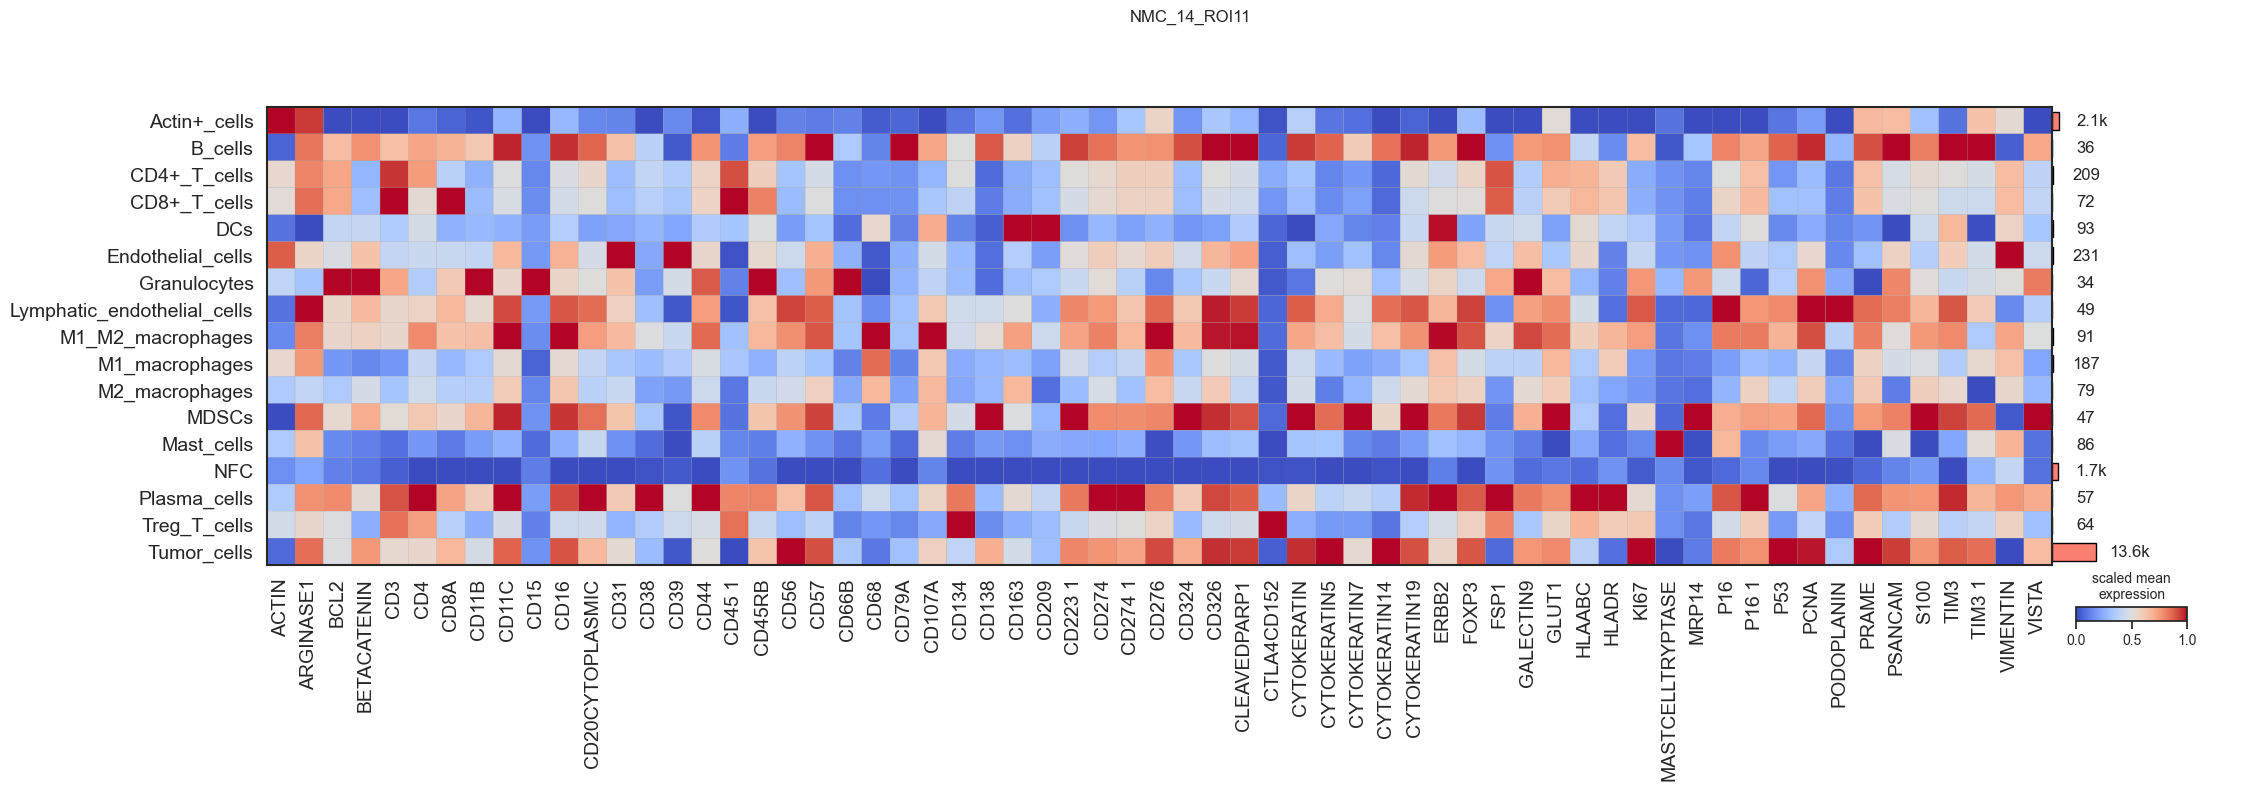

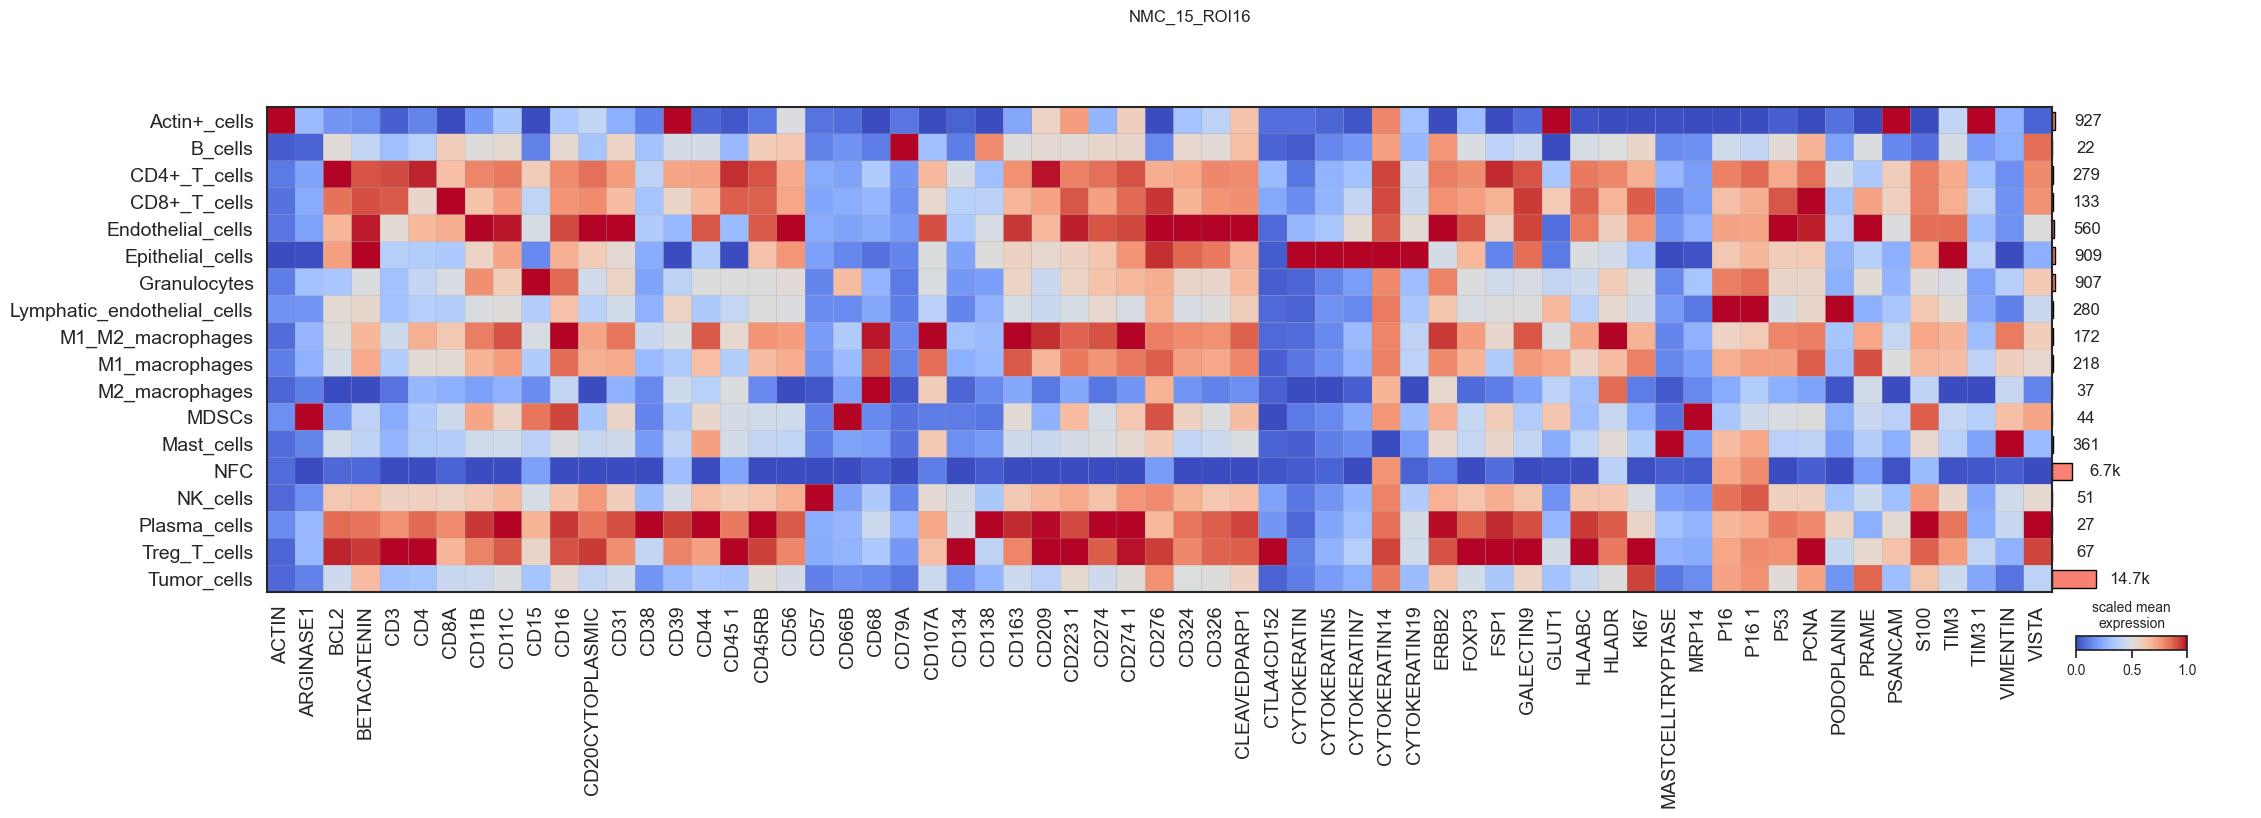

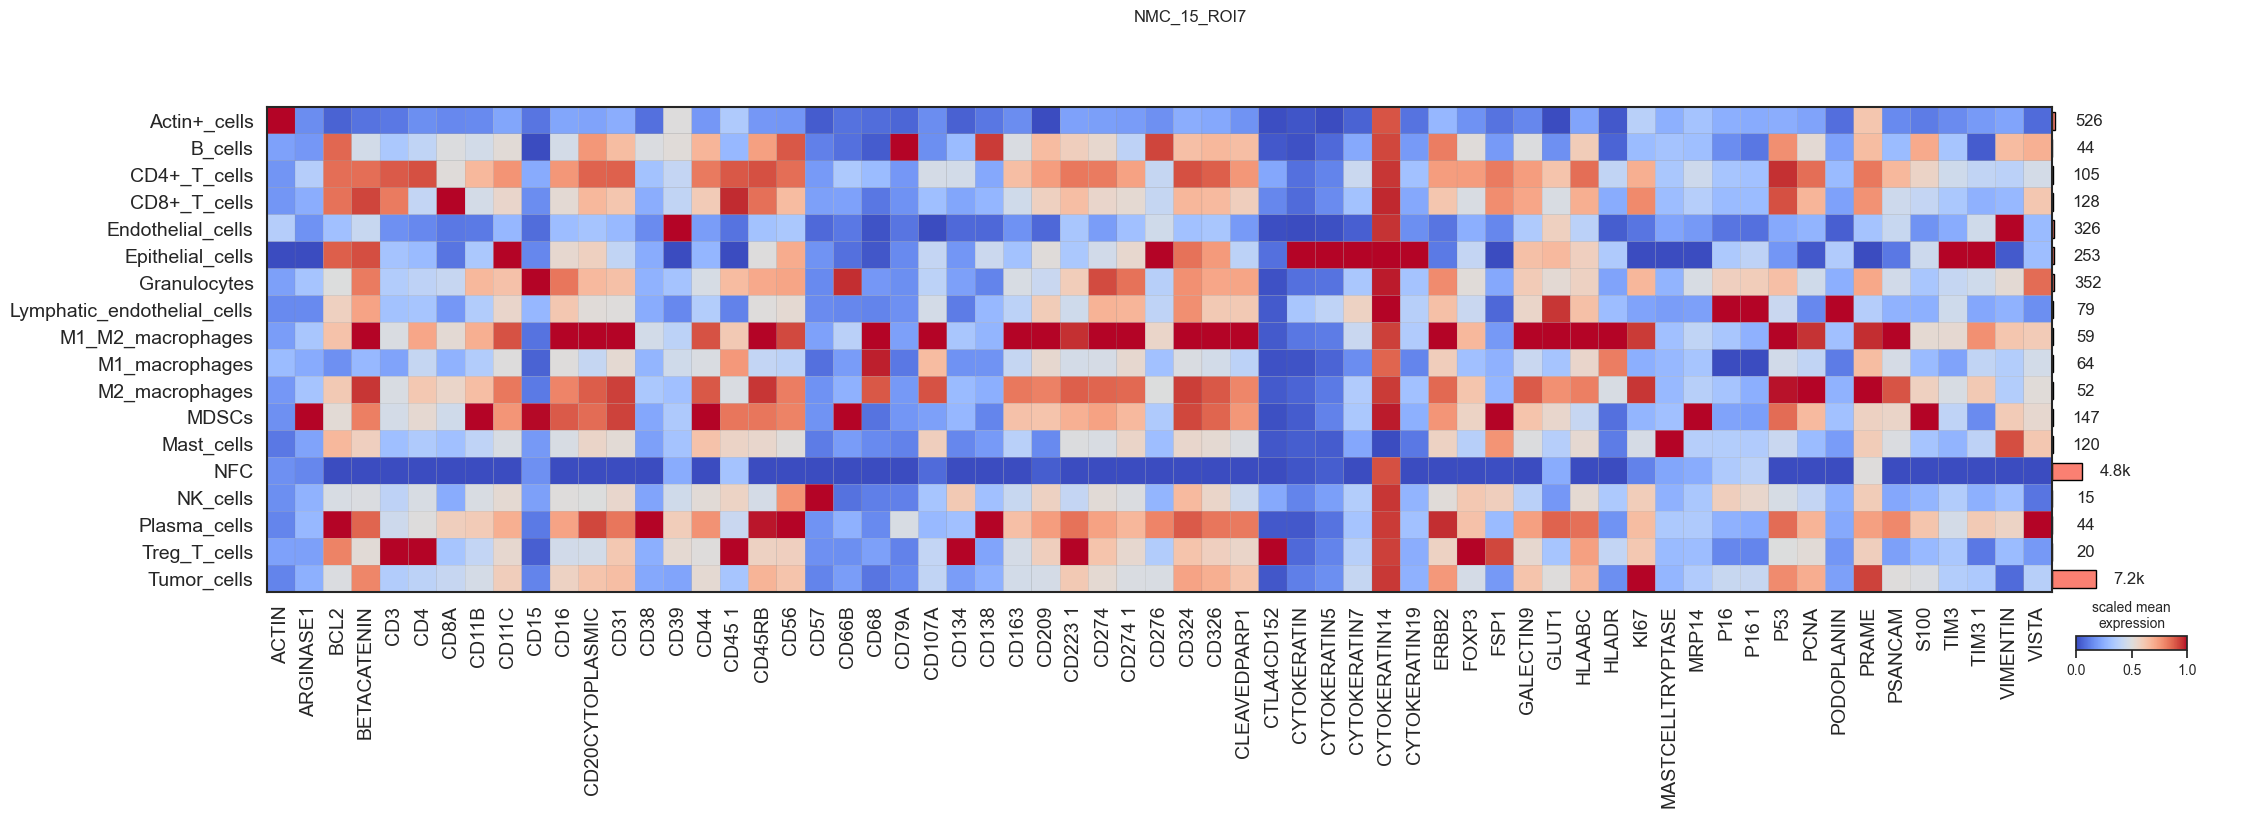

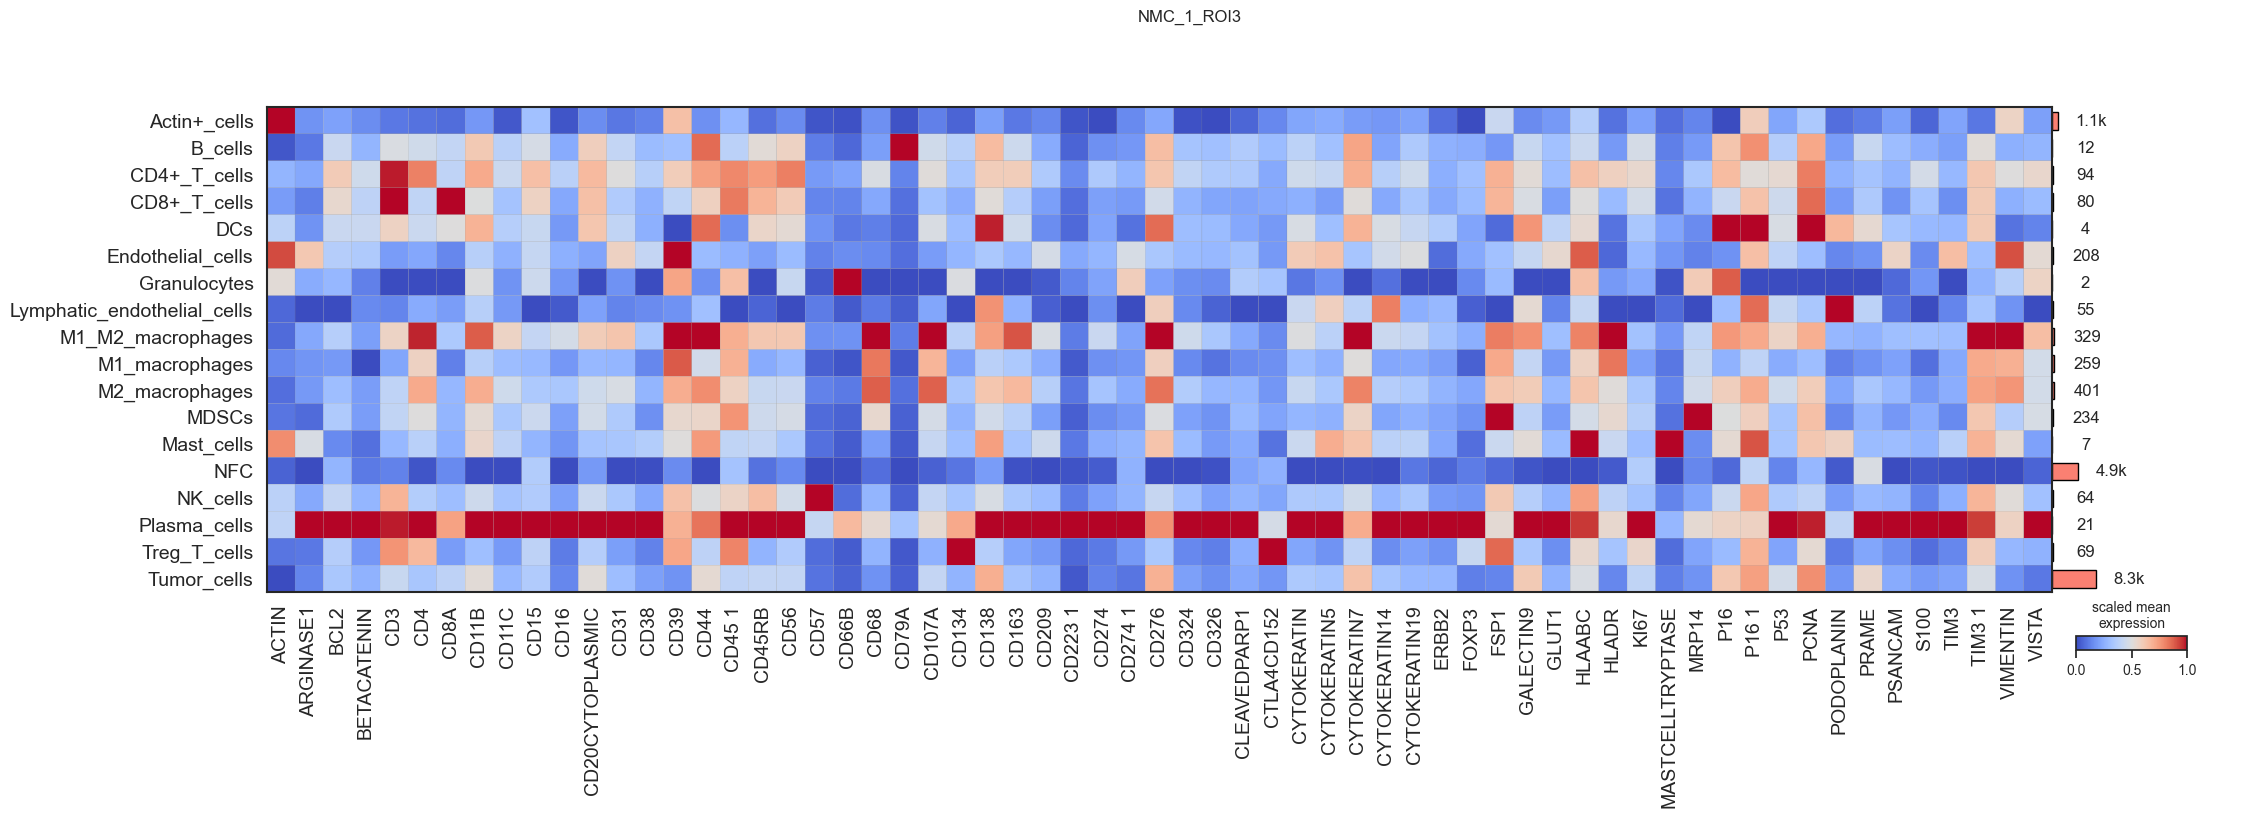

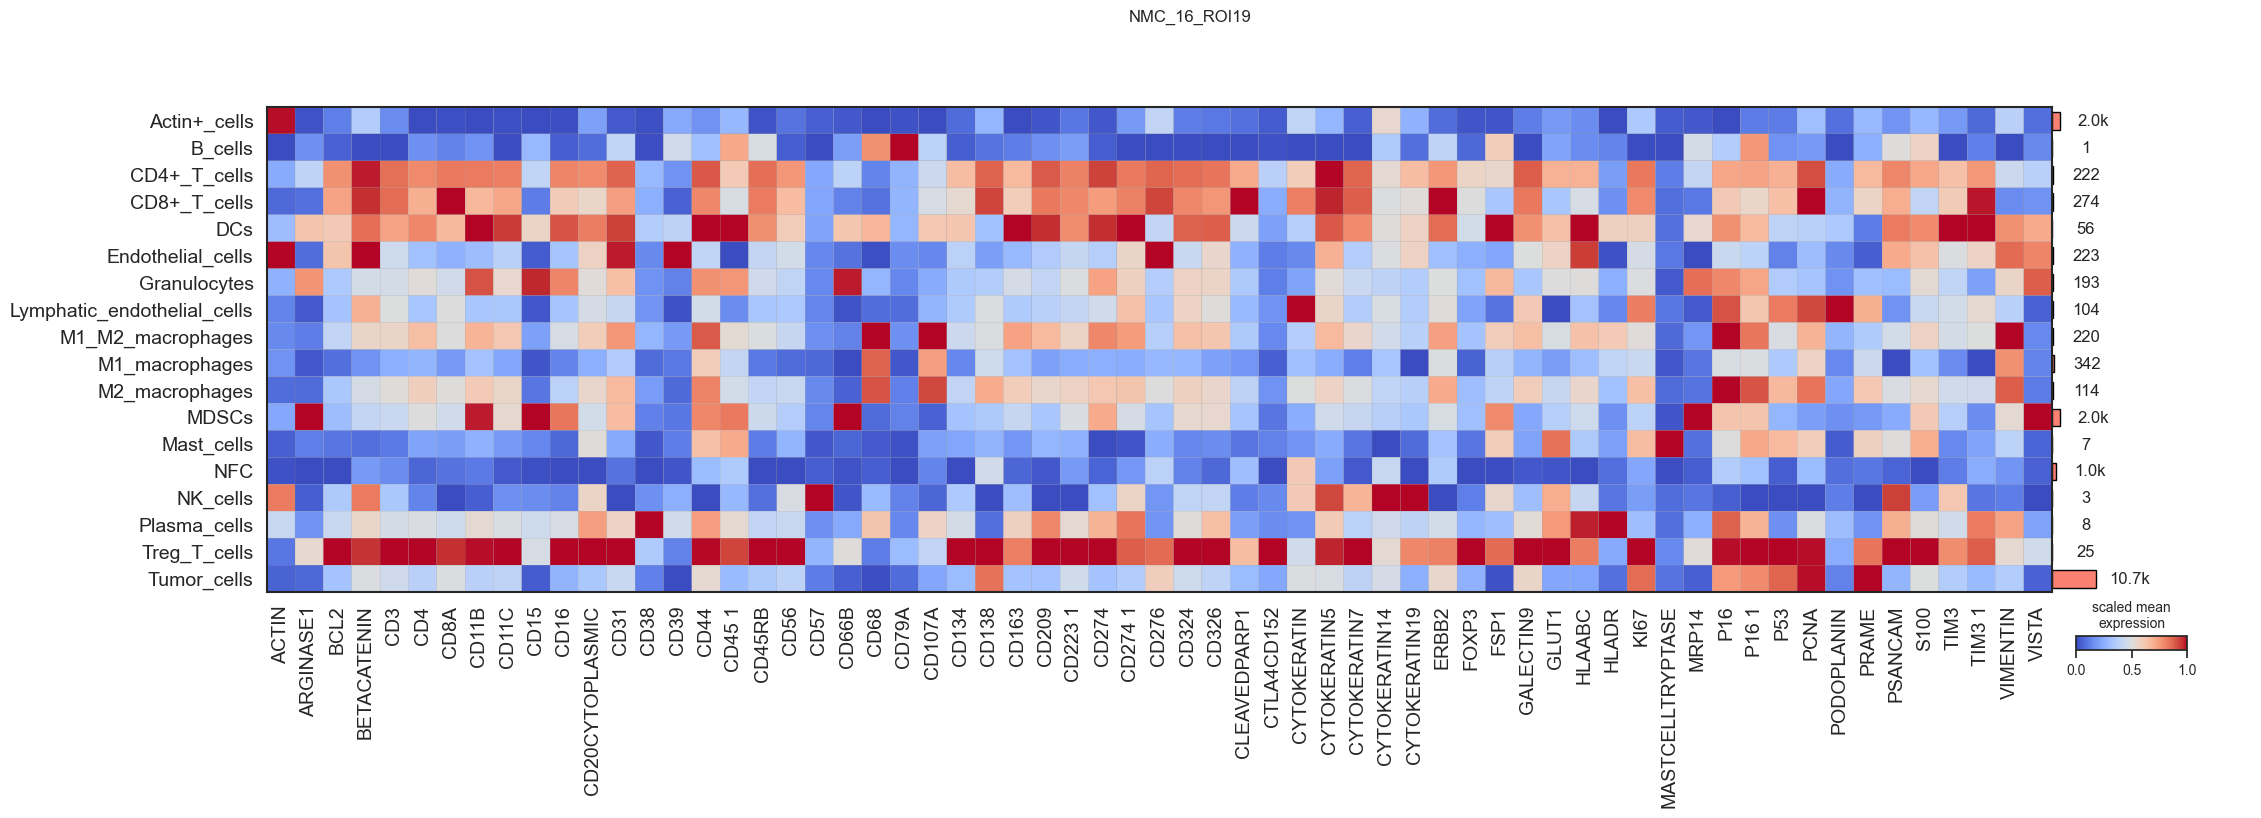

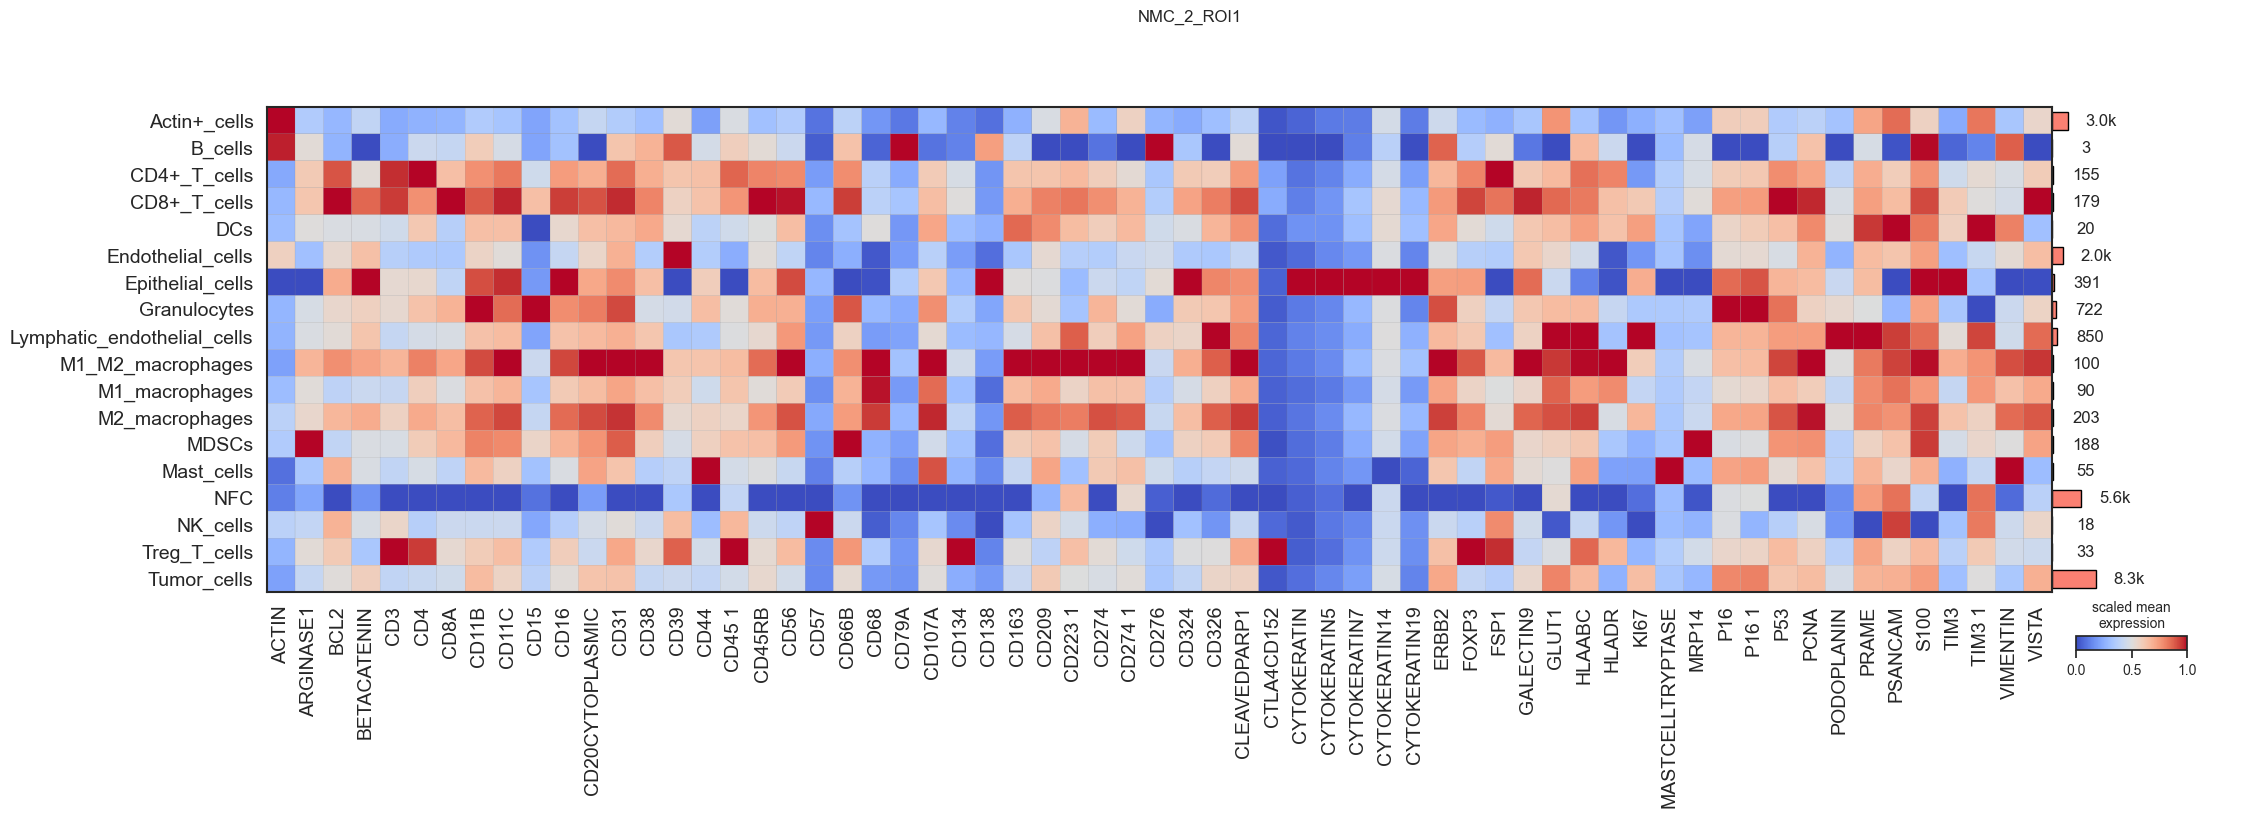

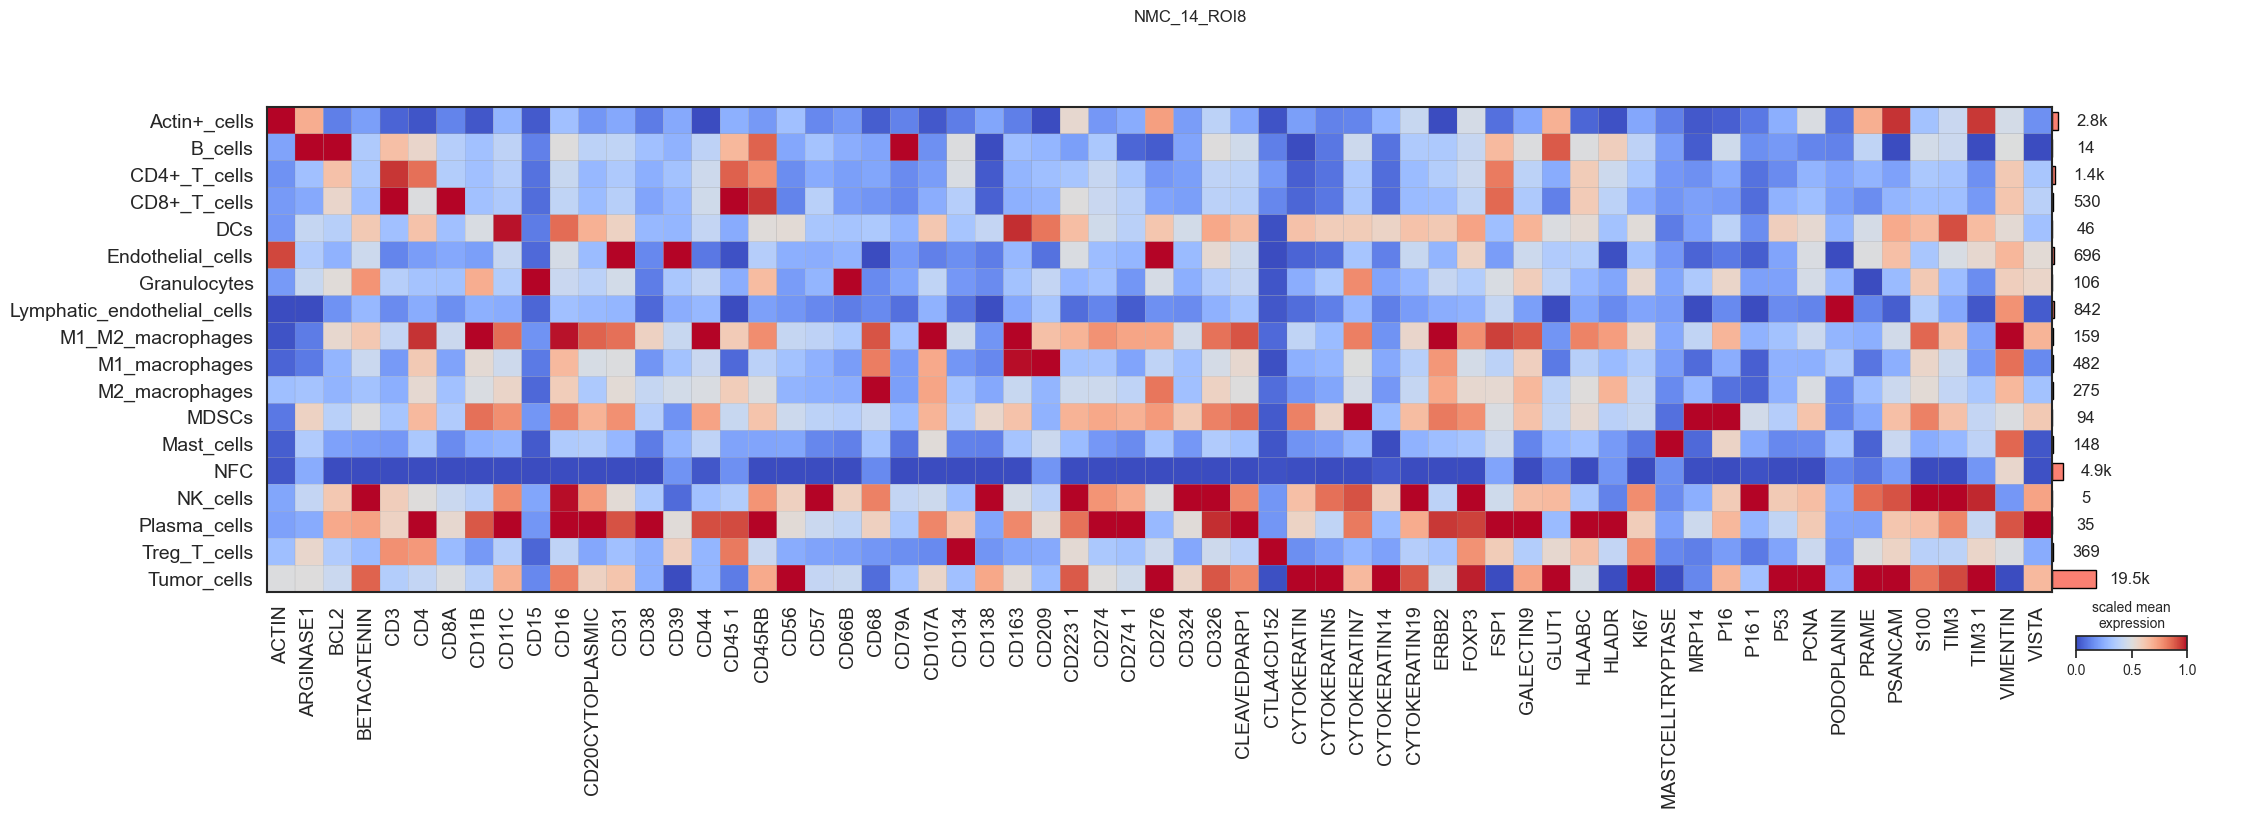

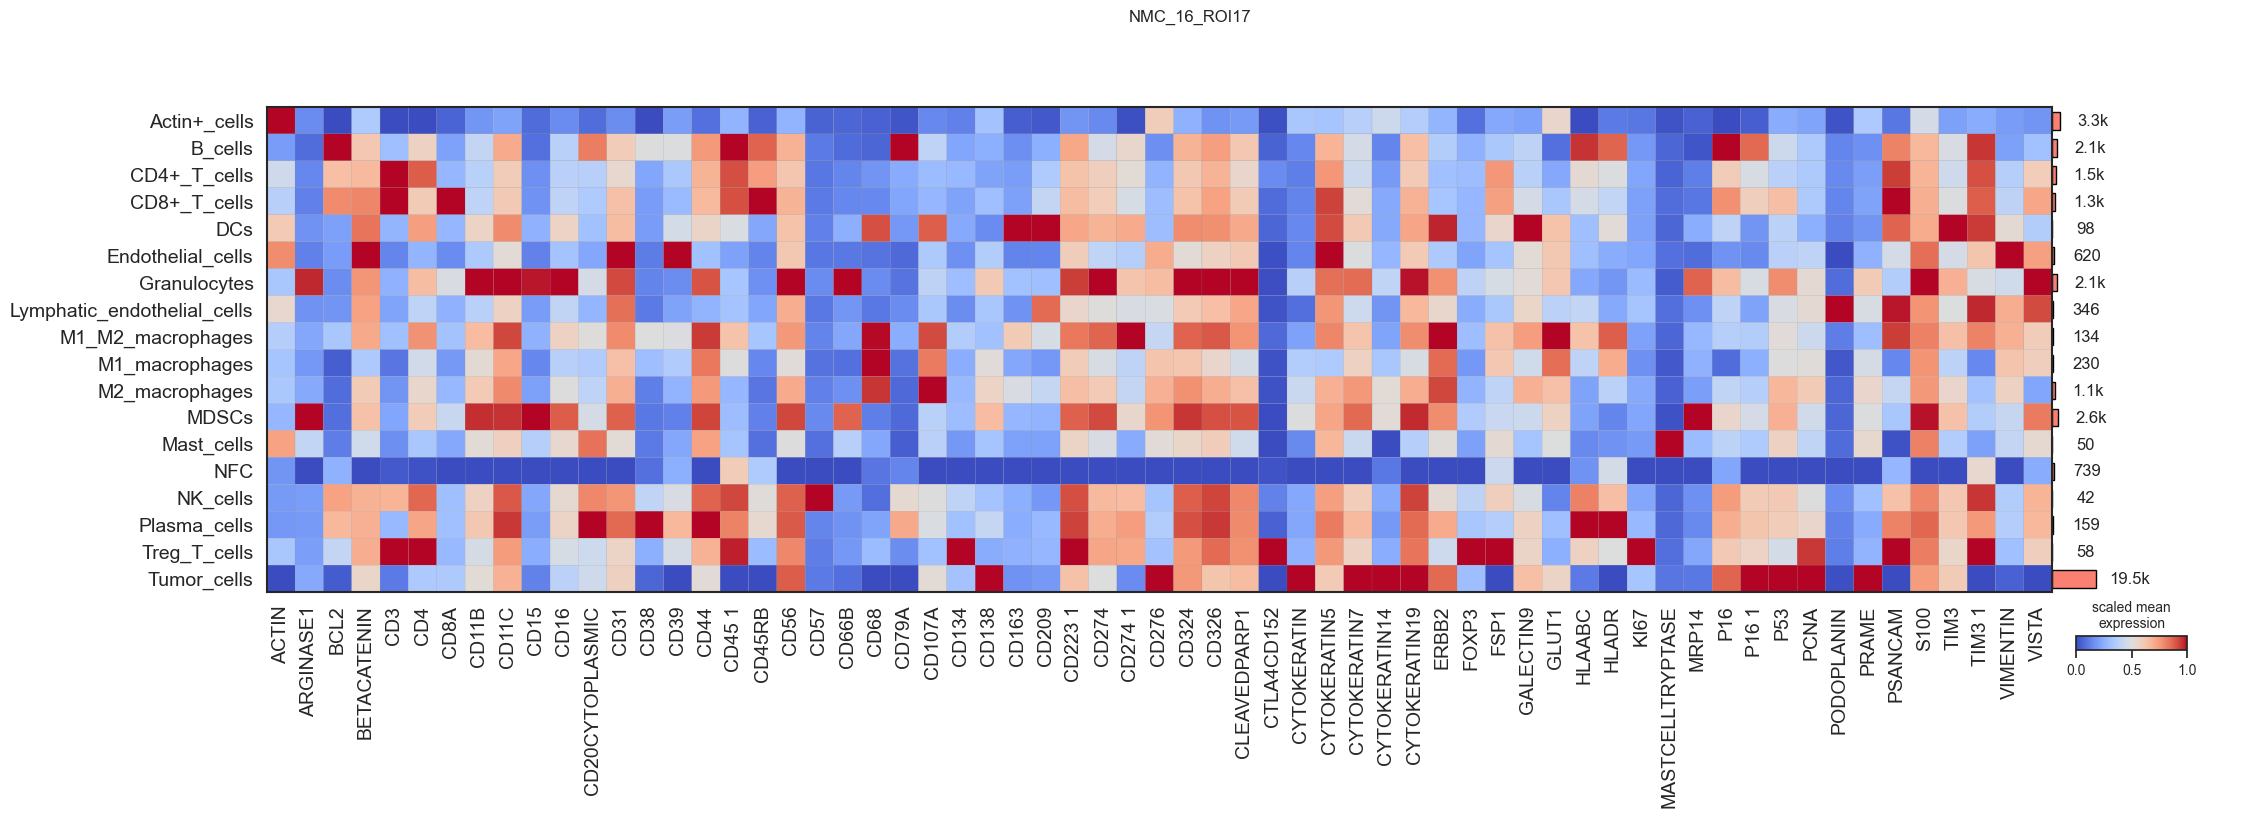

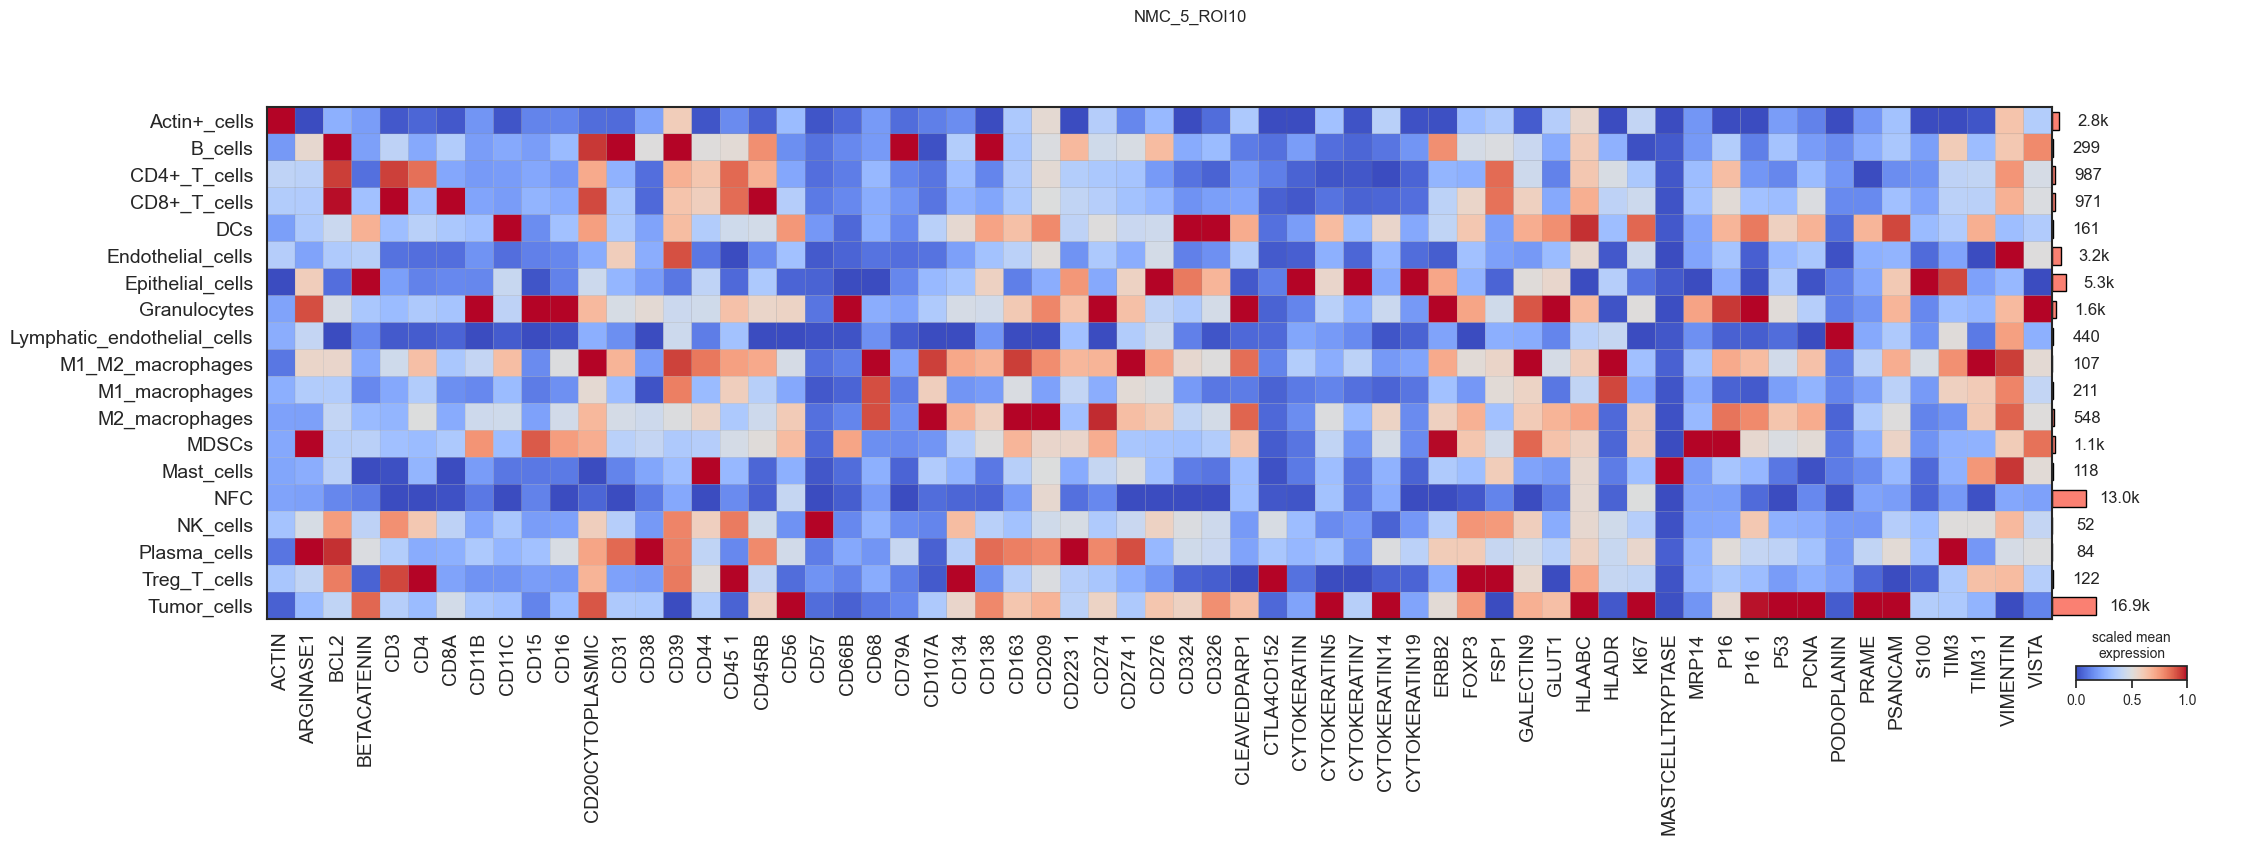

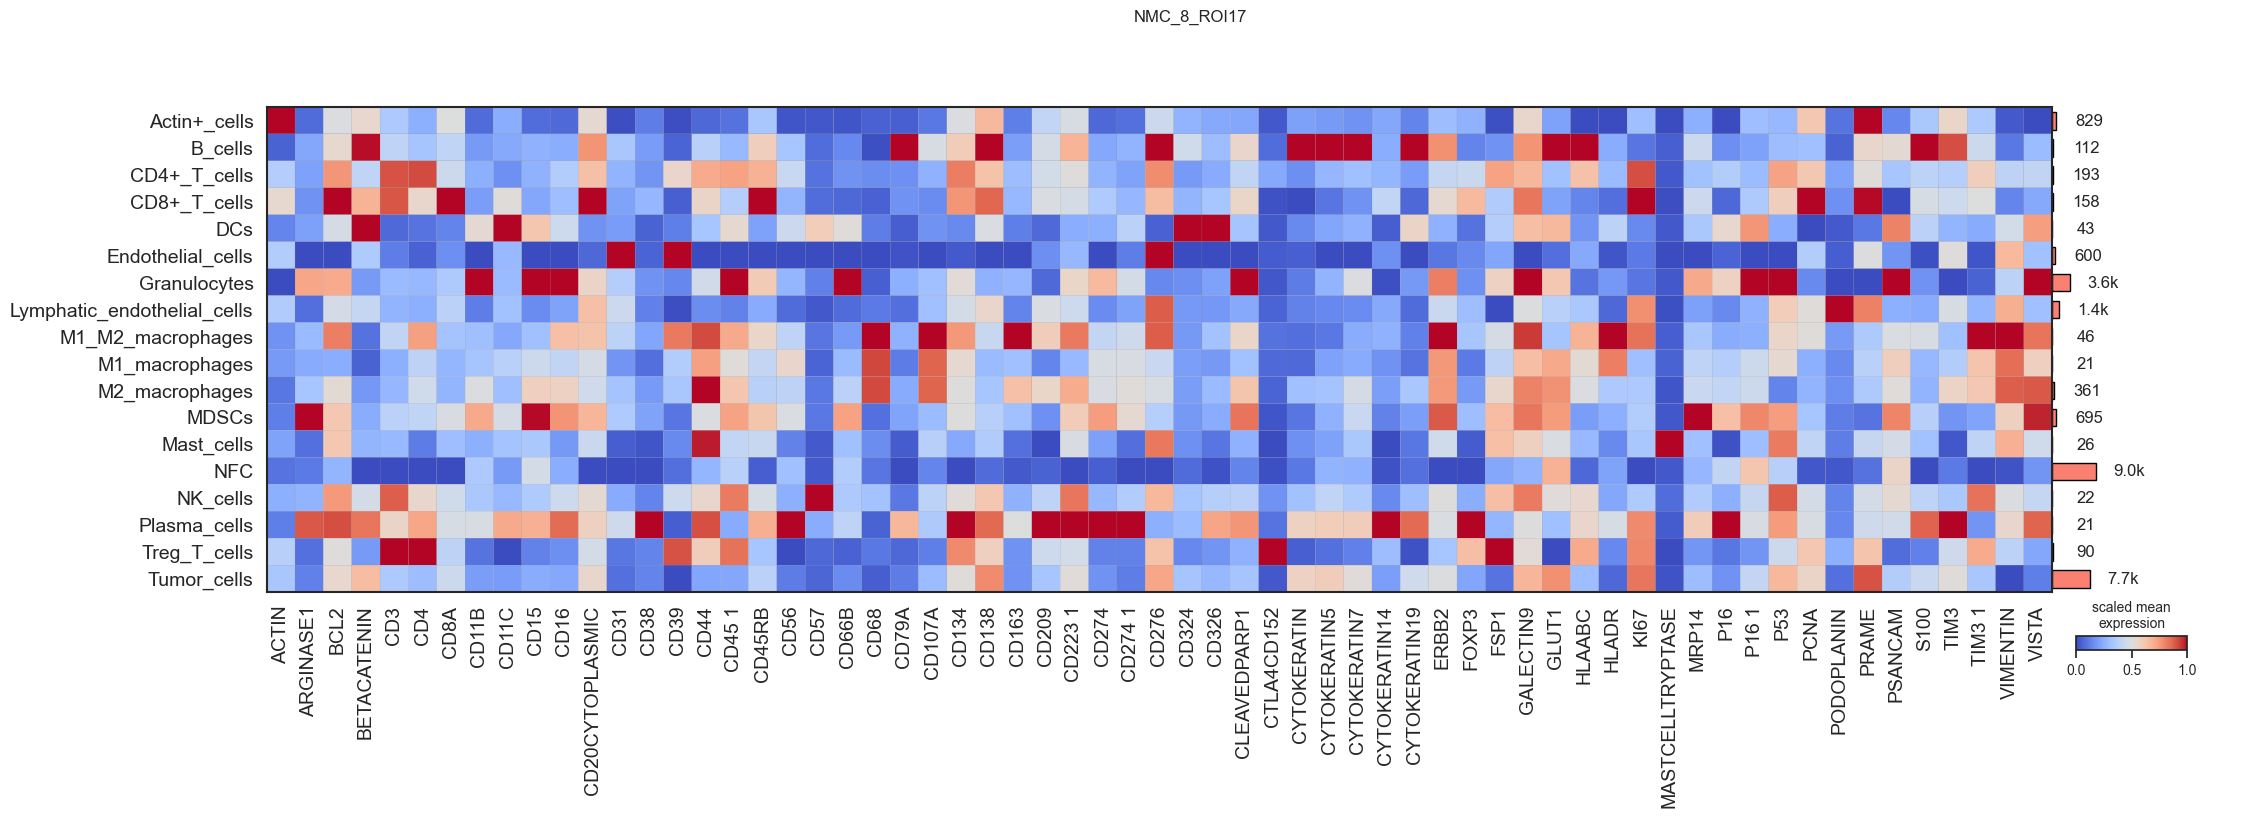

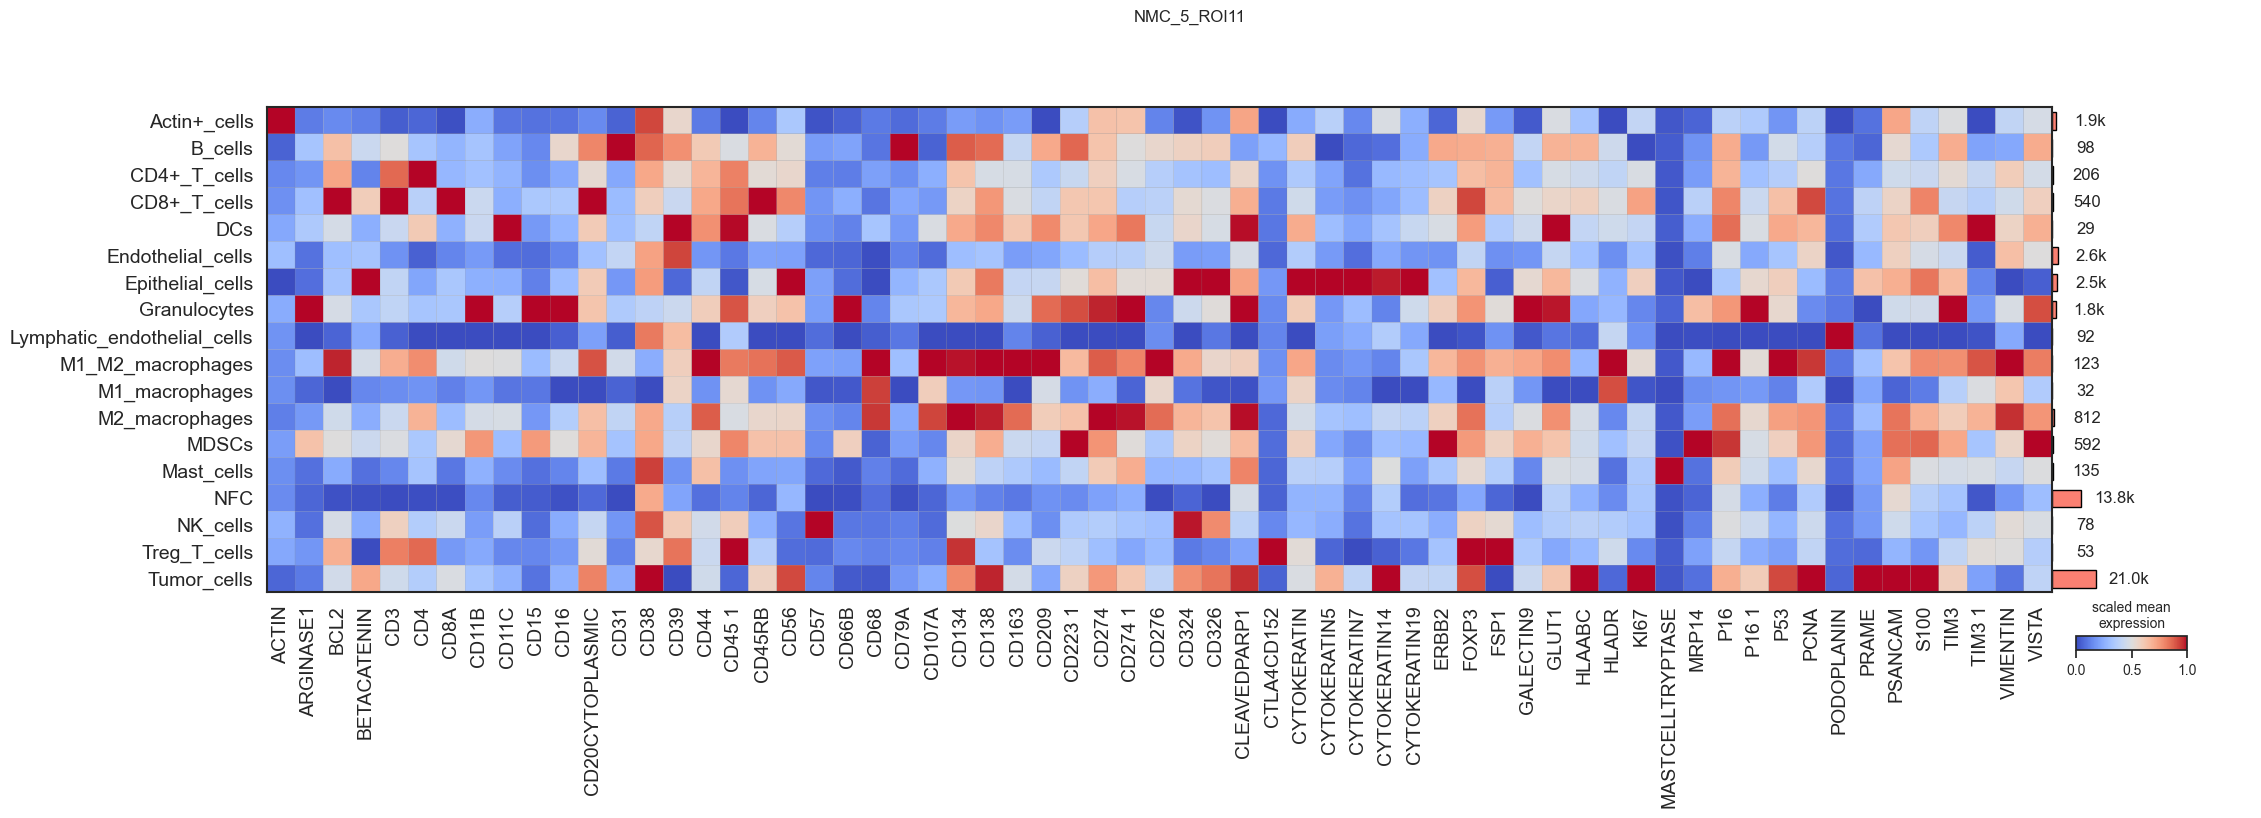

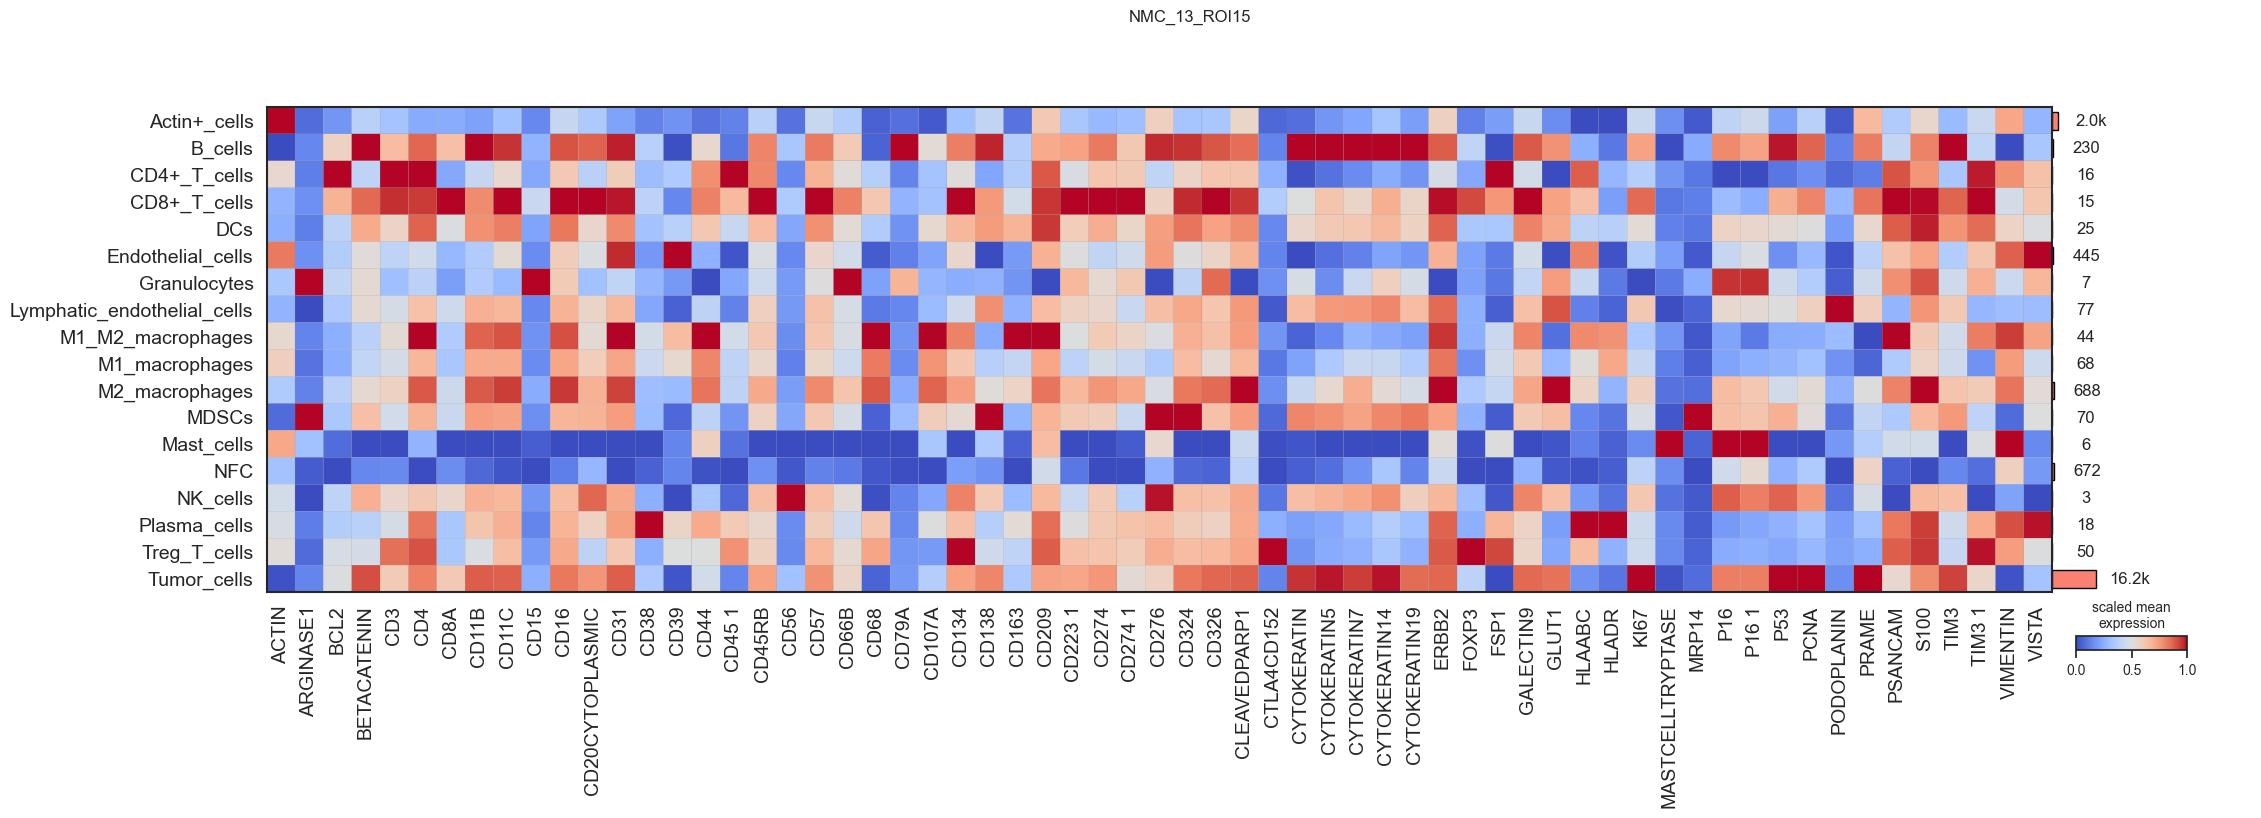

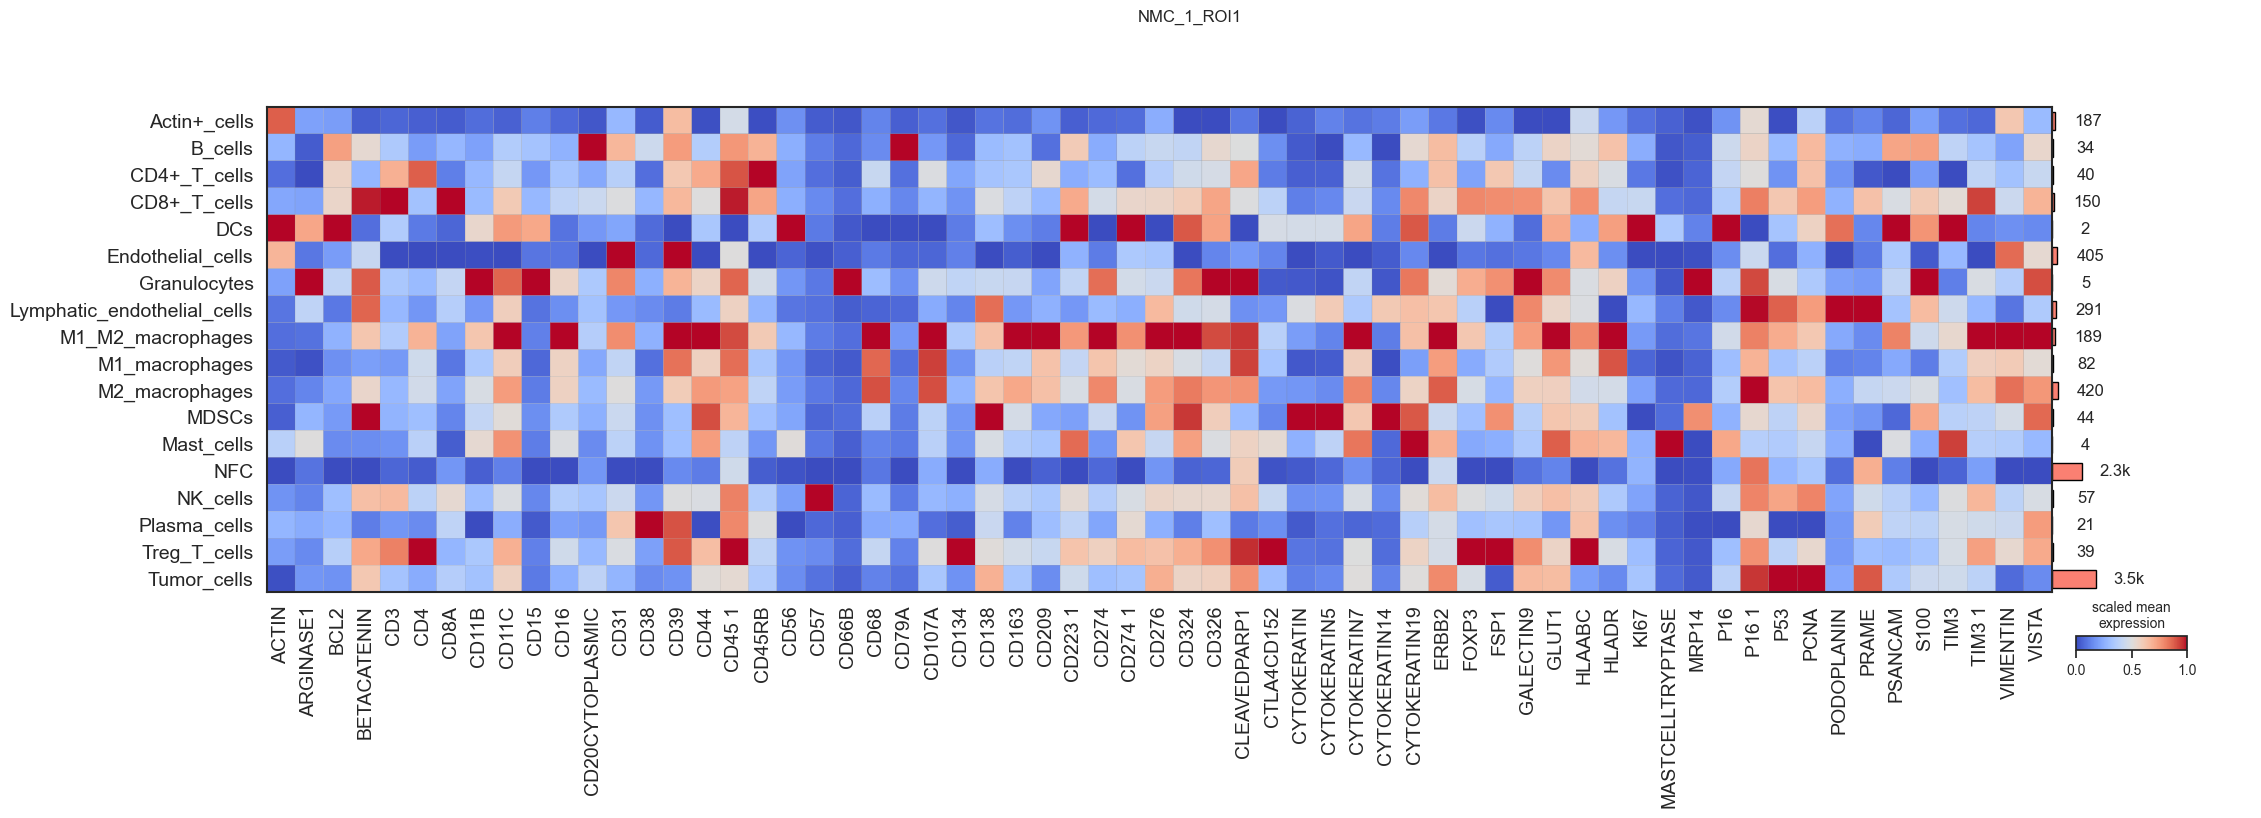

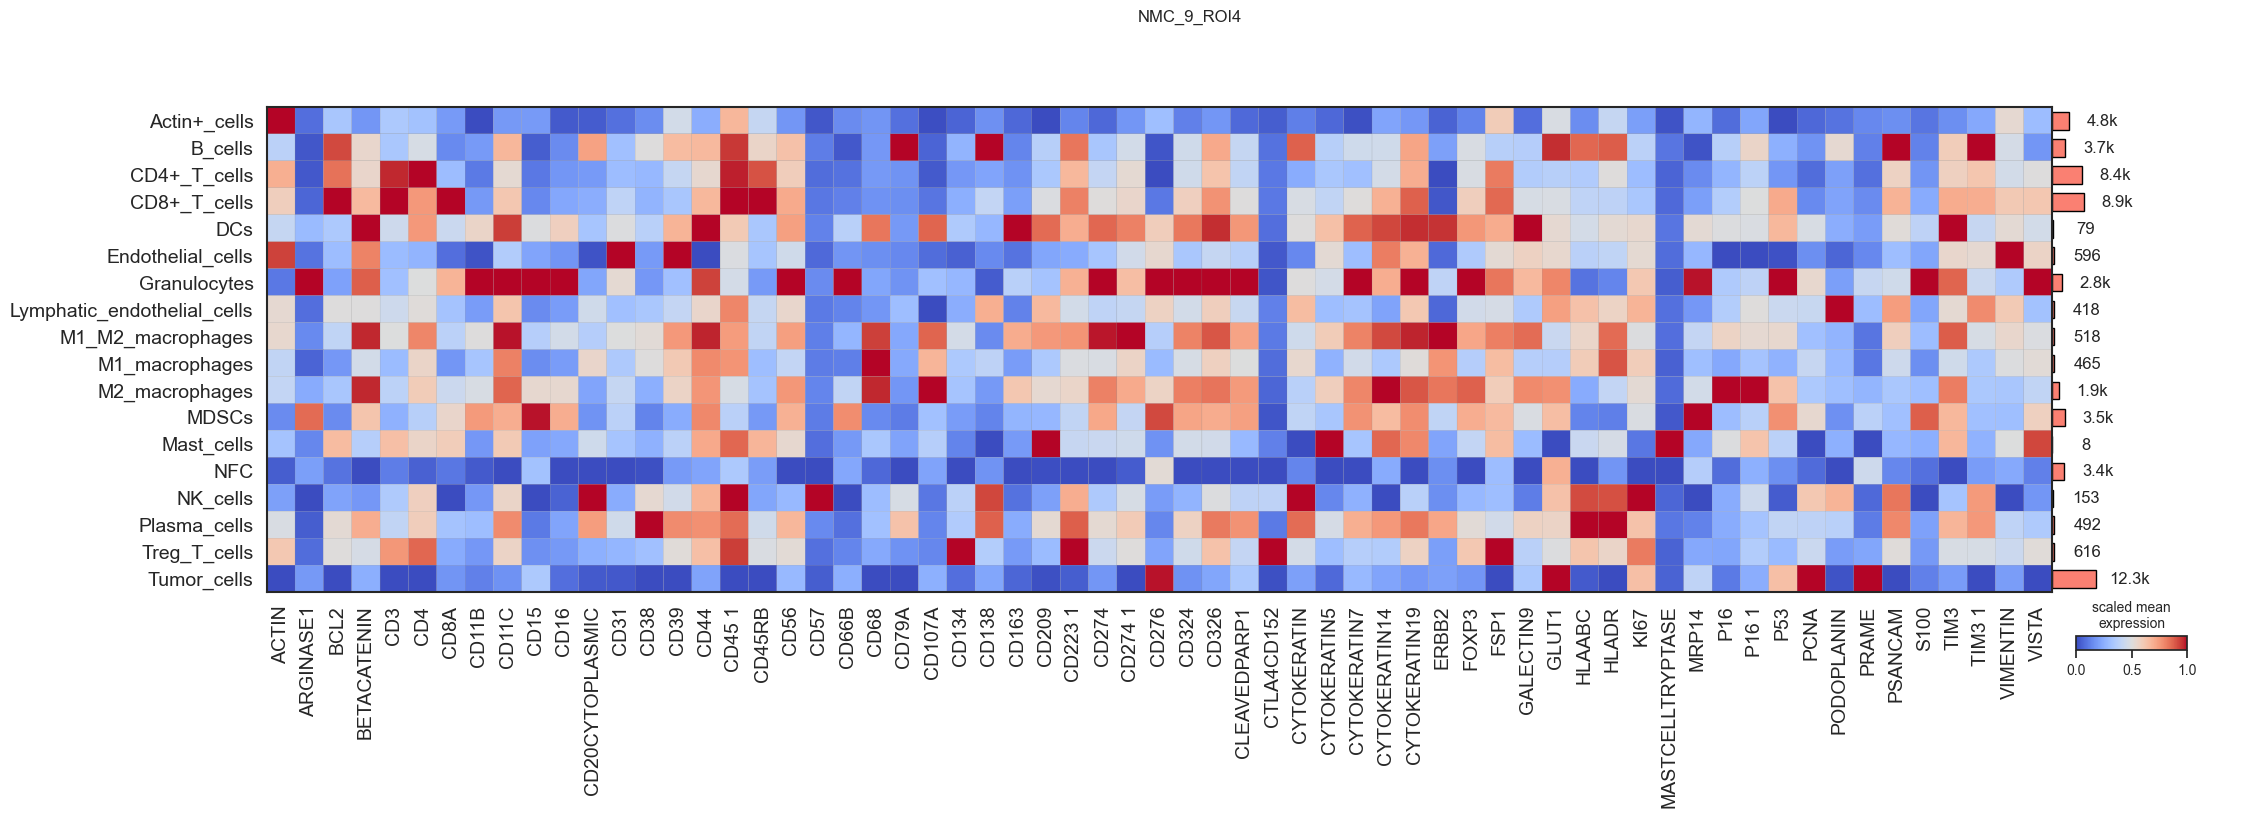

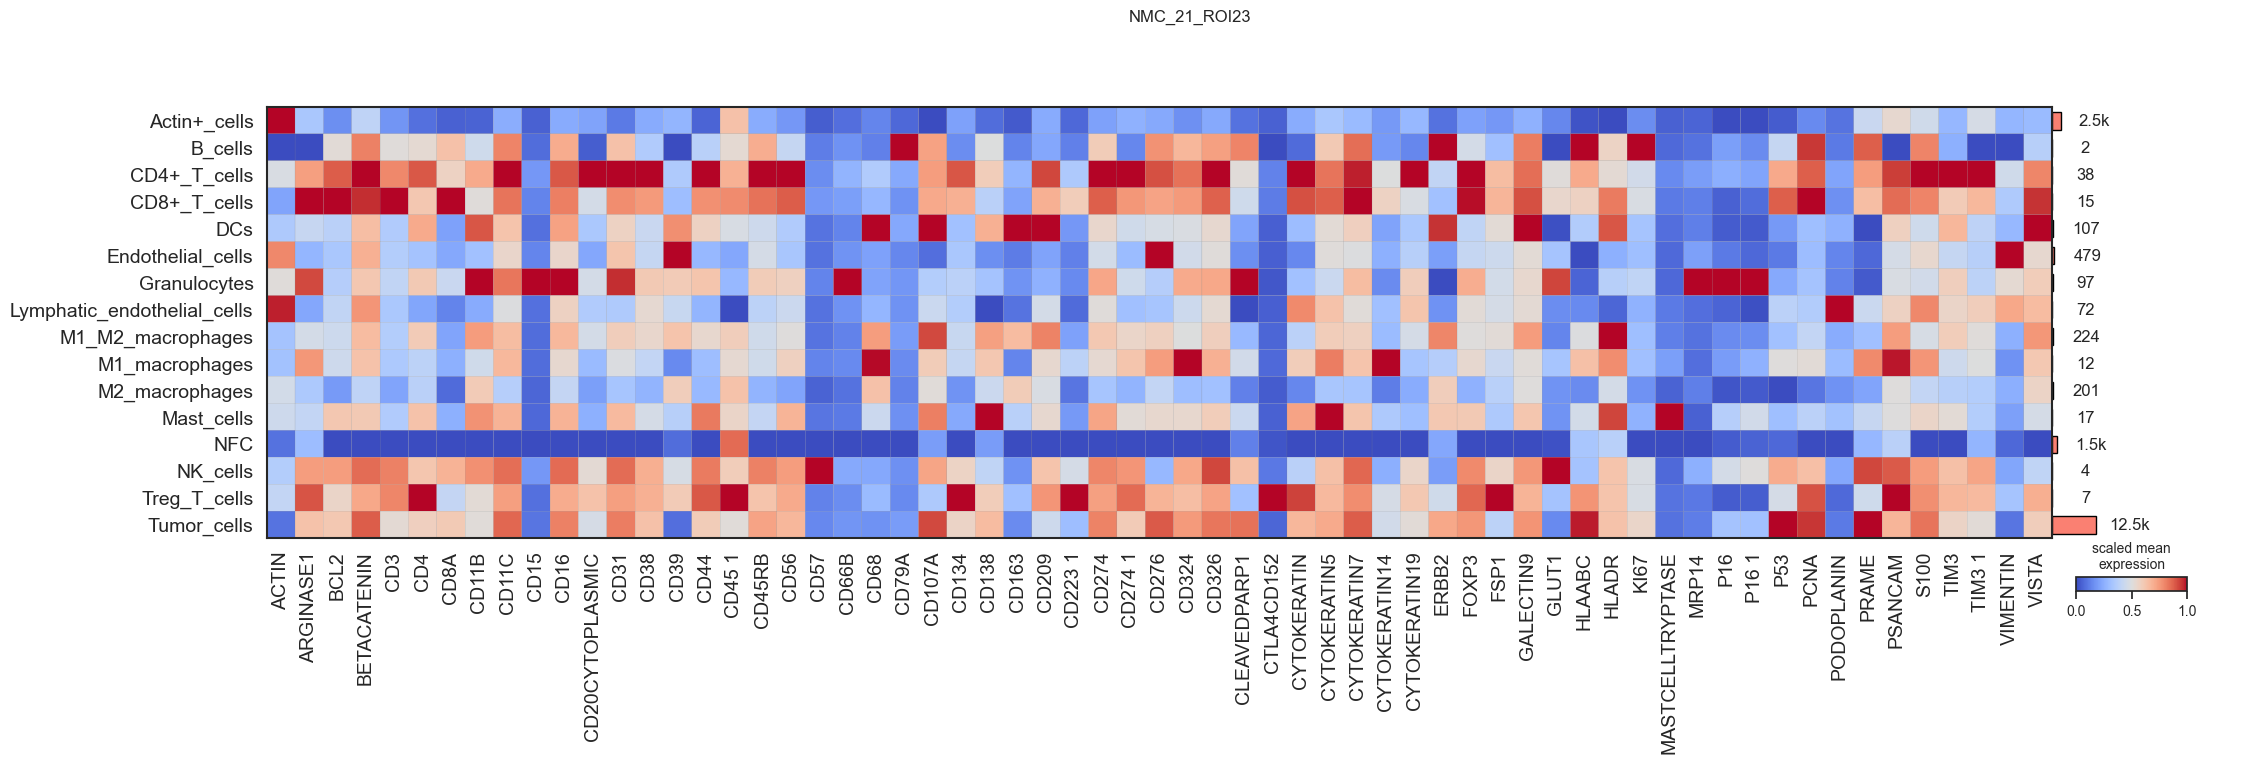

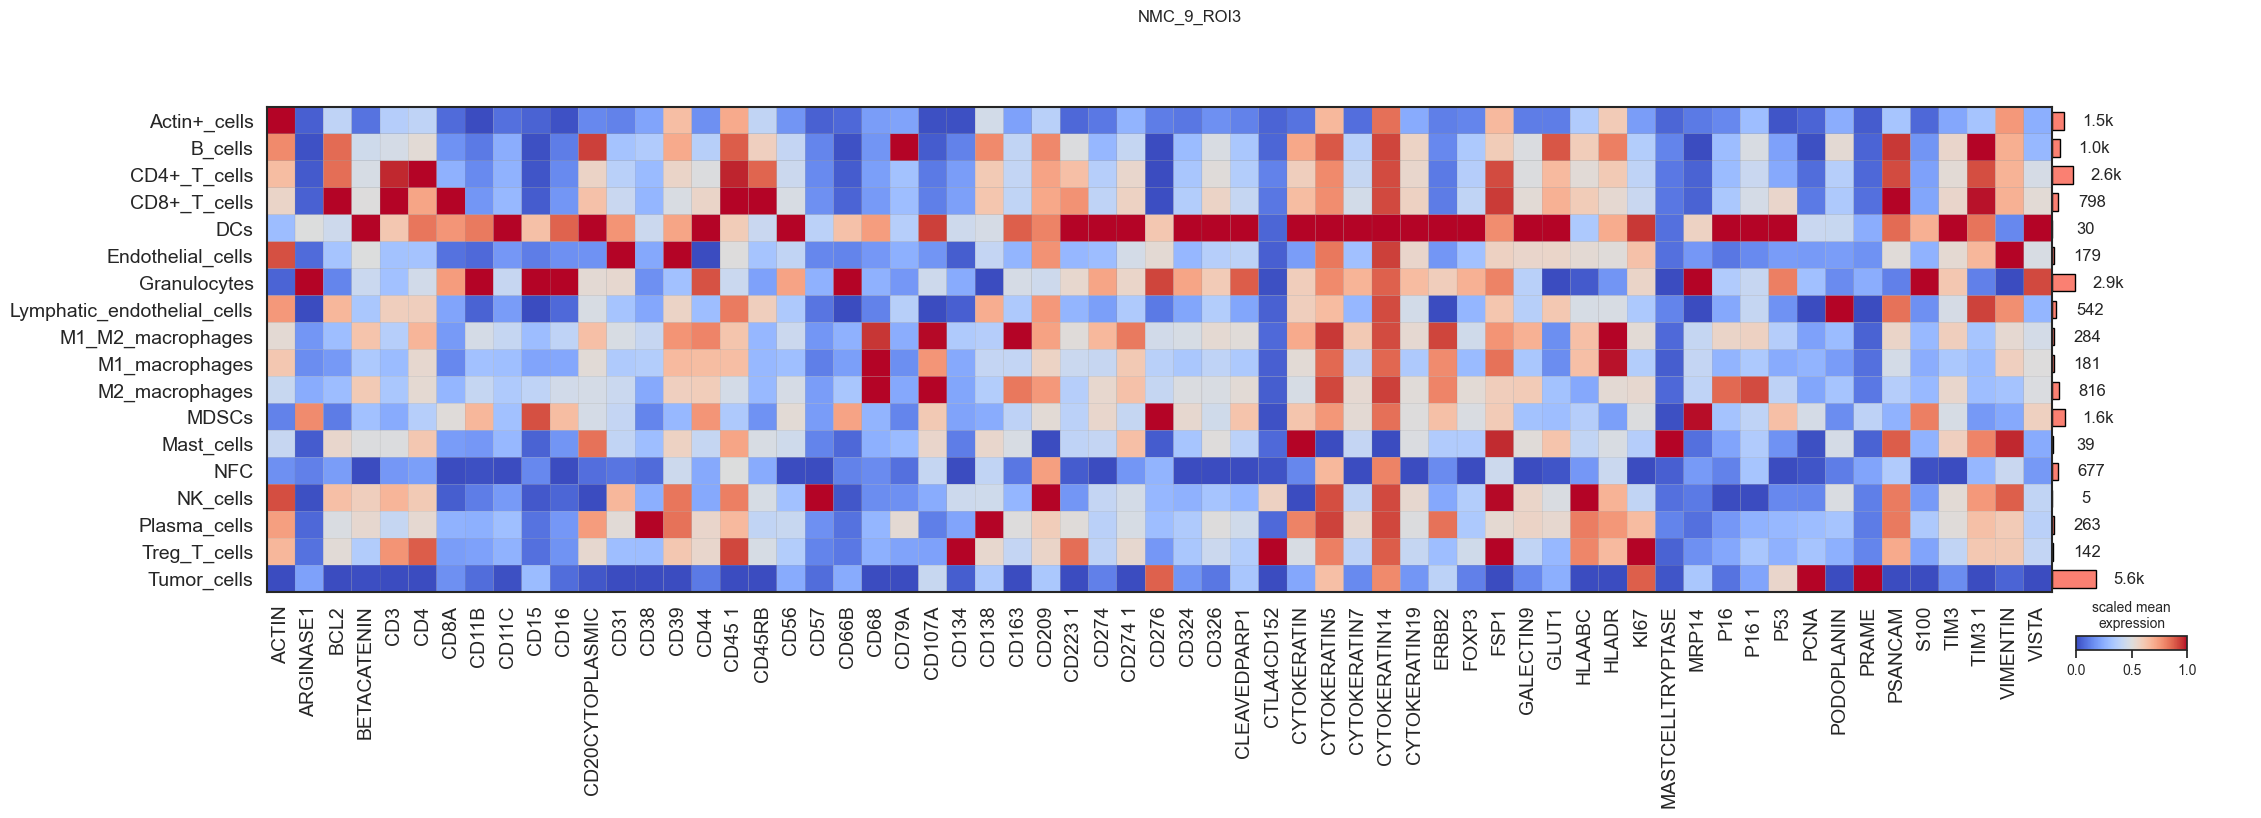

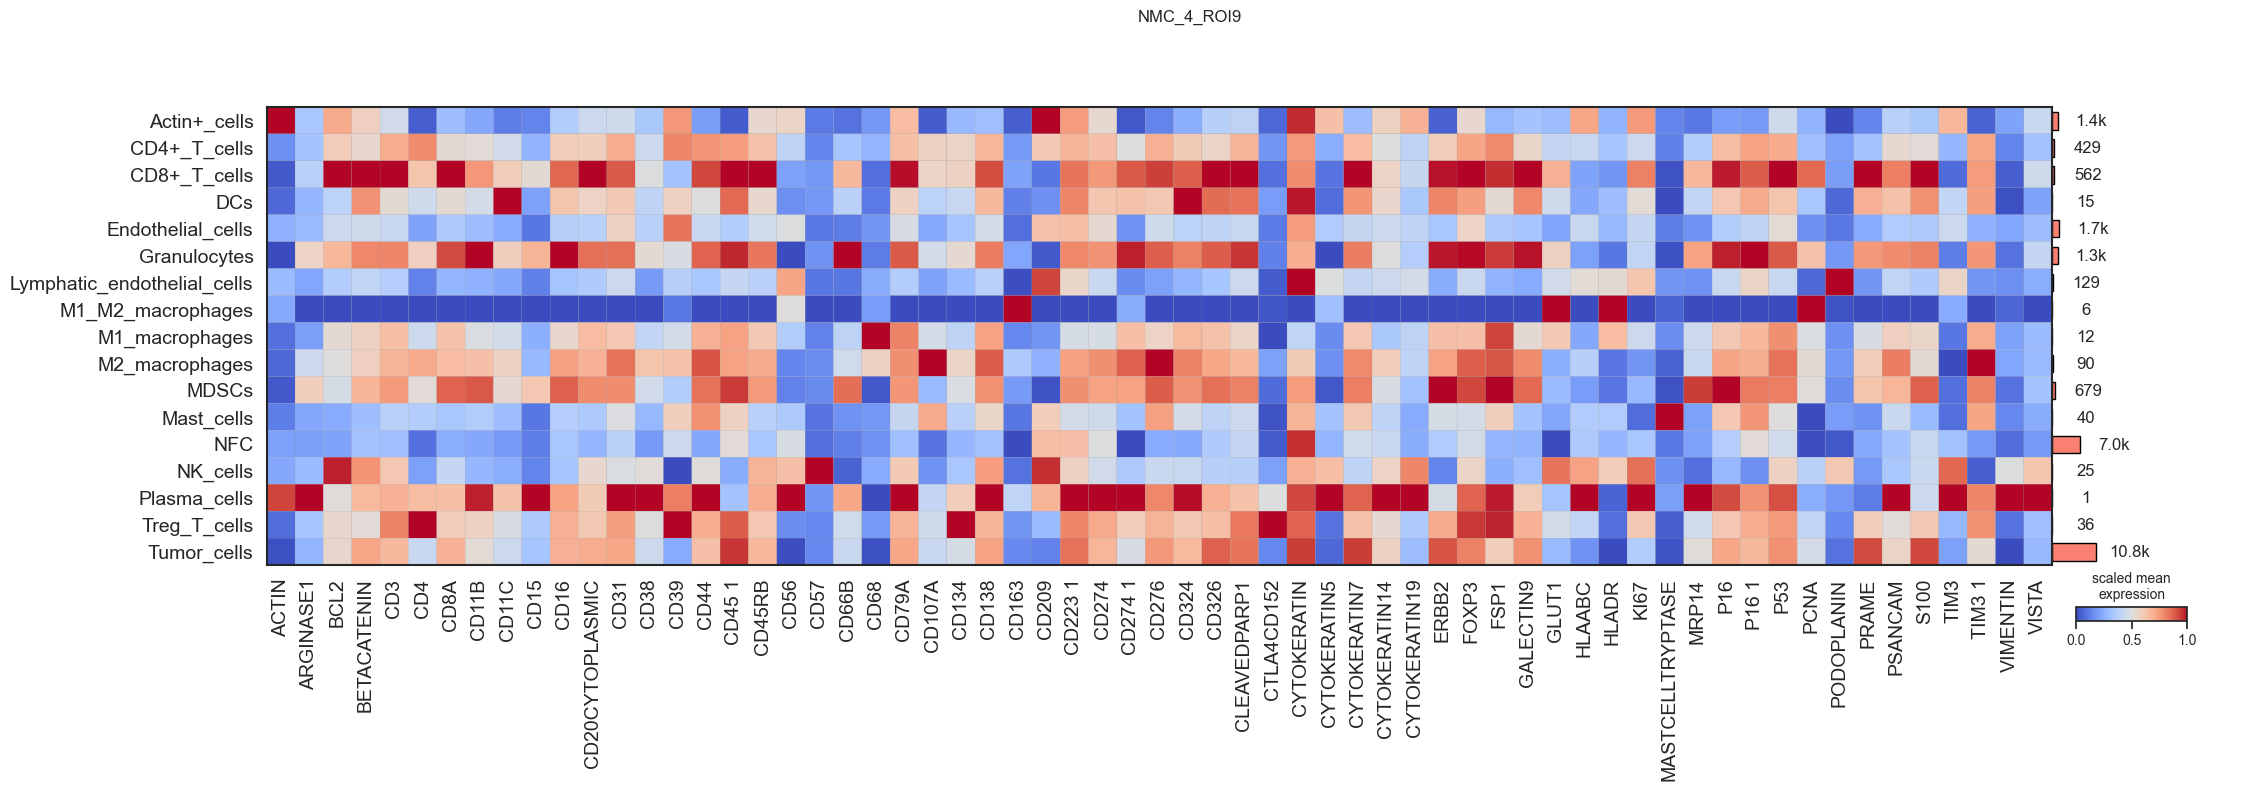

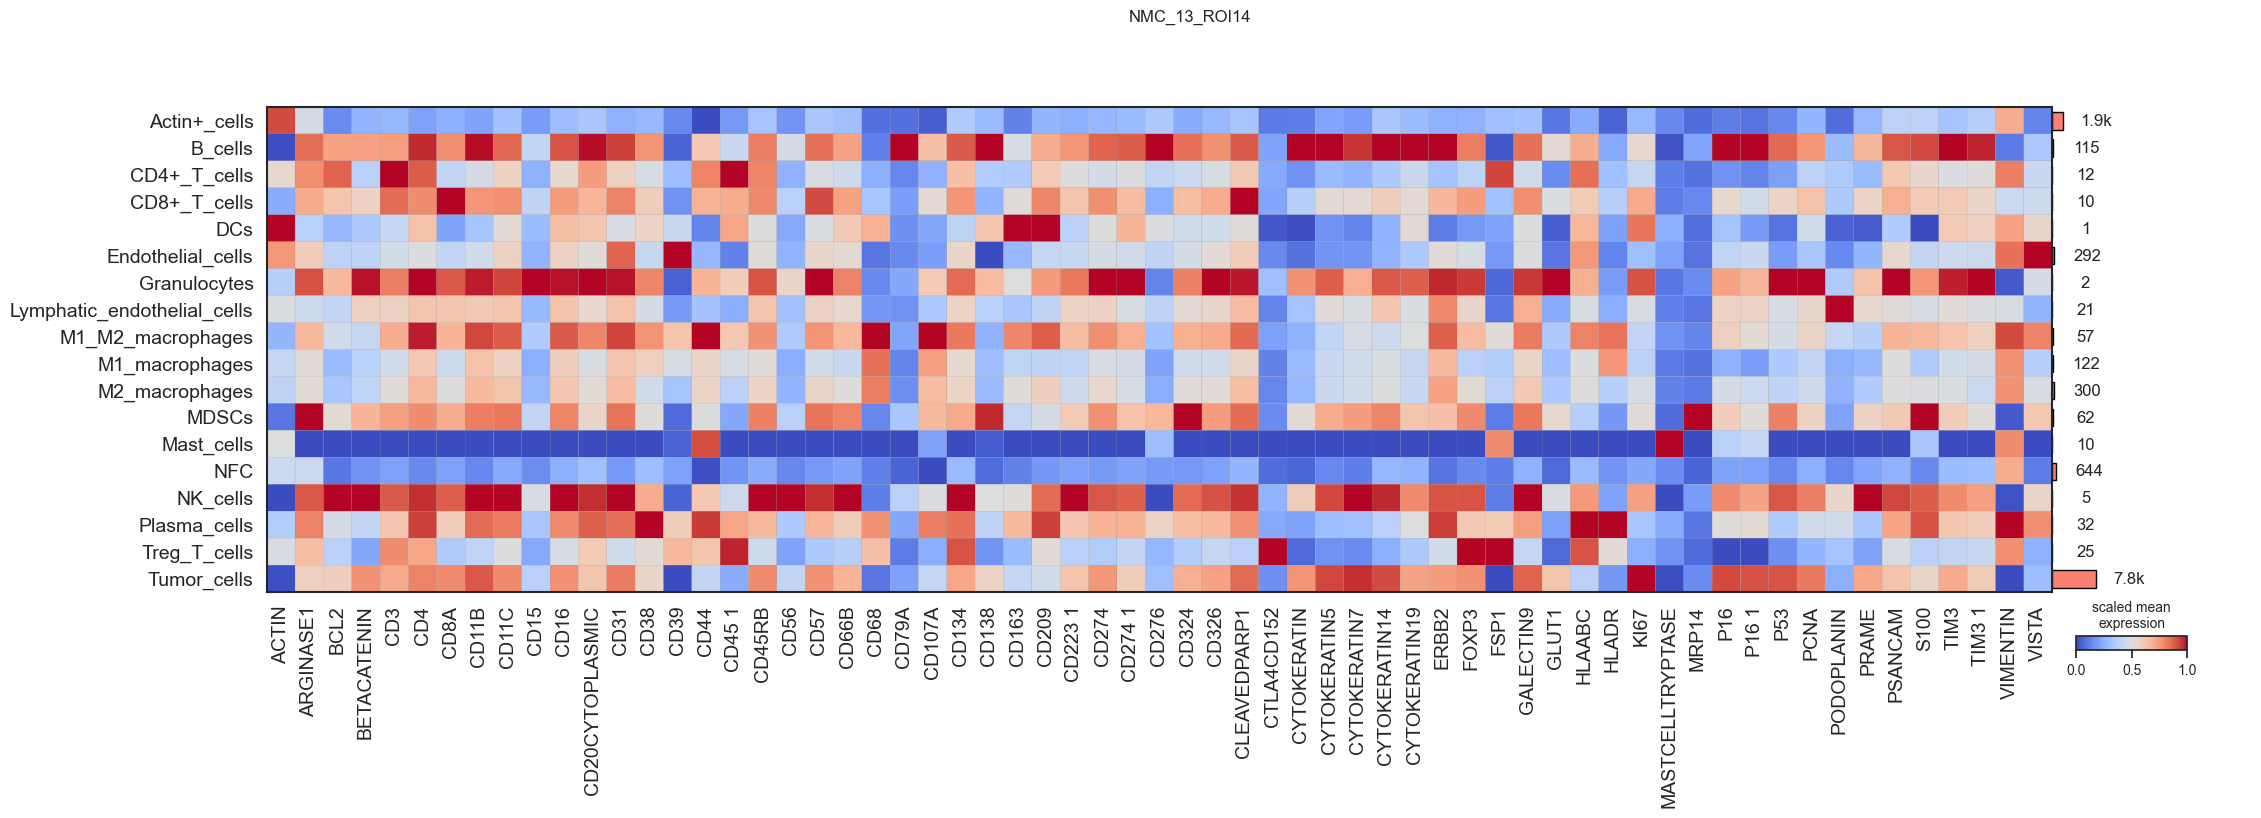

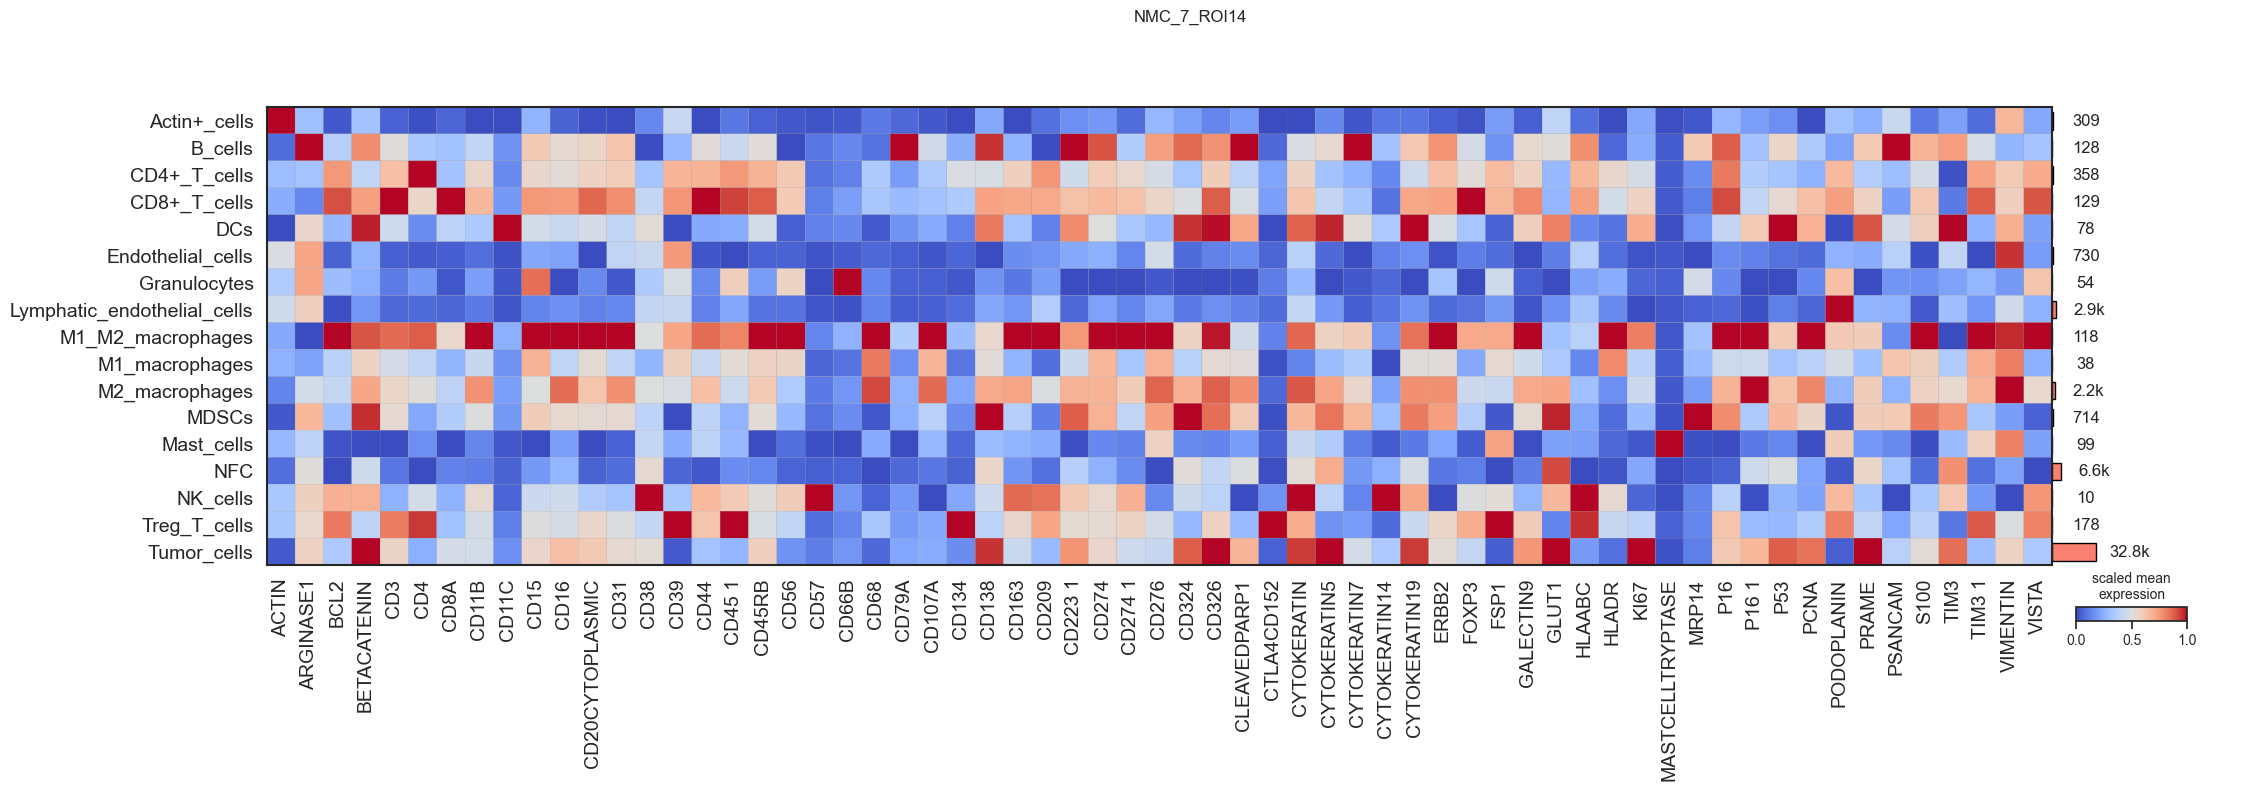

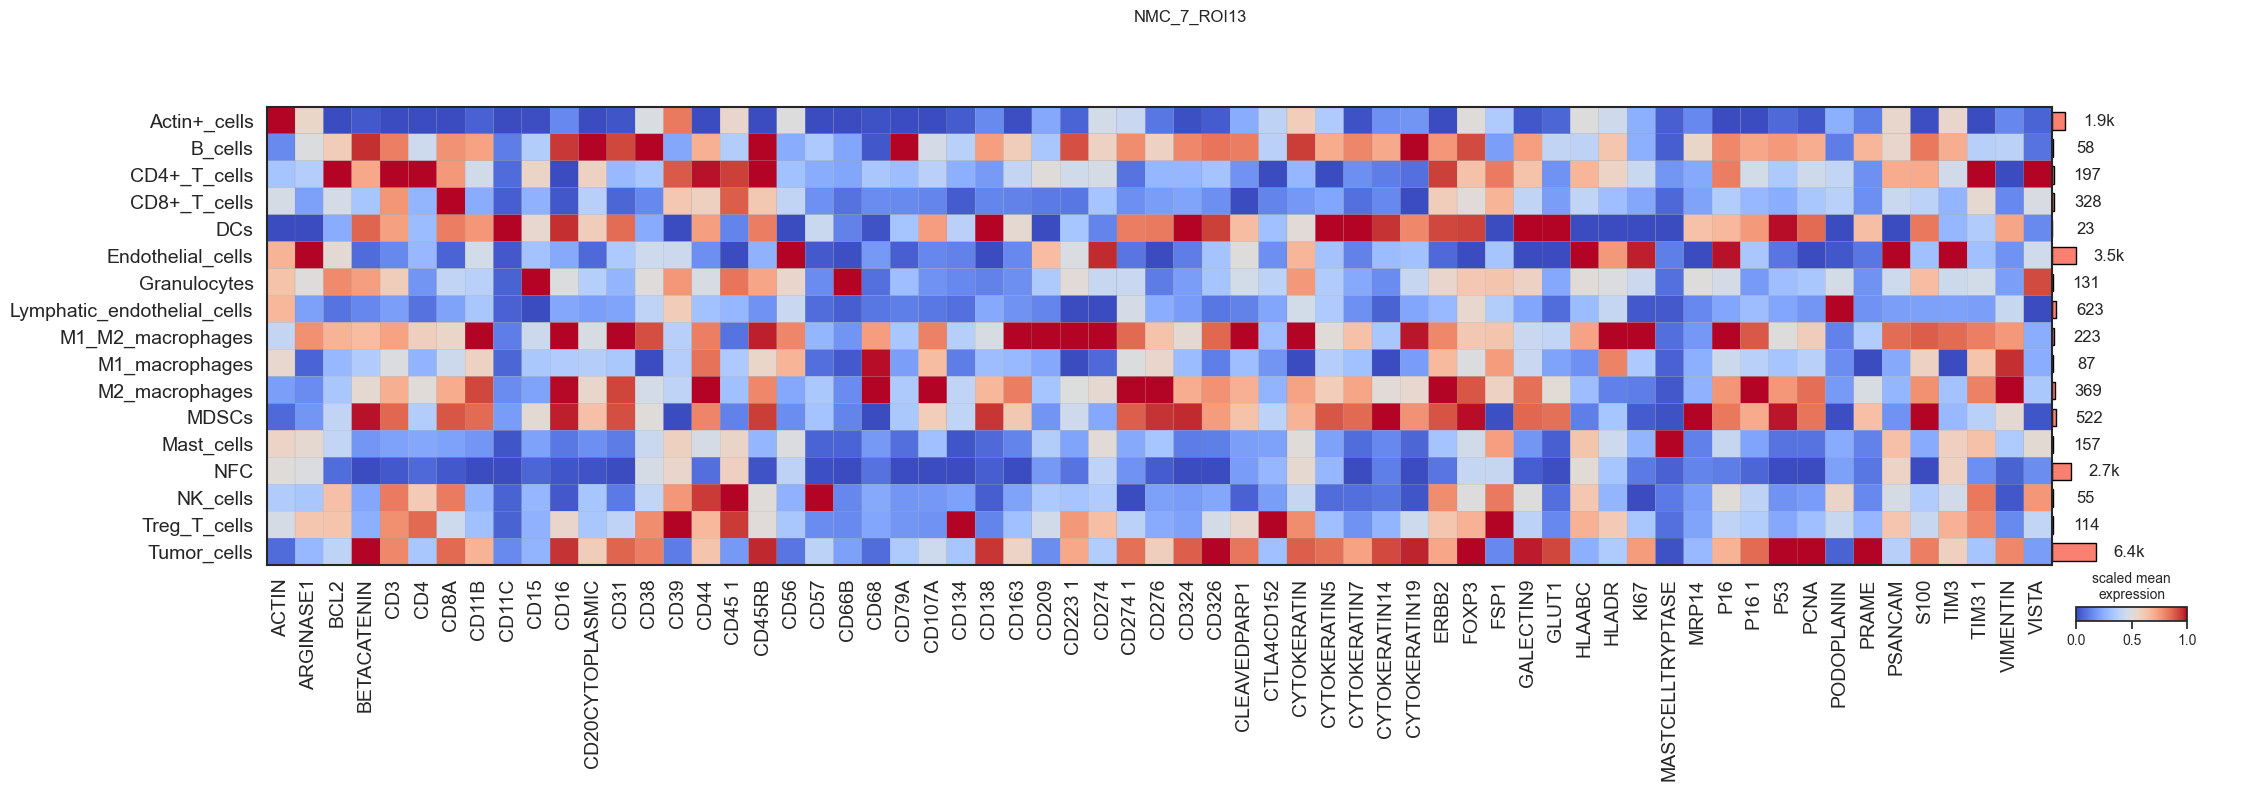

In [47]:
for patient_exp in adata_unified.obs.patient_exp.unique():
    adata_select = adata_unified[adata_unified.obs['patient_exp'] == patient_exp]
    fig = sc.pl.matrixplot(
         adata_select, 
         var_names=adata_select.var_names, 
         groupby='cell_type', 
         cmap="coolwarm",
         standard_scale="var",
         use_raw=False,
         show=False,
         return_fig=True,
         title=patient_exp
         )
    
    fig.add_totals()
    axes = fig.get_axes()
    ax = axes['mainplot_ax']
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
    group_ax = axes['group_extra_ax']
    for text in group_ax.texts:
     text.set_fontsize(12)
     current_pos = text.get_position()
     text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
    cax = axes['color_legend_ax']
    cax.set_title('scaled mean\nexpression', fontsize=10)
    cax_current_pos = cax.get_position()
    cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
    fig = axes['mainplot_ax'].figure
    fig.tight_layout()
    plt.tight_layout()

In [131]:
target_thresholds = pd.read_excel(metadata_dir/"tumor_gates_Run145_sophia.xlsx")
target_thresholds["patient_exp"] = "NMC_" + target_thresholds["patient"].astype(str) + "_ROI" + target_thresholds["ROI"].astype(str)
cd276_thresholds = target_thresholds[target_thresholds["marker"] == "CD276"].copy()
cd276_thresholds_145 = cd276_thresholds[cd276_thresholds["Run"] == 145].copy()
cd276_thresholds_141 = cd276_thresholds[cd276_thresholds["Run"] == 141].copy()

In [162]:
adata = sc.read_h5ad(results_dir / "adata.h5ad")
adata_145 = adata[adata.obs["run"] == 145].copy()
valid_genes = ~np.isnan(adata_145.X).all(axis=0)
adata_145 = adata_145[:, valid_genes].copy()

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning:

Transforming to str index.



In [163]:
adata = sc.read_h5ad(results_dir / "adata.h5ad")
adata_141 = adata[adata.obs["run"] == 141].copy()
valid_genes = ~np.isnan(adata_141.X).all(axis=0)
adata_141 = adata_141[:, valid_genes].copy()

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning:

Transforming to str index.



In [164]:
adata_145.obs["cell_category"] = adata_145.obs["cell_type"].copy()
adata_145.obs["cell_category"] = (
    adata_145.obs["cell_category"]
    .cat.add_categories(["CD276_high_tumor", "CD276_low_tumor"])
)
adata_141.obs["cell_category"] = adata_141.obs["cell_type"].copy()
adata_141.obs["cell_category"] = (
    adata_141.obs["cell_category"]
    .cat.add_categories(["CD276_high_tumor", "CD276_low_tumor"])
)

In [165]:
cd276_thresholds_145["threshold_min"] = (
    cd276_thresholds_145["threshold_min"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)
cd276_thresholds_141["threshold_min"] = (
    cd276_thresholds_141["threshold_min"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

In [166]:
cd276_idx = adata_145.var_names.get_loc("CD276")

for patient_exp in adata_145.obs.patient_exp.unique():
    patient_mask = adata_145.obs["patient_exp"] == patient_exp
    mask_tumor = adata_145.obs["cell_type"] == "Tumor_cells"
    mask_high  = adata_145.X[:, cd276_idx] >= cd276_thresholds_145.loc[
        cd276_thresholds_145["patient_exp"] == patient_exp, "threshold_min"
    ].values[0]
    mask_low   = adata_145.X[:, cd276_idx] < cd276_thresholds_145.loc[
        cd276_thresholds_145["patient_exp"] == patient_exp, "threshold_min"
    ].values[0]
    adata_145.obs.loc[patient_mask & mask_tumor & mask_high, "cell_category"] = "CD276_high_tumor"
    adata_145.obs.loc[patient_mask & mask_tumor & mask_low,  "cell_category"] = "CD276_low_tumor"

cd276_idx = adata_141.var_names.get_loc("CD276")

for patient_exp in adata_141.obs.patient_exp.unique():
    patient_mask = adata_141.obs["patient_exp"] == patient_exp
    mask_tumor = adata_141.obs["cell_type"] == "Tumor_cells"
    mask_high  = adata_141.X[:, cd276_idx] >= cd276_thresholds_141.loc[
        cd276_thresholds_141["patient_exp"] == patient_exp, "threshold_min"
    ].values[0]
    mask_low   = adata_141.X[:, cd276_idx] < cd276_thresholds_141.loc[
        cd276_thresholds_141["patient_exp"] == patient_exp, "threshold_min"
    ].values[0]
    adata_141.obs.loc[patient_mask & mask_tumor & mask_high, "cell_category"] = "CD276_high_tumor"
    adata_141.obs.loc[patient_mask & mask_tumor & mask_low,  "cell_category"] = "CD276_low_tumor"


In [167]:
#concatenate adata_145 and adata_141
adata_combined = ad.concat([adata_145, adata_141])
adata_combined.write_h5ad(results_dir / "adata_gated.h5ad")

In [142]:
from utils import extract_all_tumor_cores_otsu, extract_interaction

In [168]:
#spatial interactions
sm.tl.spatial_interaction(
    adata_combined,
    x_coordinate="Cell Center X",
    y_coordinate="Cell Center Y",
    phenotype="cell_category",
    method = "delaunay",
    permutation=300,
    imageid="patient_exp",
    pval_method="zscore",
    normalization="conditional",
    verbose=True,
    label='scimap_delaunay_conditional_zscore'
)

Processing Image: ['NMC_1_ROI3']
Categories (1, object): ['NMC_1_ROI3']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_5_ROI10']
Categories (1, object): ['NMC_5_ROI10']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_8_ROI17']
Categories (1, object): ['NMC_8_ROI17']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['NMC_5_ROI11']
Categories (1, object): ['NMC_5_ROI11']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['NMC_1_ROI1']
Categories (1, object): ['NMC_1_ROI1']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_4_ROI9']
Categories (1, object): ['NMC_4_ROI9']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_7_ROI14']
Categories (1, object): ['NMC_7_ROI14']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations


...

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['NMC_14_ROI11']
Categories (1, object): ['NMC_14_ROI11']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_15_ROI16']
Categories (1, object): ['NMC_15_ROI16']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_15_ROI7']
Categories (1, object): ['NMC_15_ROI7']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_16_ROI19']
Categories (1, object): ['NMC_16_ROI19']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the perm

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['NMC_21_ROI23']
Categories (1, object): ['NMC_21_ROI23']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_9_ROI3']
Categories (1, object): ['NMC_9_ROI3']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_13_ROI14']
Categories (1, object): ['NMC_13_ROI14']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results


AnnData object with n_obs × n_vars = 521687 × 63
    obs: 'cell_id', 'cell_type', 'level', 'parent_cell', 'type_no', 'Cell 3D Volume', 'Cell Bbox Bottom', 'Cell Bbox Left', 'Cell Bbox Right', 'Cell Bbox Top', 'Cell Bbox X Size', 'Cell Bbox Y Size', 'Cell Center X', 'Cell Center Y', 'Cell Center Y Inverted', 'Cell Contour Bending Energy', 'Cell Contour Length', 'Cell Convex Hull Area', 'Cell Convex Hull Perimeter', 'Cell Convexity', 'Cell Cytoplasm Area', 'Cell Feret Diameter Max', 'Cell Feret Diameter Maximum Angle', 'Cell Feret Diameter Min', 'Cell Feret Diameter Minimum Angle', 'Cell Feret Diameter Perpendicular Min', 'Cell P2A', 'Cell Radius Maximum', 'Cell Radius Mean', 'Cell Radius Minimum', 'Cell Radius Standard Deviation', 'Cell Roundness', 'Cell Shape Circle Like', 'Cell Shape Ellipse Like', 'Cell Shape Elongation', 'Cell Shape Square Like', 'Cell Shape Triangle Like', 'Cell Size', 'Nuc X', 'Nuc Y', 'Nuc Y Inv', 'Nucleus 3D Volume', 'Nucleus Box Bottom', 'Nucleus Box Height', '

In [210]:
cd276_interactions = extract_interaction(adata_combined,
                            selected_cell_type = "CD276_high_tumor",
                            excluded_cell_types = adata_combined.obs["cell_category"][
    ~adata_combined.obs["cell_category"].isin(["M2_macrophages"])
].unique(), 
                            interaction_label = 'scimap_delaunay_conditional_zscore', 
                            direction = "from", 
                            cells_threshold = 15,
                            save_data=False)

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/utils/interaction_scores_extract.py:37: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/utils/interaction_scores_extract.py:55: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [211]:
cd276_low_interactions = extract_interaction(adata_combined,
                            selected_cell_type = "CD276_low_tumor",
                            excluded_cell_types = adata_combined.obs["cell_category"][
    ~adata_combined.obs["cell_category"].isin(["M2_macrophages"])
].unique(), 
                            interaction_label = 'scimap_delaunay_conditional_zscore', 
                            direction = "from", 
                            cells_threshold = 15,
                            save_data=False)

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/utils/interaction_scores_extract.py:37: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/utils/interaction_scores_extract.py:55: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [212]:
#put both on top of each other
cd276_all_interactions = pd.concat([cd276_interactions, cd276_low_interactions], axis=0)
cd276_all_interactions

,patient_exp,cell_pair,zscore,cell_category
13,NMC_1_ROI3,CD276_high_tumor-M2_macrophages,69.923364,M2_macrophages
33,NMC_1_ROI1,CD276_high_tumor-M2_macrophages,78.528673,M2_macrophages
53,NMC_2_ROI1,CD276_high_tumor-M2_macrophages,35.690654,M2_macrophages
73,NMC_4_ROI9,CD276_high_tumor-M2_macrophages,42.762704,M2_macrophages
93,NMC_5_ROI11,CD276_high_tumor-M2_macrophages,132.990055,M2_macrophages
113,NMC_5_ROI10,CD276_high_tumor-M2_macrophages,94.825695,M2_macrophages
133,NMC_7_ROI14,CD276_high_tumor-M2_macrophages,193.894312,M2_macrophages
153,NMC_7_ROI13,CD276_high_tumor-M2_macrophages,178.963350,M2_macrophages
173,NMC_8_ROI17,CD276_high_tumor-M2_macrophages,98.600696,M2_macrophages
193,NMC_9_ROI4,CD276_high_tumor-M2_macrophages,113.041643,M2_macrophages


In [213]:
df = cd276_all_interactions.copy()
df["zscore_scaled"] = StandardScaler().fit_transform(df[["zscore"]])

In [208]:
df

,patient_exp,cell_pair,zscore,cell_category,zscore_scaled
13,NMC_1_ROI3,CD276_high_tumor-M2_macrophages,69.923364,M2_macrophages,-0.409856
14,NMC_1_ROI3,CD276_high_tumor-MDSCs,57.792420,MDSCs,-0.561916
33,NMC_1_ROI1,CD276_high_tumor-M2_macrophages,78.528673,M2_macrophages,-0.301989
34,NMC_1_ROI1,CD276_high_tumor-MDSCs,111.642582,MDSCs,0.113091
53,NMC_2_ROI1,CD276_high_tumor-M2_macrophages,35.690654,M2_macrophages,-0.838959
...,...,...,...,...,...
354,NMC_16_ROI17,CD276_low_tumor-MDSCs,61.503530,MDSCs,-0.515397
373,NMC_16_ROI19,CD276_low_tumor-M2_macrophages,64.351932,M2_macrophages,-0.479693
374,NMC_16_ROI19,CD276_low_tumor-MDSCs,111.225787,MDSCs,0.107866
393,NMC_21_ROI23,CD276_low_tumor-M2_macrophages,30.607326,M2_macrophages,-0.902678


Text(117.10937499999999, 0.5, 'Patient ROI')

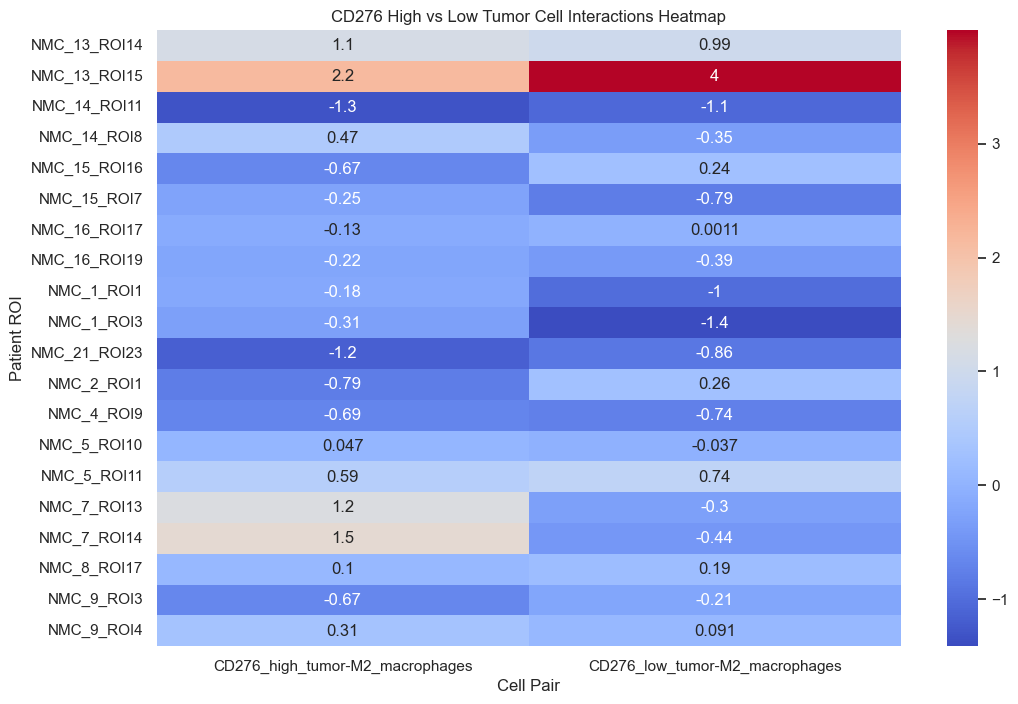

In [214]:
#turn it into a heatmap
cd276_heatmap = df.pivot(index='patient_exp', columns='cell_pair', values='zscore_scaled')
plt.figure(figsize=(12,8))
sns.heatmap(cd276_heatmap, cmap='coolwarm', annot=True)
plt.title('CD276 High vs Low Tumor Cell Interactions Heatmap')
plt.xlabel('Cell Pair')
plt.ylabel('Patient ROI')

In [216]:
adata_combined = sm.tl.spatial_distance (adata_combined, phenotype='cell_category', x_coordinate="Cell Center X", y_coordinate="Cell Center Y", imageid='patient_exp')

Processing Image: NMC_1_ROI3
Processing Image: NMC_5_ROI10
Processing Image: NMC_8_ROI17
Processing Image: NMC_5_ROI11
Processing Image: NMC_1_ROI1
Processing Image: NMC_4_ROI9
Processing Image: NMC_7_ROI14
Processing Image: NMC_7_ROI13
Processing Image: NMC_14_ROI11
Processing Image: NMC_15_ROI16
Processing Image: NMC_15_ROI7
Processing Image: NMC_16_ROI19
Processing Image: NMC_2_ROI1
Processing Image: NMC_14_ROI8
Processing Image: NMC_16_ROI17
Processing Image: NMC_13_ROI15
Processing Image: NMC_9_ROI4
Processing Image: NMC_21_ROI23
Processing Image: NMC_9_ROI3
Processing Image: NMC_13_ROI14


In [231]:
adata_combined.obs["cell_category"] = adata_combined.obs["cell_category"].cat.remove_categories("Tumor_cells")

In [263]:
distances = adata_combined.uns['spatial_distance']
distances["cell_category"] = adata_combined.obs['cell_category'].values
distances["patient_exp"] = adata_combined.obs['patient_exp'].values
distances = distances.loc[:, ["cell_category", "patient_exp", "M2_macrophages"]]
distances["M2_macrophages"] = distances["M2_macrophages"] * 0.17 # convert pixels to microns
# Order by median distance
order = (
    distances.groupby("cell_category")["M2_macrophages"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
) 
distances

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_50554/2017951936.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,cell_category,patient_exp,M2_macrophages
59615,CD276_high_tumor,NMC_1_ROI3,96.204657
59616,Actin+_cells,NMC_1_ROI3,94.286663
59617,NK_cells,NMC_1_ROI3,98.336771
59618,CD276_high_tumor,NMC_1_ROI3,100.491030
59619,NFC,NMC_1_ROI3,106.374772
...,...,...,...
506259,M2_macrophages,NMC_13_ROI14,44.739264
506260,Endothelial_cells,NMC_13_ROI14,8.069243
506261,Actin+_cells,NMC_13_ROI14,136.180249
506262,M2_macrophages,NMC_13_ROI14,61.521459


In [264]:
distances["cell_category"] = distances["cell_category"].astype(str)
distances = distances[distances["cell_category"].isin(["CD276_high_tumor", "CD276_low_tumor"])]
distances = distances.dropna(subset=["M2_macrophages"])
distances = distances.groupby(["cell_category", "patient_exp"])["M2_macrophages"].median().reset_index()


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_50554/431870151.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [267]:
from sklearn.preprocessing import MinMaxScaler

Text(67.10937499999999, 0.5, 'Patient ROI')

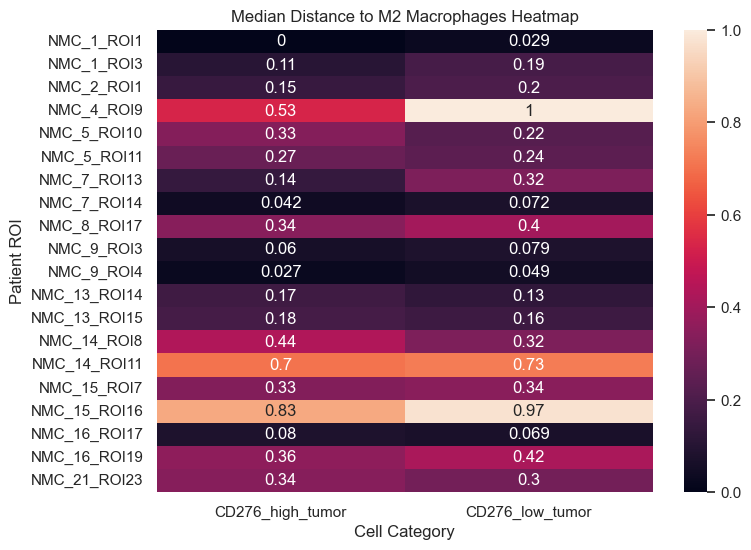

In [270]:
#scale distances M2_macrophages between 0 and 1
scaler = MinMaxScaler()
distances["M2_macrophages_scaled"] = scaler.fit_transform(distances[["M2_macrophages"]])
#heatmap
distance_heatmap = distances.pivot(index='patient_exp', columns='cell_category', values='M2_macrophages_scaled')
plt.figure(figsize=(8,6))
sns.heatmap(distance_heatmap, annot=True)
plt.title('Median Distance to M2 Macrophages Heatmap')
plt.xlabel('Cell Category')
plt.ylabel('Patient ROI')

In [ ]:
#heatmap from distances
distance_heatmap = distances.pivot(index='patient_exp', columns='cell_category', values='M2_macrophages')


In [ ]:
# --- Data prep ---
distances = adata_combined.uns['spatial_distance']
distances["cell_category"] = adata_combined.obs['cell_category'].values
distances = distances.loc[:, ["cell_category", "CD276_high_tumor"]]
distances["CD276_high_tumor"] = distances["CD276_high_tumor"] * 0.17 # convert pixels to microns
# Order by median distance
order = (
    distances.groupby("cell_category")["CD276_high_tumor"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# Counts for each cell type
counts = distances["cell_category"].value_counts().reindex(order)

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_50554/3816401339.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [235]:
distances

,cell_category,CD276_high_tumor
59615,CD276_high_tumor,27.912524
59616,Actin+_cells,13.524640
59617,NK_cells,8.908780
59618,CD276_high_tumor,6.950499
59619,NFC,7.417867
...,...,...
506259,M2_macrophages,281.635213
506260,Endothelial_cells,112.307903
506261,Actin+_cells,108.428920
506262,M2_macrophages,115.632161


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_50554/2875681549.py:5: FutureWarning:



The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.



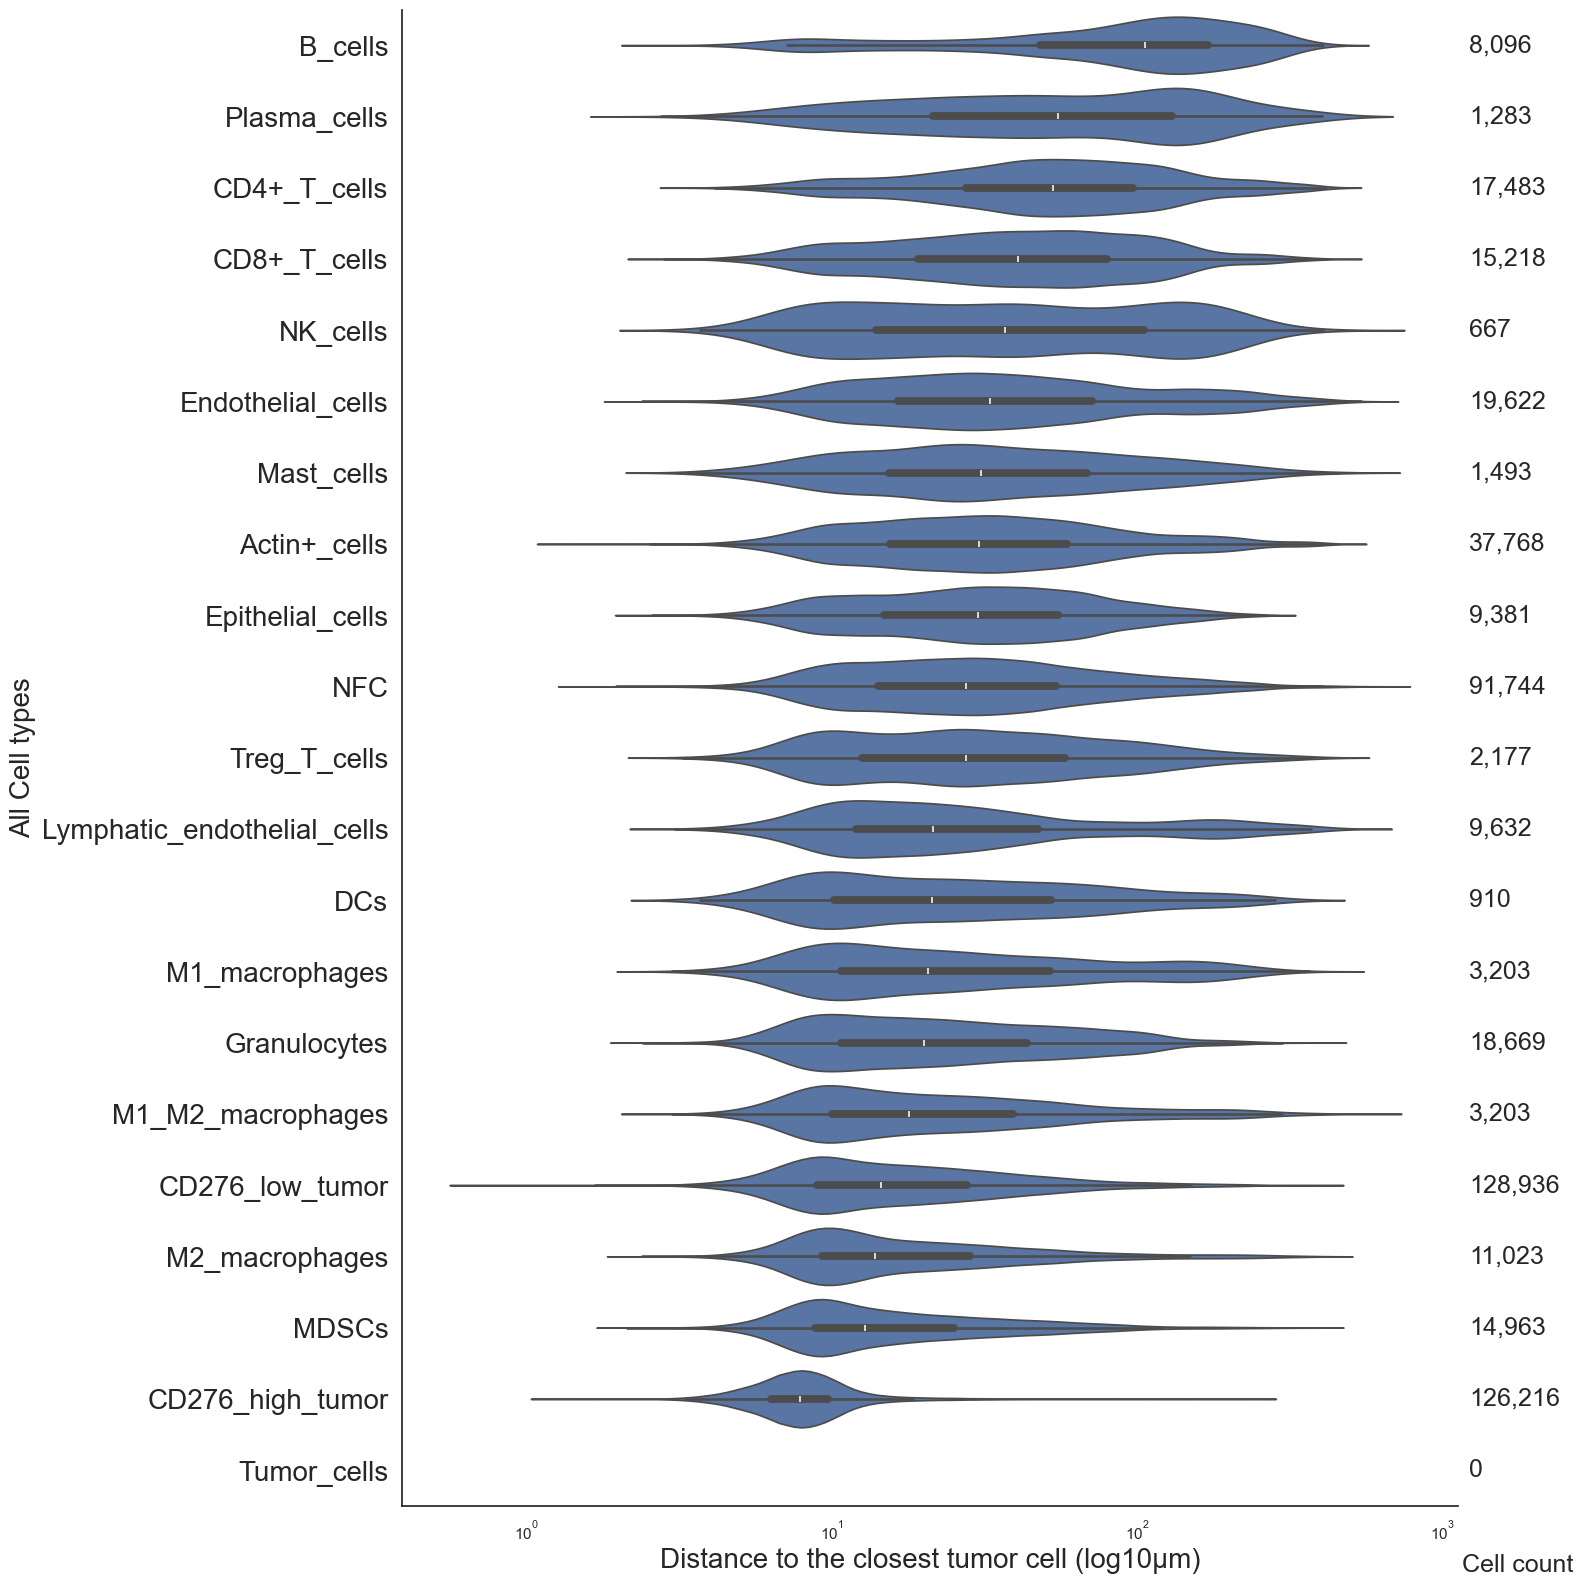

In [184]:
# --- Plot ---
fig, ax_violin = plt.subplots(figsize=(16, 16))

# Distance violinplot
sns.violinplot(
    data=distances,
    x="CD276_high_tumor",
    y="cell_category",
    order=order,
    scale="width",
    ax=ax_violin,
    log_scale=True
)
#increase size of y-axis labels 
ax_violin.tick_params(axis='y', labelsize=20)
# Axis labels
ax_violin.set_xlabel(
    "Distance to the closest tumor cell (log10µm)",
    fontsize=20
)
ax_violin.set_ylabel(
    "All Cell types",
    fontsize=20
)

# Add counts on the right side
for i, cell_category in enumerate(order):
    count_val = counts[cell_category]
    ax_violin.text(
        x=ax_violin.get_xlim()[1] * 1.09,
        y=i,
        s=f"{count_val:,}",
        va="center",
        ha="left",
        fontfamily="Arial",
        fontsize = 18
    )

# Add label for counts (once)
ax_violin.text(
    x=ax_violin.get_xlim()[1] * 1.03,
    y=len(order) + 0.5,
    s="Cell count",
    va="bottom", ha="left",
    fontfamily="Arial", 
    fontsize = 18
)

# Remove right/top spines
sns.despine(ax=ax_violin, right=True, top=True)

#save svg figure

plt.tight_layout()
plt.show()



In [ ]:
#View some images,,, see we if we can get anything

In [27]:
adata = sc.read_h5ad(results_dir / "adata.h5ad")
adata_141 = adata[adata.obs["run"] == 141].copy()
valid_genes = ~np.isnan(adata_141.X).all(axis=0)
adata_141 = adata_141[:, valid_genes].copy()
adata_141.raw = adata_141.copy()
adata_141_cd14 = adata_141[:, ['CD14']].copy()
adata_141_cd15 = adata_141[:, ['CD15']].copy()
adata_141_cd14.raw = adata_141_cd14.copy()
adata_141_cd15.raw = adata_141_cd15.copy()

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning:

Transforming to str index.



In [45]:
folder = "/Volumes/T7/Run141/ROI11/"
#look inside the folder for file with word ErbB2
files = os.listdir(folder)
cd15 = [f for f in files if "CD15" in f][0]
dapi = [f for f in files if "DAPI" in f]
dapi_cd15 = [d for d in dapi if cd15[0:5] in d][0]
cd14 = [f for f in files if "CD14" in f][0]
dapi_cd14 = [d for d in dapi if cd14[0:5] in d][0]

In [46]:
dapi_cd14_img = tifffile.imread(os.path.join(folder, dapi_cd14))
cd14_img = tifffile.imread(os.path.join(folder, cd14))
dapi_cd15_img = tifffile.imread(os.path.join(folder, dapi_cd15))
cd15_img = tifffile.imread(os.path.join(folder, cd15))
stacked_image_cd14 = np.stack([dapi_cd14_img, cd14_img], axis=0)
stacked_image_cd15 = np.stack([dapi_cd15_img, cd15_img], axis=0)

In [42]:
print(dapi_cd14_img.shape, cd14_img.shape, dapi_cd15_img.shape, cd15_img.shape)

(10070, 9368) (10070, 9368) (10070, 9375) (10070, 9375)


In [43]:
#write stacked_image to tiff
tifffile.imwrite("/Users/jawadalaaedeen/Desktop/cd14_dapi_stack.tif", stacked_image_cd14)
tifffile.imwrite("/Users/jawadalaaedeen/Desktop/cd15_dapi_stack.tif", stacked_image_cd15)

In [44]:
sm.pl.napariGater(
image_path = "/Users/jawadalaaedeen/Desktop/cd15_dapi_stack.tif",
adata = adata_141_cd15,
log = True,
x_coordinate = "Cell Center X",
y_coordinate = "Cell Center Y",
imageid = "exp_name",
channel_names=["DAPI", "CD15"],
subset = "Run141_ROI23"
)

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_34877/217295347.py:1: UserWarning:

NOTE: napariGater() is currently in beta testing. If you encounter any issues, please report them at: https://github.com/labsyspharm/scimap/issues



Initializing...
Loading image data...
Calculating contrast settings...


Saved contrast settings for Run141_ROI23 with 2 channels
Initialization completed in 0.07 seconds
Opening napari viewer...
Napari viewer initialized in 1.00 seconds


In [301]:
sm.pl.napariGater(
image_path = "/Users/jawadalaaedeen/Desktop/cd15_dapi_stack.tif",
adata = adata_141_cd15,
log = True,
x_coordinate = "Cell Center X",
y_coordinate = "Cell Center Y",
imageid = "exp_name",
channel_names=["DAPI", "CD15"],
subset = "Run141_ROI23"
)

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_88210/217295347.py:1: UserWarning:

NOTE: napariGater() is currently in beta testing. If you encounter any issues, please report them at: https://github.com/labsyspharm/scimap/issues



Initializing...
Loading image data...
Calculating contrast settings...


Saved contrast settings for Run141_ROI23 with 2 channels
Initialization completed in 0.07 seconds
Opening napari viewer...
Napari viewer initialized in 0.86 seconds


Gate confirmed for CD15 at 7.01
Gate confirmed for CD14 at 5.90


In [304]:
gates_cd14 = adata_141_cd14.uns["gates"]
gates_cd14
gates_cd14.to_csv("/Users/jawadalaaedeen/Desktop/Run141_cd14_gates.csv")

In [305]:
gates_cd15 = adata_141_cd15.uns["gates"]
gates_cd15.to_csv("/Users/jawadalaaedeen/Desktop/Run141_cd15_gates.csv")

In [310]:
adata = sc.read_h5ad(results_dir / "adata.h5ad")
adata_145 = adata[adata.obs["run"] == 145].copy()
valid_genes = ~np.isnan(adata_145.X).all(axis=0)
adata_145 = adata_145[:, valid_genes].copy()
adata_145.raw = adata_145.copy()
adata_145_cd15 = adata_145[:, ['CD15']].copy()
adata_145_cd15.raw = adata_145_cd15.copy()

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning:

Transforming to str index.



In [346]:
folder = "/Volumes/T7/Run145/ROI13/"
#look inside the folder for file with word ErbB2
files = os.listdir(folder)
cd15 = [f for f in files if "CD15" in f][0]
dapi = [f for f in files if "DAPI" in f]
dapi_cd15 = [d for d in dapi if cd15[0:5] in d][0]

In [347]:
dapi_cd15_img = tifffile.imread(os.path.join(folder, dapi_cd15))
cd15_img = tifffile.imread(os.path.join(folder, cd15))
stacked_image_cd15 = np.stack([dapi_cd15_img, cd15_img], axis=0)

In [348]:
#write stacked_image to tiff
tifffile.imwrite("/Users/jawadalaaedeen/Desktop/cd15_dapi_stack.tif", stacked_image_cd15)

In [349]:
sm.pl.napariGater(
image_path = "/Users/jawadalaaedeen/Desktop/cd15_dapi_stack.tif",
adata = adata_145_cd15,
log = True,
x_coordinate = "Cell Center X",
y_coordinate = "Cell Center Y",
imageid = "exp_name",
channel_names=["DAPI", "CD15"],
subset = "Run145_ROI13"
)

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_88210/1361044829.py:1: UserWarning:

NOTE: napariGater() is currently in beta testing. If you encounter any issues, please report them at: https://github.com/labsyspharm/scimap/issues



Initializing...
Loading image data...
Calculating contrast settings...
Initialization completed in 0.00 seconds
Opening napari viewer...
Napari viewer initialized in 1.67 seconds


In [350]:
gates_cd15 = adata_145_cd15.uns["gates"]
gates_cd15.to_csv("/Users/jawadalaaedeen/Desktop/Run145_cd15_gates.csv")

In [360]:
#run103
adata = sc.read_h5ad(results_dir / "adata.h5ad")
adata_103 = adata[adata.obs["run"] == 103].copy()
valid_genes = ~np.isnan(adata_103.X).all(axis=0)
adata_103 = adata_103[:, valid_genes].copy()
adata_103.raw = adata_103.copy()
adata_103_cd14 = adata_103[:, ['CD14']].copy()
adata_103_cd15 = adata_103[:, ['CD15']].copy()
adata_103_cd14.raw = adata_103_cd14.copy()
adata_103_cd15.raw = adata_103_cd15.copy()

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning:

Transforming to str index.



In [365]:
folder = "/Volumes/T7/Run103/R1-WB-1-ROI6/"
#look inside the folder for file with word ErbB2
files = os.listdir(folder)
cd15 = [f for f in files if "CD15" in f][0]
dapi = [f for f in files if "DAPI" in f]
dapi_cd15 = [d for d in dapi if cd15[0:5] in d][0]
cd14 = [f for f in files if "CD14" in f][0]
dapi_cd14 = [d for d in dapi if cd14[0:5] in d][0]

In [366]:
dapi_cd14_img = tifffile.imread(os.path.join(folder, dapi_cd14))
cd14_img = tifffile.imread(os.path.join(folder, cd14))
dapi_cd15_img = tifffile.imread(os.path.join(folder, dapi_cd15))
cd15_img = tifffile.imread(os.path.join(folder, cd15))
stacked_image_cd14 = np.stack([dapi_cd14_img, cd14_img], axis=0)
stacked_image_cd15 = np.stack([dapi_cd15_img, cd15_img], axis=0)

In [367]:
#write stacked_image to tiff
tifffile.imwrite("/Users/jawadalaaedeen/Desktop/cd14_dapi_stack.tif", stacked_image_cd14)
tifffile.imwrite("/Users/jawadalaaedeen/Desktop/cd15_dapi_stack.tif", stacked_image_cd15)

In [368]:
sm.pl.napariGater(
image_path = "/Users/jawadalaaedeen/Desktop/cd14_dapi_stack.tif",
adata = adata_103_cd14,
log = True,
x_coordinate = "Cell Center X",
y_coordinate = "Cell Center Y",
imageid = "exp_name",
channel_names=["DAPI", "CD14"],
subset = "Run103_ROI6"
)

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_88210/3615296832.py:1: UserWarning:

NOTE: napariGater() is currently in beta testing. If you encounter any issues, please report them at: https://github.com/labsyspharm/scimap/issues



Initializing...
Loading image data...
Calculating contrast settings...


Saved contrast settings for Run103_ROI6 with 2 channels
Initialization completed in 0.03 seconds
Opening napari viewer...
Napari viewer initialized in 1.64 seconds


In [369]:
sm.pl.napariGater(
image_path = "/Users/jawadalaaedeen/Desktop/cd15_dapi_stack.tif",
adata = adata_103_cd15,
log = True,
x_coordinate = "Cell Center X",
y_coordinate = "Cell Center Y",
imageid = "exp_name",
channel_names=["DAPI", "CD15"],
subset = "Run103_ROI6"
)

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_88210/3244904406.py:1: UserWarning:

NOTE: napariGater() is currently in beta testing. If you encounter any issues, please report them at: https://github.com/labsyspharm/scimap/issues



Initializing...
Loading image data...
Calculating contrast settings...


Saved contrast settings for Run103_ROI6 with 2 channels
Initialization completed in 0.04 seconds
Opening napari viewer...
Napari viewer initialized in 1.68 seconds


Gate confirmed for CD15 at 6.20
Gate confirmed for CD14 at 7.25


In [373]:
gates_cd14 = adata_103_cd14.uns["gates"]
gates_cd14
gates_cd14.to_csv("/Users/jawadalaaedeen/Desktop/Run103_cd14_gates.csv")

In [372]:
gates_cd15 = adata_103_cd15.uns["gates"]
gates_cd15
gates_cd15.to_csv("/Users/jawadalaaedeen/Desktop/Run103_cd15_gates.csv")

In [7]:
#run92
adata = sc.read_h5ad(results_dir / "adata.h5ad")
adata_92 = adata[adata.obs["run"] == 92].copy()
valid_genes = ~np.isnan(adata_92.X).all(axis=0)
adata_92 = adata_92[:, valid_genes].copy()
adata_92.raw = adata_92.copy()
adata_92_cd15 = adata_92[:, ['CD15 1']].copy()
adata_92_cd15.raw = adata_92_cd15.copy()

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning:

Transforming to str index.



In [14]:
folder = "/Volumes/T7/Run92/R1-WA-1-ROI6/"
#look inside the folder for file with word ErbB2
files = os.listdir(folder)
cd15 = [f for f in files if "CD15" in f][0]
dapi = [f for f in files if "DAPI" in f]
dapi_cd15 = [d for d in dapi if cd15[0:5] in d][0]

In [15]:
dapi_cd15_img = tifffile.imread(os.path.join(folder, dapi_cd15))
cd15_img = tifffile.imread(os.path.join(folder, cd15))
stacked_image_cd15 = np.stack([dapi_cd15_img, cd15_img], axis=0)

In [16]:
#write stacked_image to tiff
tifffile.imwrite("/Users/jawadalaaedeen/Desktop/cd15_dapi_stack.tif", stacked_image_cd15)

In [17]:
sm.pl.napariGater(
image_path = "/Users/jawadalaaedeen/Desktop/cd15_dapi_stack.tif",
adata = adata_92_cd15,
log = True,
x_coordinate = "Cell Center X",
y_coordinate = "Cell Center Y",
imageid = "exp_name",
channel_names=["DAPI", "CD15 1"],
subset = "Run92_ROI6"
)

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_34877/3668685679.py:1: UserWarning:

NOTE: napariGater() is currently in beta testing. If you encounter any issues, please report them at: https://github.com/labsyspharm/scimap/issues



Initializing...
Loading image data...
Calculating contrast settings...
Initialization completed in 0.00 seconds
Opening napari viewer...
Napari viewer initialized in 0.90 seconds


Gate confirmed for CD15 1 at 7.80


In [23]:
gates_cd15 = adata_92_cd15.uns["gates"]
gates_cd15.to_csv("/Users/jawadalaaedeen/Desktop/Run192_cd15_gates.csv")

In [25]:
#Get all csv files on desktop
csv_files = [f for f in os.listdir("/Users/jawadalaaedeen/Desktop/") if f.endswith('.csv')]
csv_files

['gates_cd14_cd15.csv',
 'Run103_cd14_gates.csv',
 'Run192_cd15_gates.csv',
 'Run103_cd15_gates.csv',
 'Run141_cd15_gates.csv',
 'Run145_cd15_gates.csv',
 'Run141_cd14_gates.csv']

In [61]:
#Let's use the gates and see
final_gates = pd.read_csv(metadata_dir/"CD15_all_gates.csv")
final_gates


,marker,Run141_ROI11,Run141_ROI16,Run141_ROI7,Run141_ROI19,Run141_ROI1,Run141_ROI8,Run141_ROI17,Run141_ROI15,Run141_ROI4,...,Run145_ROI17,Run145_ROI11,Run145_ROI1,Run145_ROI9,Run145_ROI14,Run145_ROI13,Run92_ROI5,Run92_ROI6,Run103_ROI5,Run103_ROI6
0,CD15,7,7.7,8,6.2,7.014659,7.2,6.9,6,6.9,...,6.745697,6.55,6.9,6.745697,6.7,7.3,7.85,7.8,7.1,6.2


In [50]:
#run92
adata = sc.read_h5ad(results_dir / "adata.h5ad")
adata_92 = adata[adata.obs["run"] == 92].copy()
valid_genes = ~np.isnan(adata_92.X).all(axis=0)
adata_92 = adata_92[:, valid_genes].copy()
adata_92.raw = adata_92.copy()
#log1p transform
adata_92.X = np.log1p(adata_92.X)

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning:

Transforming to str index.



array([[7.53566115, 8.551066  , 4.45688174, ..., 7.94963806, 8.2230667 ,
        4.51003695],
       [7.53986743, 7.80160827, 4.4281444 , ..., 7.80772209, 6.94625282,
        3.93905974],
       [7.63628622, 7.84015713, 4.47020431, ..., 7.86498109, 7.28580704,
        3.69755307],
       ...,
       [7.4682123 , 6.69629666, 4.59811579, ..., 7.8499199 , 5.19962201,
        4.06175605],
       [7.58686079, 7.45994463, 4.82983224, ..., 7.95389708, 5.91414738,
        3.96774665],
       [7.54405079, 9.53182849, 4.72897422, ..., 7.94826498, 4.45535121,
        3.88604055]])

In [78]:
adata_all = []
for run in adata.obs.run.unique():
    adata_run = adata[adata.obs["run"] == run].copy()
    valid_genes = ~np.isnan(adata_run.X).all(axis=0)
    adata_run = adata_run[:, valid_genes].copy()
    adata_run.raw = adata_run.copy()
    #log1p transform
    adata_run.X = np.log1p(adata_run.X)
    #extract only the final gates that include the Run in their column name
    gates_run = final_gates[[col for col in final_gates.columns if str(run) in col or col == "marker"]].copy()
    #Use the gate to label cells as CD15 positive or negative. Take into account the columns for different samples in the urn
    adata_run.obs["CD15_status"] = "CD15_negative"
    cd15_idx = adata_run.var_names.get_loc("CD15" if "CD15" in adata_run.var_names else "CD15 1")
    for sample in adata_run.obs["exp_name"].unique():
        sample_mask = adata_run.obs["exp_name"] == sample
        #get the gate from gates_run
        threshold = gates_run[sample].values[0]
        mask_positive = (adata_run.X[:, cd15_idx] >= threshold)
        adata_run.obs.loc[sample_mask & mask_positive, "CD15_status"] = "CD15_positive"
    adata_all.append(adata_run)
adata_combined = ad.concat(adata_all)


In [80]:
adata

AnnData object with n_obs × n_vars = 587448 × 144
    obs: 'cell_id', 'cell_type', 'level', 'parent_cell', 'type_no', 'Cell 3D Volume', 'Cell Bbox Bottom', 'Cell Bbox Left', 'Cell Bbox Right', 'Cell Bbox Top', 'Cell Bbox X Size', 'Cell Bbox Y Size', 'Cell Center X', 'Cell Center Y', 'Cell Center Y Inverted', 'Cell Contour Bending Energy', 'Cell Contour Length', 'Cell Convex Hull Area', 'Cell Convex Hull Perimeter', 'Cell Convexity', 'Cell Cytoplasm Area', 'Cell Feret Diameter Max', 'Cell Feret Diameter Maximum Angle', 'Cell Feret Diameter Min', 'Cell Feret Diameter Minimum Angle', 'Cell Feret Diameter Perpendicular Min', 'Cell P2A', 'Cell Radius Maximum', 'Cell Radius Mean', 'Cell Radius Minimum', 'Cell Radius Standard Deviation', 'Cell Roundness', 'Cell Shape Circle Like', 'Cell Shape Ellipse Like', 'Cell Shape Elongation', 'Cell Shape Square Like', 'Cell Shape Triangle Like', 'Cell Size', 'Nuc X', 'Nuc Y', 'Nuc Y Inv', 'Nucleus 3D Volume', 'Nucleus Box Bottom', 'Nucleus Box Height', 

In [79]:
adata_combined

AnnData object with n_obs × n_vars = 587448 × 0
    obs: 'cell_id', 'cell_type', 'level', 'parent_cell', 'type_no', 'Cell 3D Volume', 'Cell Bbox Bottom', 'Cell Bbox Left', 'Cell Bbox Right', 'Cell Bbox Top', 'Cell Bbox X Size', 'Cell Bbox Y Size', 'Cell Center X', 'Cell Center Y', 'Cell Center Y Inverted', 'Cell Contour Bending Energy', 'Cell Contour Length', 'Cell Convex Hull Area', 'Cell Convex Hull Perimeter', 'Cell Convexity', 'Cell Cytoplasm Area', 'Cell Feret Diameter Max', 'Cell Feret Diameter Maximum Angle', 'Cell Feret Diameter Min', 'Cell Feret Diameter Minimum Angle', 'Cell Feret Diameter Perpendicular Min', 'Cell P2A', 'Cell Radius Maximum', 'Cell Radius Mean', 'Cell Radius Minimum', 'Cell Radius Standard Deviation', 'Cell Roundness', 'Cell Shape Circle Like', 'Cell Shape Ellipse Like', 'Cell Shape Elongation', 'Cell Shape Square Like', 'Cell Shape Triangle Like', 'Cell Size', 'Nuc X', 'Nuc Y', 'Nuc Y Inv', 'Nucleus 3D Volume', 'Nucleus Box Bottom', 'Nucleus Box Height', 'N

In [99]:
#make a barplot of only MDSCs cell type percentage between CD15 positive and negative cells per patient_exp
mdsc_counts = (
    adata_combined.obs.groupby(["patient_exp", "CD15_status", "cell_type"])
    .size()
    .reset_index(name="counts")
)
mdsc_counts = mdsc_counts[mdsc_counts["cell_type"] == "MDSCs"]
#turn these numbers into percentages of MDSCs that are positive and negative for CD15 per patient_exp for MDSCs
mdsc_counts

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_34877/3868192957.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,patient_exp,CD15_status,cell_type,counts
12,NMC_1_ROI1,CD15_negative,MDSCs,44
31,NMC_1_ROI1,CD15_positive,MDSCs,0
50,NMC_1_ROI3,CD15_negative,MDSCs,234
69,NMC_1_ROI3,CD15_positive,MDSCs,0
88,NMC_2_ROI1,CD15_negative,MDSCs,4
107,NMC_2_ROI1,CD15_positive,MDSCs,184
126,NMC_4_ROI9,CD15_negative,MDSCs,165
145,NMC_4_ROI9,CD15_positive,MDSCs,514
164,NMC_5_ROI10,CD15_negative,MDSCs,854
183,NMC_5_ROI10,CD15_positive,MDSCs,267


In [ ]:
#Percentage of Granulocyte infiltration...

In [102]:
folder = "/Volumes/T7/Run141/ROI3/"
#look inside the folder for file with word ErbB2
files = os.listdir(folder)
arg = [f for f in files if "Argin" in f][0]
dapi = [f for f in files if "DAPI" in f]
dapi_arg = [d for d in dapi if cd15[0:5] in d][0]
arg

'C-048_S-000_S_APC_R-01_W-A-1_ROI-03_A-Arginase-1_C-2.tif'

In [91]:
dapi_arg_img = tifffile.imread(os.path.join(folder, dapi_arg))
arg_img = tifffile.imread(os.path.join(folder, arg))

In [92]:
viewer = napari.Viewer()
viewer.add_image(dapi_arg_img, name='DAPI', colormap="blue", blending='additive')
viewer.add_image(arg_img, name='Arginase-1', colormap="green", blending='additive')

<Image layer 'Arginase-1' at 0x410ea4be0>

In [100]:
adata_103

NameError: name 'adata_103' is not defined